In [2]:
%pip install -q wfdb medmnist

import os
import shutil
import tarfile
import warnings

warnings.filterwarnings("ignore", category=DeprecationWarning)

WORKING_DIR = "/kaggle/working/data"
os.makedirs(f"{WORKING_DIR}/pneumonia", exist_ok=True)
os.makedirs(f"{WORKING_DIR}/chestmnist", exist_ok=True)
os.makedirs(f"{WORKING_DIR}/mit_bih", exist_ok=True)

status = {"pneumonia": False, "chestmnist": False, "mit_bih": False}

for root, dirs, files in os.walk("/kaggle/input"):
    if "pneumoniamnist.npz" in files and not status["pneumonia"]:
        src = os.path.join(root, "pneumoniamnist.npz")
        shutil.copy(src, f"{WORKING_DIR}/pneumonia/pneumoniamnist.npz")
        status["pneumonia"] = True
        print(f"Copied PneumoniaMNIST from: {root}")

    if "chestmnist.npz" in files and not status["chestmnist"]:
        src = os.path.join(root, "chestmnist.npz")
        shutil.copy(src, f"{WORKING_DIR}/pneumonia/chestmnist.npz")
        status["chestmnist"] = True
        print(f"Copied chestmnist from: {root}")

    if "100.dat" in files and not status["mit_bih"]:
        for item in os.listdir(root):
            s = os.path.join(root, item)
            d = os.path.join(f"{WORKING_DIR}/mit_bih", item)
            if os.path.isdir(s):
                shutil.copytree(s, d, dirs_exist_ok=True)
            else:
                shutil.copy2(s, d)
        status["mit_bih"] = True
        print(f"Copied MIT-BIH from: {root}")

print("\nSetup Summary")
for dataset, success in status.items():
    print(f"{dataset.upper():<12} : {'SUCCESS' if success else 'FAILED (Not Found)'}")

print("\nContents of WORKING_DIR")
for item in sorted(os.listdir(WORKING_DIR)):
    print(f"- {item}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.9/163.9 kB 4.3 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.9/115.9 kB 8.3 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.
Copied PneumoniaMNIST from: /kaggle/input/datasets/sajeebhasan/fml-da
Copied chestmnist from: /kaggle/input/datasets/sajeebhasan/fml-da
Copied MIT-BIH from: /kaggle/input/datasets/sajeebhasan/fml-da/mit-bih-arrhythmia-database-1.0.0/mit-bih-arrhythmia-database-1.0.0

Setup Summary
PNEUMONIA    : SUCCESS
CHESTMNIST   : SUCCESS
MIT_BIH      : SUCCESS

Contents of WORKING_DIR
- chestmnist
- mit_bih
- pneumonia


In [3]:
# Cell 2: Set global configuration and discover multimodal dataset files

import random
from pathlib import Path

import numpy as np
import torch

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

NUM_CLIENTS = 5
ALPHA = 0.5
IMAGE_EMBED_DIM = 128
ECG_EMBED_DIM = 128
METADATA_EMBED_DIM = 32
FUSION_DIM = 128
SHARED_LATENT_DIM = 64
USE_METADATA = False

WORKING_DIR = Path("/kaggle/working/data")

def resolve_existing_path(*candidates):
    for candidate in candidates:
        path = Path(candidate)
        if path.exists():
            return path
    raise FileNotFoundError(f"None of the candidate paths exist: {candidates}")

PNEUMONIA_FILE = resolve_existing_path(
    WORKING_DIR / "pneumonia" / "pneumoniamnist.npz"
)

CHESTMNIST_FILE = resolve_existing_path(
    WORKING_DIR / "chestmnist" / "chestmnist.npz",
    WORKING_DIR / "pneumonia" / "chestmnist.npz",
)

MITBIH_DIR = resolve_existing_path(WORKING_DIR / "mit_bih")

pneumonia_data = np.load(PNEUMONIA_FILE)
chestmnist_data = np.load(CHESTMNIST_FILE)
mitbih_records = sorted(path.stem for path in MITBIH_DIR.glob("*.dat"))

print("Device:", device)
print("Global config:")
print(f"  NUM_CLIENTS={NUM_CLIENTS}, ALPHA={ALPHA}, SHARED_LATENT_DIM={SHARED_LATENT_DIM}")
print(f"  IMAGE_EMBED_DIM={IMAGE_EMBED_DIM}, ECG_EMBED_DIM={ECG_EMBED_DIM}, METADATA_EMBED_DIM={METADATA_EMBED_DIM}")
print(f"  USE_METADATA={USE_METADATA}")

print("Dataset inventory:")
print(f"  PneumoniaMNIST train: {pneumonia_data['train_images'].shape}, labels: {pneumonia_data['train_labels'].shape}")
print(f"  PneumoniaMNIST val  : {pneumonia_data['val_images'].shape}, labels: {pneumonia_data['val_labels'].shape}")
print(f"  PneumoniaMNIST test : {pneumonia_data['test_images'].shape}, labels: {pneumonia_data['test_labels'].shape}")
print(f"  ChestMNIST train    : {chestmnist_data['train_images'].shape}, labels: {chestmnist_data['train_labels'].shape}")
print(f"  ChestMNIST val      : {chestmnist_data['val_images'].shape}, labels: {chestmnist_data['val_labels'].shape}")
print(f"  ChestMNIST test     : {chestmnist_data['test_images'].shape}, labels: {chestmnist_data['test_labels'].shape}")
print(f"  MIT-BIH records     : {len(mitbih_records)}")
print(f"  First records       : {mitbih_records[:5]}")

Device: cuda
Global config:
  NUM_CLIENTS=5, ALPHA=0.5, SHARED_LATENT_DIM=64
  IMAGE_EMBED_DIM=128, ECG_EMBED_DIM=128, METADATA_EMBED_DIM=32
  USE_METADATA=False
Dataset inventory:
  PneumoniaMNIST train: (4708, 28, 28), labels: (4708, 1)
  PneumoniaMNIST val  : (524, 28, 28), labels: (524, 1)
  PneumoniaMNIST test : (624, 28, 28), labels: (624, 1)
  ChestMNIST train    : (78468, 28, 28), labels: (78468, 14)
  ChestMNIST val      : (11219, 28, 28), labels: (11219, 14)
  ChestMNIST test     : (22433, 28, 28), labels: (22433, 14)
  MIT-BIH records     : 48
  First records       : ['100', '101', '102', '103', '104']


In [4]:
# Cell 3: Prepare shared binary targets for the image and ECG modalities

import wfdb

# Image modality: use PneumoniaMNIST as the primary chest X-ray branch
X_image_train = pneumonia_data["train_images"].astype(np.float32)
y_image_train = pneumonia_data["train_labels"].squeeze().astype(np.int64)

X_image_val = pneumonia_data["val_images"].astype(np.float32)
y_image_val = pneumonia_data["val_labels"].squeeze().astype(np.int64)

X_image_test = pneumonia_data["test_images"].astype(np.float32)
y_image_test = pneumonia_data["test_labels"].squeeze().astype(np.int64)

# Shared binary label meaning across modalities
LABEL_NAMES = {
    0: "negative_or_normal",
    1: "positive_or_abnormal",
}

# ECG modality: define a standard binary mapping for MIT-BIH beat symbols
# 0 = normal beat, 1 = abnormal beat
MITBIH_NORMAL_SYMBOLS = {"N", "L", "R", "e", "j"}
MITBIH_ABNORMAL_SYMBOLS = {"A", "a", "J", "S", "V", "E", "F", "/", "f", "Q"}

def map_mitbih_symbol_to_binary(symbol):
    if symbol in MITBIH_NORMAL_SYMBOLS:
        return 0
    if symbol in MITBIH_ABNORMAL_SYMBOLS:
        return 1
    return None

image_summary = {
    "train_total": len(y_image_train),
    "train_negative": int(np.sum(y_image_train == 0)),
    "train_positive": int(np.sum(y_image_train == 1)),
    "val_total": len(y_image_val),
    "val_negative": int(np.sum(y_image_val == 0)),
    "val_positive": int(np.sum(y_image_val == 1)),
    "test_total": len(y_image_test),
    "test_negative": int(np.sum(y_image_test == 0)),
    "test_positive": int(np.sum(y_image_test == 1)),
}

print("Shared label space:")
for label_id, label_name in LABEL_NAMES.items():
    print(f"  {label_id} -> {label_name}")

print("\nImage modality summary:")
print(
    f"  Train: total={image_summary['train_total']}, "
    f"negative={image_summary['train_negative']}, positive={image_summary['train_positive']}"
)
print(
    f"  Val  : total={image_summary['val_total']}, "
    f"negative={image_summary['val_negative']}, positive={image_summary['val_positive']}"
)
print(
    f"  Test : total={image_summary['test_total']}, "
    f"negative={image_summary['test_negative']}, positive={image_summary['test_positive']}"
)

sample_record = mitbih_records[0]
sample_ann = wfdb.rdann(str(MITBIH_DIR / sample_record), "atr")

mapped_sample_labels = [
    map_mitbih_symbol_to_binary(symbol)
    for symbol in sample_ann.symbol
]

valid_sample_labels = [label for label in mapped_sample_labels if label is not None]

print("\nECG modality check:")
print(f"  Sample record        : {sample_record}")
print(f"  Total beat symbols   : {len(sample_ann.symbol)}")
print(f"  Mapped beat labels   : {len(valid_sample_labels)}")
print(f"  Normal beats         : {sum(label == 0 for label in valid_sample_labels)}")
print(f"  Abnormal beats       : {sum(label == 1 for label in valid_sample_labels)}")
print(f"  First 20 raw symbols : {sample_ann.symbol[:20]}")

Shared label space:
  0 -> negative_or_normal
  1 -> positive_or_abnormal

Image modality summary:
  Train: total=4708, negative=1214, positive=3494
  Val  : total=524, negative=135, positive=389
  Test : total=624, negative=234, positive=390

ECG modality check:
  Sample record        : 100
  Total beat symbols   : 2274
  Mapped beat labels   : 2273
  Normal beats         : 2239
  Abnormal beats       : 34
  First 20 raw symbols : ['+', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'A', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N']


In [5]:
# Cell 4: Build the ECG dataset from MIT-BIH with a record-level split

ECG_BEAT_LENGTH = 256
ECG_PRE_R = 96
ECG_POST_R = ECG_BEAT_LENGTH - ECG_PRE_R

rng = np.random.default_rng(SEED)
ecg_record_ids = sorted(mitbih_records)
shuffled_ecg_records = ecg_record_ids.copy()
rng.shuffle(shuffled_ecg_records)

n_ecg_records = len(shuffled_ecg_records)
n_train_records = int(0.70 * n_ecg_records)
n_val_records = int(0.15 * n_ecg_records)

ecg_train_records = sorted(shuffled_ecg_records[:n_train_records])
ecg_val_records = sorted(shuffled_ecg_records[n_train_records:n_train_records + n_val_records])
ecg_test_records = sorted(shuffled_ecg_records[n_train_records + n_val_records:])

def choose_ecg_channel(sig_names):
    if "MLII" in sig_names:
        return sig_names.index("MLII")
    if "MLI" in sig_names:
        return sig_names.index("MLI")
    return 0

def extract_ecg_beats(record_ids, pre_r=ECG_PRE_R, post_r=ECG_POST_R):
    beats = []
    labels = []
    source_records = []

    for record_id in record_ids:
        signal, fields = wfdb.rdsamp(str(MITBIH_DIR / record_id))
        annotation = wfdb.rdann(str(MITBIH_DIR / record_id), "atr")

        sig_names = list(fields["sig_name"])
        channel_idx = choose_ecg_channel(sig_names)
        signal_1d = signal[:, channel_idx].astype(np.float32)

        for sample_idx, symbol in zip(annotation.sample, annotation.symbol):
            label = map_mitbih_symbol_to_binary(symbol)
            if label is None:
                continue

            left = int(sample_idx) - pre_r
            right = int(sample_idx) + post_r

            if left < 0 or right > len(signal_1d):
                continue

            beat = signal_1d[left:right].copy()
            beat = beat - beat.mean()

            beat_std = beat.std()
            if beat_std > 1e-6:
                beat = beat / beat_std

            beats.append(beat.astype(np.float32))
            labels.append(label)
            source_records.append(record_id)

    X = np.stack(beats).astype(np.float32)
    y = np.asarray(labels, dtype=np.int64)
    record_source = np.asarray(source_records)

    return X, y, record_source

X_ecg_train, y_ecg_train, ecg_train_source = extract_ecg_beats(ecg_train_records)
X_ecg_val, y_ecg_val, ecg_val_source = extract_ecg_beats(ecg_val_records)
X_ecg_test, y_ecg_test, ecg_test_source = extract_ecg_beats(ecg_test_records)

print("ECG record split:")
print(f"  Train records ({len(ecg_train_records)}): {ecg_train_records[:8]}{' ...' if len(ecg_train_records) > 8 else ''}")
print(f"  Val records   ({len(ecg_val_records)}): {ecg_val_records[:8]}{' ...' if len(ecg_val_records) > 8 else ''}")
print(f"  Test records  ({len(ecg_test_records)}): {ecg_test_records[:8]}{' ...' if len(ecg_test_records) > 8 else ''}")

print("\nECG beat dataset summary:")
print(
    f"  Train: X={X_ecg_train.shape}, normal={np.sum(y_ecg_train == 0)}, abnormal={np.sum(y_ecg_train == 1)}"
)
print(
    f"  Val  : X={X_ecg_val.shape}, normal={np.sum(y_ecg_val == 0)}, abnormal={np.sum(y_ecg_val == 1)}"
)
print(
    f"  Test : X={X_ecg_test.shape}, normal={np.sum(y_ecg_test == 0)}, abnormal={np.sum(y_ecg_test == 1)}"
)

print("\nECG sanity checks:")
print(f"  Beat length: {ECG_BEAT_LENGTH}")
print(f"  Unique train records used: {len(np.unique(ecg_train_source))}")
print(f"  Unique val records used  : {len(np.unique(ecg_val_source))}")
print(f"  Unique test records used : {len(np.unique(ecg_test_source))}")

ECG record split:
  Train records (33): ['103', '104', '105', '107', '109', '111', '116', '117'] ...
  Val records   (7): ['100', '106', '112', '113', '121', '124', '215']
  Test records  (8): ['101', '102', '108', '114', '115', '213', '217', '233']

ECG beat dataset summary:
  Train: X=(75800, 256), normal=63354, abnormal=12446
  Val  : X=(15472, 256), normal=14657, abnormal=815
  Test : X=(18177, 256), normal=12581, abnormal=5596

ECG sanity checks:
  Beat length: 256
  Unique train records used: 33
  Unique val records used  : 7
  Unique test records used : 8


In [6]:
# Cell 5: Create federated client splits for image and ECG training data

import matplotlib.pyplot as plt

def stable_dirichlet_split_indices(
    labels,
    num_clients,
    alpha,
    num_classes,
    min_total,
    min_per_class,
    max_class_fraction,
    max_retries=6000,
    seed=SEED,
):
    rng = np.random.default_rng(seed)
    labels = np.asarray(labels)

    for _ in range(max_retries):
        client_indices = {client_id: [] for client_id in range(num_clients)}

        for class_id in range(num_classes):
            class_indices = np.where(labels == class_id)[0]
            rng.shuffle(class_indices)

            proportions = rng.dirichlet(np.full(num_clients, alpha))
            cut_points = (np.cumsum(proportions) * len(class_indices)).astype(int)[:-1]
            splits = np.split(class_indices, cut_points)

            for client_id, split_indices in enumerate(splits):
                client_indices[client_id].extend(split_indices.tolist())

        is_valid = True
        for client_id in range(num_clients):
            indices = np.asarray(client_indices[client_id], dtype=np.int64)

            if len(indices) < min_total:
                is_valid = False
                break

            class_counts = np.bincount(labels[indices], minlength=num_classes)

            if (class_counts < min_per_class).any():
                is_valid = False
                break

            majority_fraction = class_counts.max() / max(len(indices), 1)
            if majority_fraction > max_class_fraction:
                is_valid = False
                break

        if is_valid:
            return {
                client_id: np.asarray(indices, dtype=np.int64)
                for client_id, indices in client_indices.items()
            }

    raise RuntimeError("Could not build a stable constrained Dirichlet split.")

def find_feasible_split(labels, split_name, schedules, seed_offset=0):
    for schedule_id, schedule in enumerate(schedules):
        try:
            split = stable_dirichlet_split_indices(
                labels=labels,
                num_clients=NUM_CLIENTS,
                alpha=ALPHA,
                num_classes=2,
                min_total=schedule["min_total"],
                min_per_class=schedule["min_per_class"],
                max_class_fraction=schedule["max_class_fraction"],
                max_retries=schedule.get("max_retries", 6000),
                seed=SEED + seed_offset + schedule_id,
            )
            print(
                f"{split_name}: using constraints "
                f"min_total={schedule['min_total']}, "
                f"min_per_class={schedule['min_per_class']}, "
                f"max_class_fraction={schedule['max_class_fraction']:.2f}"
            )
            return split, schedule
        except RuntimeError:
            continue

    raise RuntimeError(f"Could not find a feasible constrained split for {split_name}.")

def summarize_client_split(labels, client_splits, title):
    print(title)
    hist = np.zeros((NUM_CLIENTS, 2), dtype=np.int64)

    for client_id, indices in client_splits.items():
        class_counts = np.bincount(labels[indices], minlength=2)
        hist[client_id] = class_counts
        majority_fraction = class_counts.max() / len(indices)

        print(
            f"  Client {client_id}: total={len(indices):>6} | "
            f"negative={class_counts[0]:>6} | positive={class_counts[1]:>6} | "
            f"majority_frac={majority_fraction:.3f}"
        )

    print(f"  Total assigned: {hist.sum()} / {len(labels)}")
    return hist

image_split_schedules = [
    {"min_total": 128, "min_per_class": 48, "max_class_fraction": 0.88, "max_retries": 8000},
    {"min_total": 96, "min_per_class": 32, "max_class_fraction": 0.90, "max_retries": 7000},
    {"min_total": 64, "min_per_class": 24, "max_class_fraction": 0.92, "max_retries": 6000},
]

ecg_split_schedules = [
    {"min_total": 4000, "min_per_class": 600, "max_class_fraction": 0.88, "max_retries": 8000},
    {"min_total": 3000, "min_per_class": 400, "max_class_fraction": 0.90, "max_retries": 7000},
    {"min_total": 2000, "min_per_class": 256, "max_class_fraction": 0.92, "max_retries": 6000},
]

image_client_splits, image_split_config = find_feasible_split(
    labels=y_image_train,
    split_name="Image split",
    schedules=image_split_schedules,
    seed_offset=0,
)

ecg_client_splits, ecg_split_config = find_feasible_split(
    labels=y_ecg_train,
    split_name="ECG split",
    schedules=ecg_split_schedules,
    seed_offset=100,
)

print()
image_client_hist = summarize_client_split(
    y_image_train,
    image_client_splits,
    title="Image client split summary:",
)

print()
ecg_client_hist = summarize_client_split(
    y_ecg_train,
    ecg_client_splits,
    title="ECG client split summary:",
)

assert sum(len(indices) for indices in image_client_splits.values()) == len(y_image_train)
assert sum(len(indices) for indices in ecg_client_splits.values()) == len(y_ecg_train)

Image split: using constraints min_total=128, min_per_class=48, max_class_fraction=0.88
ECG split: using constraints min_total=4000, min_per_class=600, max_class_fraction=0.88

Image client split summary:
  Client 0: total=  1233 | negative=   183 | positive=  1050 | majority_frac=0.852
  Client 1: total=   208 | negative=    93 | positive=   115 | majority_frac=0.553
  Client 2: total=  2011 | negative=   708 | positive=  1303 | majority_frac=0.648
  Client 3: total=   267 | negative=    63 | positive=   204 | majority_frac=0.764
  Client 4: total=   989 | negative=   167 | positive=   822 | majority_frac=0.831
  Total assigned: 4708 / 4708

ECG client split summary:
  Client 0: total= 10478 | negative=  8549 | positive=  1929 | majority_frac=0.816
  Client 1: total= 10258 | negative=  8047 | positive=  2211 | majority_frac=0.784
  Client 2: total= 13151 | negative= 11126 | positive=  2025 | majority_frac=0.846
  Client 3: total= 32109 | negative= 28255 | positive=  3854 | majority_fr

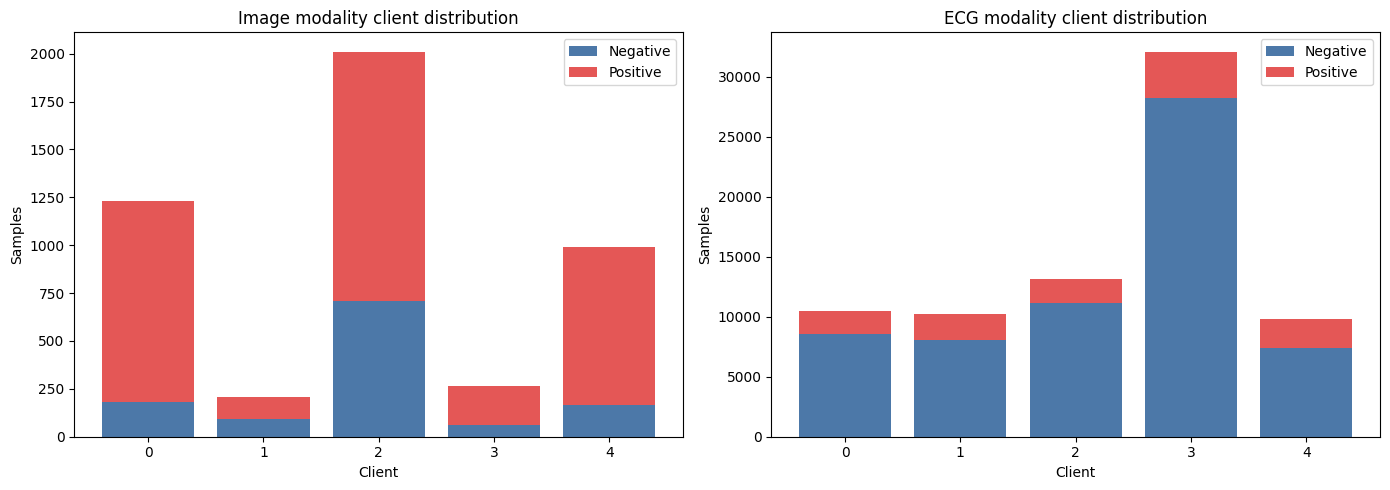

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

bottom = np.zeros(NUM_CLIENTS)
axes[0].bar(np.arange(NUM_CLIENTS), image_client_hist[:, 0], color="#4C78A8", label="Negative")
bottom += image_client_hist[:, 0]
axes[0].bar(np.arange(NUM_CLIENTS), image_client_hist[:, 1], bottom=bottom, color="#E45756", label="Positive")
axes[0].set_title("Image modality client distribution")
axes[0].set_xlabel("Client")
axes[0].set_ylabel("Samples")
axes[0].set_xticks(np.arange(NUM_CLIENTS))
axes[0].legend()

bottom = np.zeros(NUM_CLIENTS)
axes[1].bar(np.arange(NUM_CLIENTS), ecg_client_hist[:, 0], color="#4C78A8", label="Negative")
bottom += ecg_client_hist[:, 0]
axes[1].bar(np.arange(NUM_CLIENTS), ecg_client_hist[:, 1], bottom=bottom, color="#E45756", label="Positive")
axes[1].set_title("ECG modality client distribution")
axes[1].set_xlabel("Client")
axes[1].set_ylabel("Samples")
axes[1].set_xticks(np.arange(NUM_CLIENTS))
axes[1].legend()

plt.tight_layout()
plt.show()

In [8]:
# Cell 6: Prepare modality datasets and client dataloaders

import torch
from torch.utils.data import Dataset, DataLoader

LOCAL_BATCH_SIZE = 128
EVAL_BATCH_SIZE = 256
NUM_WORKERS = 0

image_train_float = X_image_train.astype(np.float32) / 255.0
image_mean = float(image_train_float.mean())
image_std = float(image_train_float.std() + 1e-6)

ecg_mean = float(X_ecg_train.mean())
ecg_std = float(X_ecg_train.std() + 1e-6)

print("Normalization summary")
print(f"  Image mean/std : {image_mean:.4f} / {image_std:.4f}")
print(f"  ECG mean/std   : {ecg_mean:.4f} / {ecg_std:.4f}")

class BinaryImageDataset(Dataset):
    def __init__(self, images, labels, mean, std):
        self.images = images.astype(np.float32)
        self.labels = labels.astype(np.int64)
        self.mean = mean
        self.std = std

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        image = self.images[idx] / 255.0
        image = (image - self.mean) / self.std
        image = torch.from_numpy(image).unsqueeze(0)
        label = torch.tensor(self.labels[idx], dtype=torch.long)
        return image, label

class BinaryECGDataset(Dataset):
    def __init__(self, beats, labels, mean, std):
        self.beats = beats.astype(np.float32)
        self.labels = labels.astype(np.int64)
        self.mean = mean
        self.std = std

    def __len__(self):
        return len(self.beats)

    def __getitem__(self, idx):
        beat = (self.beats[idx] - self.mean) / self.std
        beat = torch.from_numpy(beat).unsqueeze(0)
        label = torch.tensor(self.labels[idx], dtype=torch.long)
        return beat, label

def build_loader(dataset, batch_size, shuffle):
    return DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=shuffle,
        num_workers=NUM_WORKERS,
        pin_memory=torch.cuda.is_available(),
    )

def subset_dataset(dataset_cls, features, labels, indices, mean, std):
    indices = np.asarray(indices, dtype=np.int64)
    return dataset_cls(features[indices], labels[indices], mean, std)

image_client_datasets = {}
image_client_loaders = {}
for client_id, indices in image_client_splits.items():
    dataset = subset_dataset(
        BinaryImageDataset,
        X_image_train,
        y_image_train,
        indices,
        image_mean,
        image_std,
    )
    image_client_datasets[client_id] = dataset
    image_client_loaders[client_id] = build_loader(dataset, LOCAL_BATCH_SIZE, shuffle=True)

ecg_client_datasets = {}
ecg_client_loaders = {}
for client_id, indices in ecg_client_splits.items():
    dataset = subset_dataset(
        BinaryECGDataset,
        X_ecg_train,
        y_ecg_train,
        indices,
        ecg_mean,
        ecg_std,
    )
    ecg_client_datasets[client_id] = dataset
    ecg_client_loaders[client_id] = build_loader(dataset, LOCAL_BATCH_SIZE, shuffle=True)

image_val_loader = build_loader(
    BinaryImageDataset(X_image_val, y_image_val, image_mean, image_std),
    EVAL_BATCH_SIZE,
    shuffle=False,
)
image_test_loader = build_loader(
    BinaryImageDataset(X_image_test, y_image_test, image_mean, image_std),
    EVAL_BATCH_SIZE,
    shuffle=False,
)

ecg_val_loader = build_loader(
    BinaryECGDataset(X_ecg_val, y_ecg_val, ecg_mean, ecg_std),
    EVAL_BATCH_SIZE,
    shuffle=False,
)
ecg_test_loader = build_loader(
    BinaryECGDataset(X_ecg_test, y_ecg_test, ecg_mean, ecg_std),
    EVAL_BATCH_SIZE,
    shuffle=False,
)

print("\nImage client loader summary")
for client_id in range(NUM_CLIENTS):
    loader = image_client_loaders[client_id]
    print(f"  Client {client_id}: samples={len(loader.dataset):>5} | batches={len(loader):>3}")

print("\nECG client loader summary")
for client_id in range(NUM_CLIENTS):
    loader = ecg_client_loaders[client_id]
    print(f"  Client {client_id}: samples={len(loader.dataset):>6} | batches={len(loader):>4}")

image_batch, image_labels = next(iter(image_client_loaders[0]))
ecg_batch, ecg_labels = next(iter(ecg_client_loaders[0]))

print("\nSanity check batch shapes")
print(f"  Image batch: {tuple(image_batch.shape)} | labels: {tuple(image_labels.shape)}")
print(f"  ECG batch  : {tuple(ecg_batch.shape)} | labels: {tuple(ecg_labels.shape)}")
print(f"  Image val/test sizes: {len(image_val_loader.dataset)} / {len(image_test_loader.dataset)}")
print(f"  ECG val/test sizes  : {len(ecg_val_loader.dataset)} / {len(ecg_test_loader.dataset)}")

Normalization summary
  Image mean/std : 0.5719 / 0.1684
  ECG mean/std   : -0.0000 / 1.0000

Image client loader summary
  Client 0: samples= 1233 | batches= 10
  Client 1: samples=  208 | batches=  2
  Client 2: samples= 2011 | batches= 16
  Client 3: samples=  267 | batches=  3
  Client 4: samples=  989 | batches=  8

ECG client loader summary
  Client 0: samples= 10478 | batches=  82
  Client 1: samples= 10258 | batches=  81
  Client 2: samples= 13151 | batches= 103
  Client 3: samples= 32109 | batches= 251
  Client 4: samples=  9804 | batches=  77

Sanity check batch shapes
  Image batch: (128, 1, 28, 28) | labels: (128,)
  ECG batch  : (128, 1, 256) | labels: (128,)
  Image val/test sizes: 524 / 624
  ECG val/test sizes  : 15472 / 18177


In [9]:
# Cell 7: Define modality encoders and gated late-fusion model

import torch
import torch.nn as nn

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

IMAGE_EMBED_DIM = 128
ECG_EMBED_DIM = 128
FUSION_DIM = 128
SHARED_LATENT_DIM = 64
FUSION_DROPOUT = 0.10
ATTENTION_HEADS = 4

class Conv2dEncoderBlock(nn.Module):
    def __init__(self, in_channels, out_channels, stride):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=stride, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.GELU(),
        )

    def forward(self, x):
        return self.block(x)

class Conv1dEncoderBlock(nn.Module):
    def __init__(self, in_channels, out_channels, stride):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv1d(in_channels, out_channels, kernel_size=7, stride=stride, padding=3, bias=False),
            nn.BatchNorm1d(out_channels),
            nn.GELU(),
        )

    def forward(self, x):
        return self.block(x)

class ImageEncoder(nn.Module):
    def __init__(self, embed_dim):
        super().__init__()
        self.output_dim = embed_dim
        self.features = nn.Sequential(
            Conv2dEncoderBlock(1, 32, stride=1),
            Conv2dEncoderBlock(32, 64, stride=2),
            Conv2dEncoderBlock(64, 96, stride=2),
            Conv2dEncoderBlock(96, 128, stride=2),
        )
        self.pool = nn.AdaptiveAvgPool2d((1, 1))
        self.head = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128, embed_dim),
            nn.LayerNorm(embed_dim),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.pool(x)
        return self.head(x)

class ECGEncoder(nn.Module):
    def __init__(self, embed_dim):
        super().__init__()
        self.output_dim = embed_dim
        self.features = nn.Sequential(
            Conv1dEncoderBlock(1, 32, stride=1),
            Conv1dEncoderBlock(32, 64, stride=2),
            Conv1dEncoderBlock(64, 96, stride=2),
            Conv1dEncoderBlock(96, 128, stride=2),
            Conv1dEncoderBlock(128, 160, stride=2),
        )
        self.pool = nn.AdaptiveAvgPool1d(1)
        self.head = nn.Sequential(
            nn.Flatten(),
            nn.Linear(160, embed_dim),
            nn.LayerNorm(embed_dim),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.pool(x)
        return self.head(x)

class GatedAttentionFusion(nn.Module):
    def __init__(self, image_dim, ecg_dim, fusion_dim, num_heads, dropout=0.10):
        super().__init__()
        self.image_proj = nn.Linear(image_dim, fusion_dim)
        self.ecg_proj = nn.Linear(ecg_dim, fusion_dim)
        self.attention = nn.MultiheadAttention(
            embed_dim=fusion_dim,
            num_heads=num_heads,
            dropout=dropout,
            batch_first=True,
        )
        self.gate = nn.Sequential(
            nn.Linear(fusion_dim, fusion_dim),
            nn.GELU(),
            nn.Linear(fusion_dim, 1),
        )
        self.output = nn.Sequential(
            nn.Linear(fusion_dim, fusion_dim),
            nn.LayerNorm(fusion_dim),
            nn.GELU(),
            nn.Dropout(dropout),
        )

    def forward(self, image_embed, ecg_embed, modality_mask):
        image_token = self.image_proj(image_embed)
        ecg_token = self.ecg_proj(ecg_embed)
        tokens = torch.stack([image_token, ecg_token], dim=1)

        modality_mask = modality_mask.float()
        key_padding_mask = modality_mask == 0

        attended_tokens, attention_weights = self.attention(
            tokens,
            tokens,
            tokens,
            key_padding_mask=key_padding_mask,
            need_weights=True,
        )

        token_gates = torch.sigmoid(self.gate(tokens))
        mixed_tokens = token_gates * attended_tokens + (1.0 - token_gates) * tokens
        mixed_tokens = self.output(mixed_tokens)

        masked_tokens = mixed_tokens * modality_mask.unsqueeze(-1)
        denom = modality_mask.sum(dim=1, keepdim=True).clamp_min(1.0)
        fused = masked_tokens.sum(dim=1) / denom

        return fused, mixed_tokens, token_gates.squeeze(-1), attention_weights

class MultimodalFusionNet(nn.Module):
    def __init__(self, image_embed_dim, ecg_embed_dim, fusion_dim, latent_dim, num_heads):
        super().__init__()
        self.image_encoder = ImageEncoder(image_embed_dim)
        self.ecg_encoder = ECGEncoder(ecg_embed_dim)
        self.fusion = GatedAttentionFusion(
            image_dim=image_embed_dim,
            ecg_dim=ecg_embed_dim,
            fusion_dim=fusion_dim,
            num_heads=num_heads,
            dropout=FUSION_DROPOUT,
        )
        self.latent_head = nn.Sequential(
            nn.Linear(fusion_dim, fusion_dim),
            nn.LayerNorm(fusion_dim),
            nn.GELU(),
            nn.Dropout(FUSION_DROPOUT),
            nn.Linear(fusion_dim, latent_dim),
        )
        self.classifier = nn.Linear(latent_dim, 2)

    def forward(self, image=None, ecg=None, modality_mask=None):
        if image is None and ecg is None:
            raise ValueError("At least one modality must be provided.")

        if image is not None:
            batch_size = image.shape[0]
            current_device = image.device
            image_embed = self.image_encoder(image)
        else:
            batch_size = ecg.shape[0]
            current_device = ecg.device
            image_embed = torch.zeros(batch_size, self.image_encoder.output_dim, device=current_device)

        if ecg is not None:
            ecg_embed = self.ecg_encoder(ecg)
        else:
            ecg_embed = torch.zeros(batch_size, self.ecg_encoder.output_dim, device=current_device)

        if modality_mask is None:
            modality_mask = torch.ones(batch_size, 2, dtype=torch.float32, device=current_device)

        fused, fused_tokens, token_gates, attention_weights = self.fusion(
            image_embed=image_embed,
            ecg_embed=ecg_embed,
            modality_mask=modality_mask,
        )
        shared_latent = self.latent_head(fused)
        logits = self.classifier(shared_latent)

        return {
            "image_embed": image_embed,
            "ecg_embed": ecg_embed,
            "fused_tokens": fused_tokens,
            "token_gates": token_gates,
            "attention_weights": attention_weights,
            "shared_latent": shared_latent,
            "logits": logits,
        }

multimodal_model = MultimodalFusionNet(
    image_embed_dim=IMAGE_EMBED_DIM,
    ecg_embed_dim=ECG_EMBED_DIM,
    fusion_dim=FUSION_DIM,
    latent_dim=SHARED_LATENT_DIM,
    num_heads=ATTENTION_HEADS,
).to(device)

total_params = sum(parameter.numel() for parameter in multimodal_model.parameters())
trainable_params = sum(parameter.numel() for parameter in multimodal_model.parameters() if parameter.requires_grad)

print("Model summary")
print(f"  Attention heads     : {ATTENTION_HEADS}")
print(f"  Total parameters    : {total_params:,}")
print(f"  Trainable parameters: {trainable_params:,}")

image_batch, _ = next(iter(image_client_loaders[0]))
ecg_batch, _ = next(iter(ecg_client_loaders[0]))

batch_size = min(len(image_batch), len(ecg_batch), 32)
image_batch = image_batch[:batch_size].to(device)
ecg_batch = ecg_batch[:batch_size].to(device)

full_mask = torch.ones(batch_size, 2, dtype=torch.float32, device=device)
image_only_mask = torch.tensor([[1.0, 0.0]], dtype=torch.float32, device=device).repeat(batch_size, 1)
ecg_only_mask = torch.tensor([[0.0, 1.0]], dtype=torch.float32, device=device).repeat(batch_size, 1)

with torch.no_grad():
    full_output = multimodal_model(image=image_batch, ecg=ecg_batch, modality_mask=full_mask)
    image_only_output = multimodal_model(image=image_batch, ecg=None, modality_mask=image_only_mask)
    ecg_only_output = multimodal_model(image=None, ecg=ecg_batch, modality_mask=ecg_only_mask)

print("\nForward-pass sanity check")
print(f"  Full logits shape      : {tuple(full_output['logits'].shape)}")
print(f"  Full latent shape      : {tuple(full_output['shared_latent'].shape)}")
print(f"  Fused token shape      : {tuple(full_output['fused_tokens'].shape)}")
print(f"  Gate shape             : {tuple(full_output['token_gates'].shape)}")
print(f"  Attention shape        : {tuple(full_output['attention_weights'].shape)}")
print(f"  Image-only logits      : {tuple(image_only_output['logits'].shape)}")
print(f"  ECG-only logits        : {tuple(ecg_only_output['logits'].shape)}")
print(f"  Mean gate value (full) : {full_output['token_gates'].mean().item():.4f}")
print(f"  Mean gate value (img)  : {image_only_output['token_gates'].mean().item():.4f}")
print(f"  Mean gate value (ecg)  : {ecg_only_output['token_gates'].mean().item():.4f}")

assert torch.isfinite(full_output["logits"]).all()
assert torch.isfinite(image_only_output["logits"]).all()
assert torch.isfinite(ecg_only_output["logits"]).all()
print("  Sanity check status    : passed")

Model summary
  Attention heads     : 4
  Total parameters    : 668,419
  Trainable parameters: 668,419

Forward-pass sanity check
  Full logits shape      : (32, 2)
  Full latent shape      : (32, 64)
  Fused token shape      : (32, 2, 128)
  Gate shape             : (32, 2)
  Attention shape        : (32, 2, 2)
  Image-only logits      : (32, 2)
  ECG-only logits        : (32, 2)
  Mean gate value (full) : 0.4800
  Mean gate value (img)  : 0.5024
  Mean gate value (ecg)  : 0.4921
  Sanity check status    : passed


In [10]:
# Cell 8: Build class-aligned multimodal pair datasets and modality-mask loaders

from torch.utils.data import Dataset, DataLoader

PAIR_BATCH_SIZE = 128
PAIR_EVAL_BATCH_SIZE = 256
MODALITY_DROPOUT = 0.25

rng = np.random.default_rng(SEED)

def build_class_aligned_pairs(
    image_indices,
    ecg_indices,
    image_labels,
    ecg_labels,
    seed,
):
    local_rng = np.random.default_rng(seed)
    image_indices = np.asarray(image_indices, dtype=np.int64)
    ecg_indices = np.asarray(ecg_indices, dtype=np.int64)

    paired_image_indices = []
    paired_ecg_indices = []
    paired_labels = []

    pair_stats = {}

    for class_id in [0, 1]:
        image_class_indices = image_indices[image_labels[image_indices] == class_id]
        ecg_class_indices = ecg_indices[ecg_labels[ecg_indices] == class_id]

        if len(image_class_indices) == 0 or len(ecg_class_indices) == 0:
            raise RuntimeError(f"Cannot build paired data for class {class_id}.")

        local_rng.shuffle(image_class_indices)
        local_rng.shuffle(ecg_class_indices)

        target_count = len(image_class_indices)
        replace_ecg = len(ecg_class_indices) < target_count
        chosen_ecg = local_rng.choice(ecg_class_indices, size=target_count, replace=replace_ecg)

        paired_image_indices.append(image_class_indices)
        paired_ecg_indices.append(chosen_ecg)
        paired_labels.append(np.full(target_count, class_id, dtype=np.int64))

        pair_stats[class_id] = {
            "image_available": int(len(image_class_indices)),
            "ecg_available": int(len(ecg_class_indices)),
            "paired": int(target_count),
            "ecg_reused": bool(replace_ecg),
        }

    paired_image_indices = np.concatenate(paired_image_indices).astype(np.int64)
    paired_ecg_indices = np.concatenate(paired_ecg_indices).astype(np.int64)
    paired_labels = np.concatenate(paired_labels).astype(np.int64)

    order = local_rng.permutation(len(paired_labels))
    paired_image_indices = paired_image_indices[order]
    paired_ecg_indices = paired_ecg_indices[order]
    paired_labels = paired_labels[order]

    return paired_image_indices, paired_ecg_indices, paired_labels, pair_stats

class PairedMultimodalDataset(Dataset):
    def __init__(
        self,
        image_array,
        ecg_array,
        labels,
        image_indices,
        ecg_indices,
        image_mean,
        image_std,
        ecg_mean,
        ecg_std,
    ):
        self.image_array = image_array
        self.ecg_array = ecg_array
        self.labels = labels.astype(np.int64)
        self.image_indices = image_indices.astype(np.int64)
        self.ecg_indices = ecg_indices.astype(np.int64)
        self.image_mean = image_mean
        self.image_std = image_std
        self.ecg_mean = ecg_mean
        self.ecg_std = ecg_std

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        image = self.image_array[self.image_indices[idx]].astype(np.float32) / 255.0
        image = (image - self.image_mean) / self.image_std
        image = torch.from_numpy(image).unsqueeze(0)

        ecg = self.ecg_array[self.ecg_indices[idx]].astype(np.float32)
        ecg = (ecg - self.ecg_mean) / self.ecg_std
        ecg = torch.from_numpy(ecg).unsqueeze(0)

        label = torch.tensor(self.labels[idx], dtype=torch.long)
        return image, ecg, label

def multimodal_collate_fn(train_mode, modality_dropout=0.25):
    def collate(batch):
        images, ecgs, labels = zip(*batch)
        images = torch.stack(images, dim=0)
        ecgs = torch.stack(ecgs, dim=0)
        labels = torch.stack(labels, dim=0)

        modality_mask = torch.ones(len(batch), 2, dtype=torch.float32)

        if train_mode and modality_dropout > 0:
            modality_mask = (torch.rand(len(batch), 2) > modality_dropout).float()

            empty_rows = torch.where(modality_mask.sum(dim=1) == 0)[0]
            if len(empty_rows) > 0:
                chosen_modalities = torch.randint(0, 2, (len(empty_rows),))
                modality_mask[empty_rows] = 0.0
                modality_mask[empty_rows, chosen_modalities] = 1.0

        return images, ecgs, labels, modality_mask

    return collate

multimodal_client_datasets = {}
multimodal_client_loaders = {}
multimodal_pair_stats = {}

print("Client paired multimodal summary")
for client_id in range(NUM_CLIENTS):
    image_indices = image_client_splits[client_id]
    ecg_indices = ecg_client_splits[client_id]

    paired_image_idx, paired_ecg_idx, paired_labels, pair_stats = build_class_aligned_pairs(
        image_indices=image_indices,
        ecg_indices=ecg_indices,
        image_labels=y_image_train,
        ecg_labels=y_ecg_train,
        seed=SEED + client_id,
    )

    dataset = PairedMultimodalDataset(
        image_array=X_image_train,
        ecg_array=X_ecg_train,
        labels=paired_labels,
        image_indices=paired_image_idx,
        ecg_indices=paired_ecg_idx,
        image_mean=image_mean,
        image_std=image_std,
        ecg_mean=ecg_mean,
        ecg_std=ecg_std,
    )

    loader = DataLoader(
        dataset,
        batch_size=PAIR_BATCH_SIZE,
        shuffle=True,
        num_workers=NUM_WORKERS,
        pin_memory=torch.cuda.is_available(),
        collate_fn=multimodal_collate_fn(train_mode=True, modality_dropout=MODALITY_DROPOUT),
    )

    multimodal_client_datasets[client_id] = dataset
    multimodal_client_loaders[client_id] = loader
    multimodal_pair_stats[client_id] = pair_stats

    print(
        f"  Client {client_id}: paired={len(dataset):>5} | "
        f"class0={pair_stats[0]['paired']:>4} | class1={pair_stats[1]['paired']:>4}"
    )

val_image_idx, val_ecg_idx, val_labels, val_pair_stats = build_class_aligned_pairs(
    image_indices=np.arange(len(y_image_val)),
    ecg_indices=np.arange(len(y_ecg_val)),
    image_labels=y_image_val,
    ecg_labels=y_ecg_val,
    seed=SEED + 1000,
)

test_image_idx, test_ecg_idx, test_labels, test_pair_stats = build_class_aligned_pairs(
    image_indices=np.arange(len(y_image_test)),
    ecg_indices=np.arange(len(y_ecg_test)),
    image_labels=y_image_test,
    ecg_labels=y_ecg_test,
    seed=SEED + 2000,
)

multimodal_val_dataset = PairedMultimodalDataset(
    image_array=X_image_val,
    ecg_array=X_ecg_val,
    labels=val_labels,
    image_indices=val_image_idx,
    ecg_indices=val_ecg_idx,
    image_mean=image_mean,
    image_std=image_std,
    ecg_mean=ecg_mean,
    ecg_std=ecg_std,
)

multimodal_test_dataset = PairedMultimodalDataset(
    image_array=X_image_test,
    ecg_array=X_ecg_test,
    labels=test_labels,
    image_indices=test_image_idx,
    ecg_indices=test_ecg_idx,
    image_mean=image_mean,
    image_std=image_std,
    ecg_mean=ecg_mean,
    ecg_std=ecg_std,
)

multimodal_val_loader = DataLoader(
    multimodal_val_dataset,
    batch_size=PAIR_EVAL_BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
    collate_fn=multimodal_collate_fn(train_mode=False, modality_dropout=0.0),
)

multimodal_test_loader = DataLoader(
    multimodal_test_dataset,
    batch_size=PAIR_EVAL_BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
    collate_fn=multimodal_collate_fn(train_mode=False, modality_dropout=0.0),
)

print("\nValidation/test paired summary")
print(
    f"  Validation: paired={len(multimodal_val_dataset)} | "
    f"class0={val_pair_stats[0]['paired']} | class1={val_pair_stats[1]['paired']}"
)
print(
    f"  Test      : paired={len(multimodal_test_dataset)} | "
    f"class0={test_pair_stats[0]['paired']} | class1={test_pair_stats[1]['paired']}"
)

train_images, train_ecgs, train_labels, train_mask = next(iter(multimodal_client_loaders[0]))
val_images, val_ecgs, val_labels_batch, val_mask = next(iter(multimodal_val_loader))

print("\nBatch sanity check")
print(f"  Train image batch : {tuple(train_images.shape)}")
print(f"  Train ECG batch   : {tuple(train_ecgs.shape)}")
print(f"  Train labels      : {tuple(train_labels.shape)}")
print(f"  Train mask        : {tuple(train_mask.shape)}")
print(f"  Val image batch   : {tuple(val_images.shape)}")
print(f"  Val ECG batch     : {tuple(val_ecgs.shape)}")
print(f"  Val mask unique   : {torch.unique(val_mask, dim=0).cpu().numpy().tolist()}")

print("\nTraining mask coverage")
print(f"  Image available fraction: {train_mask[:, 0].float().mean().item():.4f}")
print(f"  ECG available fraction  : {train_mask[:, 1].float().mean().item():.4f}")
print(f"  At least one modality   : {float((train_mask.sum(dim=1) >= 1).float().mean().item()):.4f}")

Client paired multimodal summary
  Client 0: paired= 1233 | class0= 183 | class1=1050
  Client 1: paired=  208 | class0=  93 | class1= 115
  Client 2: paired= 2011 | class0= 708 | class1=1303
  Client 3: paired=  267 | class0=  63 | class1= 204
  Client 4: paired=  989 | class0= 167 | class1= 822

Validation/test paired summary
  Validation: paired=524 | class0=135 | class1=389
  Test      : paired=624 | class0=234 | class1=390

Batch sanity check
  Train image batch : (128, 1, 28, 28)
  Train ECG batch   : (128, 1, 256)
  Train labels      : (128,)
  Train mask        : (128, 2)
  Val image batch   : (256, 1, 28, 28)
  Val ECG batch     : (256, 1, 256)
  Val mask unique   : [[1.0, 1.0]]

Training mask coverage
  Image available fraction: 0.8281
  ECG available fraction  : 0.7266
  At least one modality   : 1.0000


In [11]:
# Cell 9: Define multimodal training, evaluation, and latent export helpers

from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

LOCAL_EPOCHS = 4
LOCAL_LR = 1e-3
LOCAL_WEIGHT_DECAY = 1e-4
GRAD_CLIP_NORM = 1.0

criterion = nn.CrossEntropyLoss()

def move_multimodal_batch_to_device(batch, device):
    images, ecgs, labels, modality_mask = batch
    images = images.to(device, non_blocking=True)
    ecgs = ecgs.to(device, non_blocking=True)
    labels = labels.to(device, non_blocking=True)
    modality_mask = modality_mask.to(device, non_blocking=True)
    return images, ecgs, labels, modality_mask

def run_multimodal_epoch(model, loader, optimizer=None, device=device):
    training = optimizer is not None
    model.train(training)

    total_loss = 0.0
    total_samples = 0

    logits_all = []
    probs_all = []
    labels_all = []
    mask_all = []

    for batch in loader:
        images, ecgs, labels, modality_mask = move_multimodal_batch_to_device(batch, device)

        if training:
            optimizer.zero_grad(set_to_none=True)

        outputs = model(image=images, ecg=ecgs, modality_mask=modality_mask)
        logits = outputs["logits"]
        loss = criterion(logits, labels)

        if training:
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=GRAD_CLIP_NORM)
            optimizer.step()

        probs = torch.softmax(logits, dim=1)[:, 1]

        batch_size = labels.size(0)
        total_loss += loss.item() * batch_size
        total_samples += batch_size

        logits_all.append(logits.detach().cpu())
        probs_all.append(probs.detach().cpu())
        labels_all.append(labels.detach().cpu())
        mask_all.append(modality_mask.detach().cpu())

    probs_all = torch.cat(probs_all).numpy()
    labels_all = torch.cat(labels_all).numpy()
    mask_all = torch.cat(mask_all).numpy()

    preds_all = (probs_all >= 0.5).astype(np.int64)
    avg_loss = total_loss / max(total_samples, 1)
    accuracy = accuracy_score(labels_all, preds_all)
    f1 = f1_score(labels_all, preds_all, zero_division=0)

    try:
        auc = roc_auc_score(labels_all, probs_all)
    except ValueError:
        auc = float("nan")

    return {
        "loss": float(avg_loss),
        "accuracy": float(accuracy),
        "f1": float(f1),
        "auc": float(auc),
        "probs": probs_all,
        "preds": preds_all,
        "labels": labels_all,
        "modality_mask": mask_all,
    }

@torch.no_grad()
def evaluate_multimodal_model(model, loader, device=device):
    return run_multimodal_epoch(model=model, loader=loader, optimizer=None, device=device)

@torch.no_grad()
def collect_latent_representations(model, loader, device=device, max_batches=None):
    model.eval()

    latent_chunks = []
    label_chunks = []
    mask_chunks = []

    for batch_idx, batch in enumerate(loader):
        if max_batches is not None and batch_idx >= max_batches:
            break

        images, ecgs, labels, modality_mask = move_multimodal_batch_to_device(batch, device)
        outputs = model(image=images, ecg=ecgs, modality_mask=modality_mask)

        latent_chunks.append(outputs["shared_latent"].detach().cpu().numpy().astype(np.float32))
        label_chunks.append(labels.detach().cpu().numpy().astype(np.int64))
        mask_chunks.append(modality_mask.detach().cpu().numpy().astype(np.float32))

    return {
        "latents": np.vstack(latent_chunks).astype(np.float32),
        "labels": np.concatenate(label_chunks).astype(np.int64),
        "modality_mask": np.vstack(mask_chunks).astype(np.float32),
    }

def clone_multimodal_model(base_model):
    cloned_model = MultimodalFusionNet(
        image_embed_dim=IMAGE_EMBED_DIM,
        ecg_embed_dim=ECG_EMBED_DIM,
        fusion_dim=FUSION_DIM,
        latent_dim=SHARED_LATENT_DIM,
        num_heads=ATTENTION_HEADS,
    ).to(device)
    cloned_model.load_state_dict(base_model.state_dict())
    return cloned_model

val_stats = evaluate_multimodal_model(multimodal_model, multimodal_val_loader, device=device)
preview_latents = collect_latent_representations(
    multimodal_model,
    multimodal_client_loaders[0],
    device=device,
    max_batches=2,
)

print("Helper sanity check")
print(f"  Validation loss      : {val_stats['loss']:.4f}")
print(f"  Validation accuracy  : {val_stats['accuracy']:.4f}")
print(f"  Validation F1        : {val_stats['f1']:.4f}")
print(f"  Validation AUC       : {val_stats['auc']:.4f}")
print(f"  Preview latent shape : {preview_latents['latents'].shape}")
print(f"  Preview labels shape : {preview_latents['labels'].shape}")
print(f"  Preview mask shape   : {preview_latents['modality_mask'].shape}")
print(f"  Unique preview masks : {np.unique(preview_latents['modality_mask'], axis=0).tolist()}")

Helper sanity check
  Validation loss      : 0.6093
  Validation accuracy  : 0.7424
  Validation F1        : 0.8521
  Validation AUC       : 0.3392
  Preview latent shape : (256, 64)
  Preview labels shape : (256,)
  Preview mask shape   : (256, 2)
  Unique preview masks : [[0.0, 1.0], [1.0, 0.0], [1.0, 1.0]]


In [12]:
# Cell 10: Train the global multimodal model with federated averaging

COMMUNICATION_ROUNDS = 8
CLIENT_IDS = list(range(NUM_CLIENTS))

def aggregate_state_dicts(state_dicts, weights):
    total_weight = float(sum(weights))
    aggregated = {}

    for key in state_dicts[0].keys():
        reference = state_dicts[0][key]

        if torch.is_floating_point(reference):
            aggregated[key] = sum(
                state[key] * (weight / total_weight)
                for state, weight in zip(state_dicts, weights)
            )
        else:
            aggregated[key] = reference.clone()

    return aggregated

global_multimodal_model = clone_multimodal_model(multimodal_model)

best_global_state = None
best_val_auc = -np.inf
best_val_loss = np.inf

federated_history = {
    "round": [],
    "train_loss": [],
    "train_accuracy": [],
    "train_f1": [],
    "train_auc": [],
    "val_loss": [],
    "val_accuracy": [],
    "val_f1": [],
    "val_auc": [],
}

print("Federated multimodal training")
print(f"  clients={len(CLIENT_IDS)} | rounds={COMMUNICATION_ROUNDS} | local_epochs={LOCAL_EPOCHS}")
print(f"  lr={LOCAL_LR} | weight_decay={LOCAL_WEIGHT_DECAY} | grad_clip={GRAD_CLIP_NORM}")

for round_idx in range(COMMUNICATION_ROUNDS):
    local_state_dicts = []
    local_weights = []
    round_train_rows = []

    for client_id in CLIENT_IDS:
        local_model = clone_multimodal_model(global_multimodal_model)
        optimizer = torch.optim.AdamW(
            local_model.parameters(),
            lr=LOCAL_LR,
            weight_decay=LOCAL_WEIGHT_DECAY,
        )

        final_train_stats = None
        for _ in range(LOCAL_EPOCHS):
            final_train_stats = run_multimodal_epoch(
                model=local_model,
                loader=multimodal_client_loaders[client_id],
                optimizer=optimizer,
                device=device,
            )

        local_state_dicts.append({
            key: value.detach().clone()
            for key, value in local_model.state_dict().items()
        })
        local_weights.append(len(multimodal_client_datasets[client_id]))
        round_train_rows.append(final_train_stats)

    aggregated_state = aggregate_state_dicts(local_state_dicts, local_weights)
    global_multimodal_model.load_state_dict(aggregated_state)

    val_stats = evaluate_multimodal_model(
        global_multimodal_model,
        multimodal_val_loader,
        device=device,
    )

    round_train_loss = float(np.mean([row["loss"] for row in round_train_rows]))
    round_train_accuracy = float(np.mean([row["accuracy"] for row in round_train_rows]))
    round_train_f1 = float(np.mean([row["f1"] for row in round_train_rows]))
    round_train_auc = float(np.nanmean([row["auc"] for row in round_train_rows]))

    federated_history["round"].append(round_idx + 1)
    federated_history["train_loss"].append(round_train_loss)
    federated_history["train_accuracy"].append(round_train_accuracy)
    federated_history["train_f1"].append(round_train_f1)
    federated_history["train_auc"].append(round_train_auc)
    federated_history["val_loss"].append(val_stats["loss"])
    federated_history["val_accuracy"].append(val_stats["accuracy"])
    federated_history["val_f1"].append(val_stats["f1"])
    federated_history["val_auc"].append(val_stats["auc"])

    improved = (
        val_stats["auc"] > best_val_auc + 1e-4
        or (
            abs(val_stats["auc"] - best_val_auc) <= 1e-4
            and val_stats["loss"] < best_val_loss
        )
    )

    if improved:
        best_val_auc = float(val_stats["auc"])
        best_val_loss = float(val_stats["loss"])
        best_global_state = {
            key: value.detach().clone()
            for key, value in global_multimodal_model.state_dict().items()
        }

    print(
        f"Round {round_idx + 1:>2} | "
        f"train_loss={round_train_loss:.4f} | "
        f"train_acc={round_train_accuracy:.4f} | "
        f"train_f1={round_train_f1:.4f} | "
        f"train_auc={round_train_auc:.4f} | "
        f"val_loss={val_stats['loss']:.4f} | "
        f"val_acc={val_stats['accuracy']:.4f} | "
        f"val_f1={val_stats['f1']:.4f} | "
        f"val_auc={val_stats['auc']:.4f}"
    )

global_multimodal_model.load_state_dict(best_global_state)
global_multimodal_model.eval()

best_val_stats = evaluate_multimodal_model(
    global_multimodal_model,
    multimodal_val_loader,
    device=device,
)
test_stats = evaluate_multimodal_model(
    global_multimodal_model,
    multimodal_test_loader,
    device=device,
)

print("\nBest global multimodal model")
print(f"  Best validation loss : {best_val_loss:.4f}")
print(f"  Best validation AUC  : {best_val_auc:.4f}")
print(f"  Final val accuracy   : {best_val_stats['accuracy']:.4f}")
print(f"  Final val F1         : {best_val_stats['f1']:.4f}")
print(f"  Final test loss      : {test_stats['loss']:.4f}")
print(f"  Final test accuracy  : {test_stats['accuracy']:.4f}")
print(f"  Final test F1        : {test_stats['f1']:.4f}")
print(f"  Final test AUC       : {test_stats['auc']:.4f}")

Federated multimodal training
  clients=5 | rounds=8 | local_epochs=4
  lr=0.001 | weight_decay=0.0001 | grad_clip=1.0
Round  1 | train_loss=0.1375 | train_acc=0.9557 | train_f1=0.9681 | train_auc=0.9832 | val_loss=0.4570 | val_acc=0.8511 | val_f1=0.9087 | val_auc=0.9703
Round  2 | train_loss=0.1177 | train_acc=0.9537 | train_f1=0.9663 | train_auc=0.9880 | val_loss=0.0973 | val_acc=0.9695 | val_f1=0.9794 | val_auc=0.9945
Round  3 | train_loss=0.0990 | train_acc=0.9587 | train_f1=0.9701 | train_auc=0.9925 | val_loss=0.0950 | val_acc=0.9656 | val_f1=0.9766 | val_auc=0.9959
Round  4 | train_loss=0.0833 | train_acc=0.9701 | train_f1=0.9778 | train_auc=0.9933 | val_loss=0.0721 | val_acc=0.9771 | val_f1=0.9845 | val_auc=0.9973
Round  5 | train_loss=0.0655 | train_acc=0.9718 | train_f1=0.9799 | train_auc=0.9970 | val_loss=0.0863 | val_acc=0.9714 | val_f1=0.9806 | val_auc=0.9966
Round  6 | train_loss=0.0684 | train_acc=0.9740 | train_f1=0.9809 | train_auc=0.9954 | val_loss=0.0719 | val_acc=0.9

In [13]:
# Cell 11: Export private client latent summaries from the trained multimodal model

from sklearn.mixture import GaussianMixture
import matplotlib.pyplot as plt

LATENT_EPSILON = 0.5
LATENT_GMM_COMPONENTS = 4
LATENT_MIN_SAMPLES_PER_CLASS = max(12, 3 * LATENT_GMM_COMPONENTS)

rng = np.random.default_rng(SEED)

def to_numpy_array(value, dtype=None):
    if isinstance(value, np.ndarray):
        array = value
    elif torch.is_tensor(value):
        array = value.detach().cpu().numpy()
    else:
        array = np.asarray(value)

    if dtype is not None:
        array = array.astype(dtype)

    return array

def unpack_latent_export(export_obj):
    if isinstance(export_obj, dict):
        latent_key = next(
            (key for key in ["latents", "shared_latents", "shared_latent"] if key in export_obj),
            None,
        )
        label_key = next(
            (key for key in ["labels", "targets", "y"] if key in export_obj),
            None,
        )
        mask_key = next(
            (key for key in ["masks", "modality_masks", "modality_mask", "mask"] if key in export_obj),
            None,
        )

        if latent_key is None or label_key is None or mask_key is None:
            raise KeyError(
                f"Could not identify latent export keys. Available keys: {list(export_obj.keys())}"
            )

        return (
            export_obj[latent_key],
            export_obj[label_key],
            export_obj[mask_key],
            {
                "format": "dict",
                "latent_key": latent_key,
                "label_key": label_key,
                "mask_key": mask_key,
            },
        )

    if isinstance(export_obj, (tuple, list)):
        if len(export_obj) < 3:
            raise ValueError(
                f"Expected at least 3 items from collect_latent_representations, got {len(export_obj)}"
            )
        return export_obj[0], export_obj[1], export_obj[2], {"format": "tuple"}

    raise TypeError(
        f"Unsupported export type from collect_latent_representations: {type(export_obj)}"
    )

def debias_latents(latents):
    latent_bias = latents.mean(axis=0).astype(np.float32)
    debiased = (latents - latent_bias).astype(np.float32)
    return debiased, latent_bias

def clip_latents(latents, clip_norm):
    norms = np.linalg.norm(latents, axis=1, keepdims=True)
    scales = np.minimum(1.0, clip_norm / (norms + 1e-8))
    return (latents * scales).astype(np.float32)

def fit_private_latent_gmm(latents, clip_norm, epsilon, n_components):
    clipped = clip_latents(latents, clip_norm)

    effective_components = min(n_components, max(1, len(clipped) // 16))
    if len(clipped) < 16:
        effective_components = 1

    gmm = GaussianMixture(
        n_components=effective_components,
        covariance_type="diag",
        reg_covar=1e-4,
        n_init=5,
        max_iter=300,
        random_state=SEED,
    )
    gmm.fit(clipped)

    means = gmm.means_.astype(np.float32)
    covs = gmm.covariances_.astype(np.float32)
    weights = gmm.weights_.astype(np.float32)

    if np.isfinite(epsilon) and epsilon > 0:
        noise_scale = clip_norm / epsilon
        means = means + rng.normal(0.0, noise_scale * 0.015, size=means.shape).astype(np.float32)
        covs = covs + rng.normal(0.0, noise_scale * 0.008, size=covs.shape).astype(np.float32)
        covs = np.clip(covs, 1e-5, None)

    order = np.argsort(np.linalg.norm(means, axis=1))
    means = means[order]
    covs = covs[order]
    weights = weights[order]
    weights = weights / np.clip(weights.sum(), 1e-12, None)

    return means, covs, weights

client_latent_exports = {}
all_debiased_latents = []

print("Collecting client latent exports from the best global multimodal model")

detected_export_info = None

for client_id in range(NUM_CLIENTS):
    export_obj = collect_latent_representations(
        global_multimodal_model,
        multimodal_client_loaders[client_id],
        device=device,
    )

    latents_raw, labels_raw, masks_raw, export_info = unpack_latent_export(export_obj)

    if detected_export_info is None:
        detected_export_info = export_info
        print(f"Detected latent export format: {detected_export_info}")

    latents = to_numpy_array(latents_raw, dtype=np.float32)
    labels = to_numpy_array(labels_raw, dtype=np.int64).reshape(-1)
    masks = to_numpy_array(masks_raw, dtype=np.float32)

    if latents.ndim != 2:
        raise ValueError(f"Expected latents to have shape [N, D], got {latents.shape}")

    if masks.ndim == 1:
        masks = masks[:, None]

    if len(latents) != len(labels):
        raise ValueError(
            f"Latents and labels size mismatch for client {client_id}: "
            f"{len(latents)} vs {len(labels)}"
        )

    if len(masks) != len(labels):
        raise ValueError(
            f"Masks and labels size mismatch for client {client_id}: "
            f"{len(masks)} vs {len(labels)}"
        )

    debiased_latents, latent_bias = debias_latents(latents)
    all_debiased_latents.append(debiased_latents)

    client_latent_exports[client_id] = {
        "raw_latents": latents,
        "debiased_latents": debiased_latents,
        "labels": labels,
        "masks": masks,
        "bias": latent_bias,
    }

    mask_rows, mask_counts = np.unique(masks, axis=0, return_counts=True)
    mask_summary = {
        tuple(mask_row.astype(int).tolist()): int(count)
        for mask_row, count in zip(mask_rows, mask_counts)
    }

    class_counts = np.bincount(labels, minlength=2)
    print(
        f"  Client {client_id}: "
        f"latents={latents.shape} | "
        f"class_counts={class_counts.tolist()} | "
        f"mask_counts={mask_summary}"
    )

all_debiased_latents = np.vstack(all_debiased_latents).astype(np.float32)
all_latent_norms = np.linalg.norm(all_debiased_latents, axis=1)

LATENT_CLIP_NORM = float(np.quantile(all_latent_norms, 0.975))

print("\nLatent norm summary")
print(f"  mean   : {all_latent_norms.mean():.4f}")
print(f"  std    : {all_latent_norms.std():.4f}")
print(f"  median : {np.median(all_latent_norms):.4f}")
print(f"  p95    : {np.quantile(all_latent_norms, 0.95):.4f}")
print(f"  p97.5  : {LATENT_CLIP_NORM:.4f}")
print(f"  max    : {all_latent_norms.max():.4f}")

multimodal_client_payloads = {}
multimodal_client_stats = []

print("\nBuilding private client latent payloads")

for client_id in range(NUM_CLIENTS):
    export = client_latent_exports[client_id]
    debiased_latents = export["debiased_latents"]
    labels = export["labels"]
    masks = export["masks"]

    class_counts = np.bincount(labels, minlength=2)
    clip_fraction = float(np.mean(np.linalg.norm(debiased_latents, axis=1) > LATENT_CLIP_NORM))
    bias_norm = float(np.linalg.norm(export["bias"]))

    payload = {
        "bias": export["bias"].astype(np.float32),
        "models": {},
        "n_samples": {},
        "mask_mean": masks.mean(axis=0).astype(np.float32),
    }

    print(
        f"Client {client_id}: total={len(labels):>4} | "
        f"bias_norm={bias_norm:.4f} | clip_fraction={clip_fraction:.3f}"
    )

    for class_label in [0, 1]:
        class_latents = debiased_latents[labels == class_label].astype(np.float32)
        n_class = len(class_latents)
        payload["n_samples"][class_label] = int(n_class)

        if n_class >= LATENT_MIN_SAMPLES_PER_CLASS:
            dp_means, dp_covs, dp_weights = fit_private_latent_gmm(
                latents=class_latents,
                clip_norm=LATENT_CLIP_NORM,
                epsilon=LATENT_EPSILON,
                n_components=LATENT_GMM_COMPONENTS,
            )
            payload["models"][class_label] = {
                "means": dp_means,
                "covs": dp_covs,
                "weights": dp_weights,
            }
            print(
                f"  Class {class_label}: n={n_class:>4} | "
                f"components={len(dp_weights)}"
            )
        else:
            print(f"  Class {class_label}: n={n_class:>4} | skipped")

    multimodal_client_payloads[client_id] = payload
    multimodal_client_stats.append(
        {
            "client_id": client_id,
            "total": int(len(labels)),
            "class_0": int(class_counts[0]),
            "class_1": int(class_counts[1]),
            "clip_fraction": clip_fraction,
            "bias_norm": bias_norm,
        }
    )

valid_payload_clients = sum(
    1 for payload in multimodal_client_payloads.values()
    if len(payload["models"]) > 0
)

print(f"\nClients with at least one private class payload: {valid_payload_clients}/{NUM_CLIENTS}")

Detected latent export format: {'format': 'dict', 'latent_key': 'latents', 'label_key': 'labels', 'mask_key': 'modality_mask'}
  Client 0: latents=(1233, 64) | class_counts=[183, 1050] | mask_counts={(0, 1): 282, (1, 0): 253, (1, 1): 698}
  Client 1: latents=(208, 64) | class_counts=[93, 115] | mask_counts={(0, 1): 47, (1, 0): 56, (1, 1): 105}
  Client 2: latents=(2011, 64) | class_counts=[708, 1303] | mask_counts={(0, 1): 413, (1, 0): 457, (1, 1): 1141}
  Client 3: latents=(267, 64) | class_counts=[63, 204] | mask_counts={(0, 1): 58, (1, 0): 60, (1, 1): 149}
  Client 4: latents=(989, 64) | class_counts=[167, 822] | mask_counts={(0, 1): 225, (1, 0): 219, (1, 1): 545}

Latent norm summary
  mean   : 6.1156
  std    : 3.4675
  median : 5.2508
  p95    : 12.7581
  p97.5  : 14.5748
  max    : 15.2638

Building private client latent payloads
Client 0: total=1233 | bias_norm=7.0680 | clip_fraction=0.056
  Class 0: n= 183 | components=4
  Class 1: n=1050 | components=4
Client 1: total= 208 | 

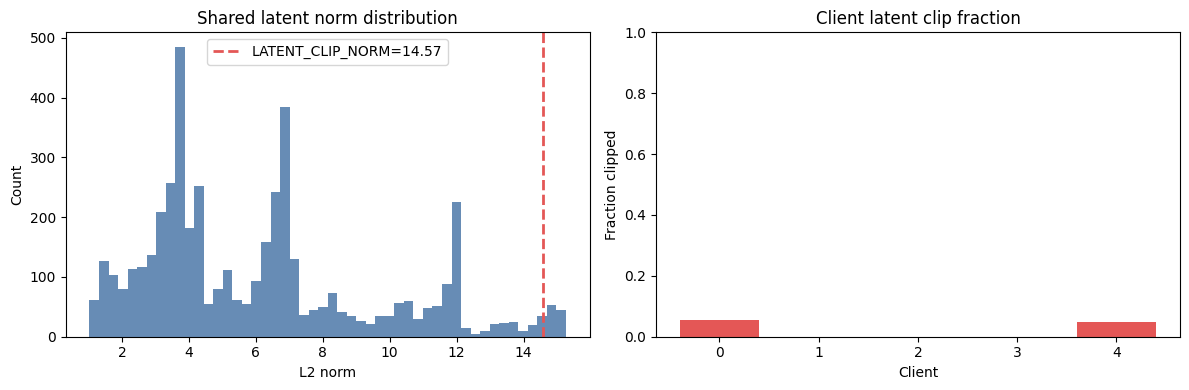

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(all_latent_norms, bins=50, color="#4C78A8", alpha=0.85)
axes[0].axvline(
    LATENT_CLIP_NORM,
    color="#E45756",
    linestyle="--",
    linewidth=2,
    label=f"LATENT_CLIP_NORM={LATENT_CLIP_NORM:.2f}",
)
axes[0].set_title("Shared latent norm distribution")
axes[0].set_xlabel("L2 norm")
axes[0].set_ylabel("Count")
axes[0].legend()

axes[1].bar(
    [row["client_id"] for row in multimodal_client_stats],
    [row["clip_fraction"] for row in multimodal_client_stats],
    color="#E45756",
)
axes[1].set_title("Client latent clip fraction")
axes[1].set_xlabel("Client")
axes[1].set_ylabel("Fraction clipped")
axes[1].set_ylim(0.0, 1.0)

plt.tight_layout()
plt.show()

In [15]:
# Cell 12: Aggregate private multimodal latent payloads on the server

import numpy as np
import matplotlib.pyplot as plt

try:
    from scipy.optimize import linear_sum_assignment
    HAVE_HUNGARIAN = True
except Exception:
    HAVE_HUNGARIAN = False
    print("scipy.optimize.linear_sum_assignment not available, using greedy matching fallback.")

MULTIMODAL_CLASS_NAMES = {0: "negative", 1: "positive"}

def match_latent_components(local_means, ref_means):
    cost = np.linalg.norm(local_means[:, None, :] - ref_means[None, :, :], axis=2)

    if HAVE_HUNGARIAN:
        row_ind, col_ind = linear_sum_assignment(cost)
        matches = list(zip(row_ind.tolist(), col_ind.tolist()))
    else:
        matches = []
        used_cols = set()
        row_order = np.argsort(cost.min(axis=1))

        for row in row_order:
            available = [col for col in range(cost.shape[1]) if col not in used_cols]
            if not available:
                break
            best_col = min(available, key=lambda col: cost[row, col])
            matches.append((int(row), int(best_col)))
            used_cols.add(int(best_col))

    return matches, cost

def aggregate_multimodal_biases(payloads):
    total_n = sum(sum(payload["n_samples"].values()) for payload in payloads.values())
    if total_n <= 0:
        raise ValueError("No samples found for bias aggregation.")

    agg_bias = None
    agg_mask_mean = None

    for client_id, payload in payloads.items():
        client_n = sum(payload["n_samples"].values())
        weight = client_n / total_n

        client_bias = payload["bias"].astype(np.float32)
        client_mask_mean = payload["mask_mean"].astype(np.float32)

        if agg_bias is None:
            agg_bias = weight * client_bias
            agg_mask_mean = weight * client_mask_mean
        else:
            agg_bias += weight * client_bias
            agg_mask_mean += weight * client_mask_mean

    return agg_bias.astype(np.float32), agg_mask_mean.astype(np.float32)

def aggregate_multimodal_class_gmms(payloads, target_class):
    participating = []
    for client_id, payload in payloads.items():
        if target_class in payload["models"] and payload["n_samples"].get(target_class, 0) > 0:
            participating.append(client_id)

    if not participating:
        return None

    reference_client = max(
        participating,
        key=lambda cid: (
            payloads[cid]["models"][target_class]["means"].shape[0],
            payloads[cid]["n_samples"][target_class],
        ),
    )

    ref_model = payloads[reference_client]["models"][target_class]
    ref_means = ref_model["means"].astype(np.float32)
    ref_covs = ref_model["covs"].astype(np.float32)

    target_k = ref_means.shape[0]
    latent_dim = ref_means.shape[1]

    total_class_samples = sum(payloads[cid]["n_samples"][target_class] for cid in participating)

    weight_mass = np.zeros(target_k, dtype=np.float64)
    mean_numer = np.zeros((target_k, latent_dim), dtype=np.float64)
    cov_numer = np.zeros((target_k, latent_dim), dtype=np.float64)
    contributor_count = np.zeros(target_k, dtype=np.int64)

    for client_id in participating:
        local_model = payloads[client_id]["models"][target_class]
        local_means = local_model["means"].astype(np.float32)
        local_covs = local_model["covs"].astype(np.float32)
        local_weights = local_model["weights"].astype(np.float32)
        local_n = payloads[client_id]["n_samples"][target_class]

        matches, _ = match_latent_components(local_means, ref_means)

        for local_idx, global_idx in matches:
            mass = float(local_n) * float(local_weights[local_idx])
            weight_mass[global_idx] += mass
            mean_numer[global_idx] += mass * local_means[local_idx]
            cov_numer[global_idx] += mass * local_covs[local_idx]

            if mass > 0:
                contributor_count[global_idx] += 1

    global_means = np.zeros_like(ref_means, dtype=np.float32)
    global_covs = np.zeros_like(ref_covs, dtype=np.float32)

    for k in range(target_k):
        if weight_mass[k] > 0:
            global_means[k] = (mean_numer[k] / weight_mass[k]).astype(np.float32)
            global_covs[k] = np.clip((cov_numer[k] / weight_mass[k]).astype(np.float32), 1e-5, None)
        else:
            global_means[k] = ref_means[k]
            global_covs[k] = np.clip(ref_covs[k], 1e-5, None)

    global_weights = (weight_mass / np.clip(weight_mass.sum(), 1e-12, None)).astype(np.float32)

    return {
        "means": global_means,
        "covs": global_covs,
        "weights": global_weights,
        "reference_client": int(reference_client),
        "contributors": contributor_count,
        "total_class_samples": int(total_class_samples),
    }

print("Aggregating private multimodal latent payloads on the server")

multimodal_cluster_payload = {
    0: aggregate_multimodal_class_gmms(multimodal_client_payloads, target_class=0),
    1: aggregate_multimodal_class_gmms(multimodal_client_payloads, target_class=1),
}

multimodal_cluster_bias, multimodal_cluster_mask_mean = aggregate_multimodal_biases(multimodal_client_payloads)

print(f"Global latent bias shape    : {multimodal_cluster_bias.shape}")
print(f"Global latent bias norm     : {np.linalg.norm(multimodal_cluster_bias):.4f}")
print(f"Average modality presence   : {multimodal_cluster_mask_mean.tolist()}")

for class_label in [0, 1]:
    payload = multimodal_cluster_payload[class_label]
    if payload is None:
        print(f"Class {class_label}: no aggregated payload")
        continue

    print(
        f"Class {class_label} ({MULTIMODAL_CLASS_NAMES[class_label]}): "
        f"components={len(payload['weights'])} | "
        f"total_class_samples={payload['total_class_samples']} | "
        f"reference_client={payload['reference_client']} | "
        f"contributors={payload['contributors'].tolist()}"
    )

Aggregating private multimodal latent payloads on the server
Global latent bias shape    : (64,)
Global latent bias norm     : 5.3986
Average modality presence   : [0.7822854518890381, 0.7780373692512512]
Class 0 (negative): components=4 | total_class_samples=1214 | reference_client=2 | contributors=[5, 4, 5, 5]
Class 1 (positive): components=4 | total_class_samples=3494 | reference_client=2 | contributors=[5, 5, 5, 5]


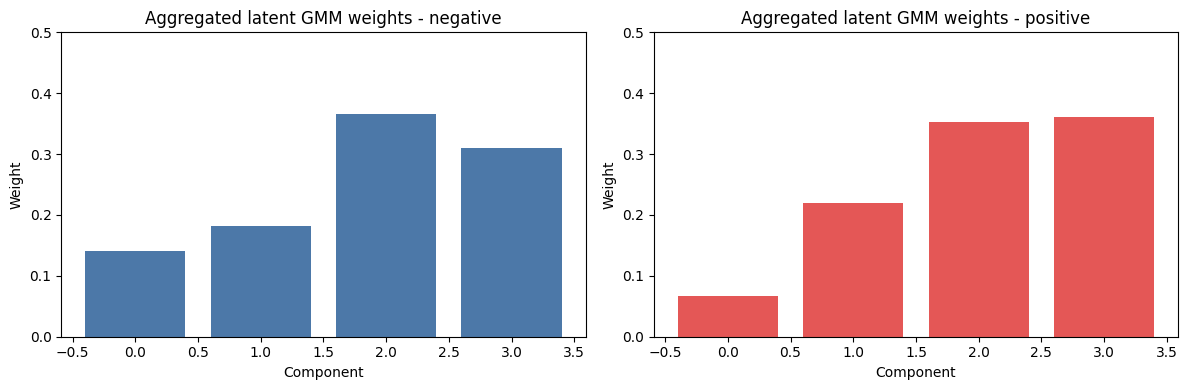

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for class_label, ax in zip([0, 1], axes):
    payload = multimodal_cluster_payload[class_label]

    if payload is None:
        ax.set_title(f"Class {class_label} - no payload")
        ax.axis("off")
        continue

    weights = payload["weights"]
    ax.bar(
        np.arange(len(weights)),
        weights,
        color="#4C78A8" if class_label == 0 else "#E45756",
    )
    ax.set_title(f"Aggregated latent GMM weights - {MULTIMODAL_CLASS_NAMES[class_label]}")
    ax.set_xlabel("Component")
    ax.set_ylabel("Weight")
    ax.set_ylim(0.0, max(0.5, float(weights.max()) + 0.05))

plt.tight_layout()
plt.show()

In [17]:
# Cell 13: Build the multimodal latent diffusion training set

import torch
from torch.utils.data import DataLoader, TensorDataset, WeightedRandomSampler

MULTIMODAL_DIFF_STEPS = 40
MULTIMODAL_DIFF_EPOCHS = 250
MULTIMODAL_DIFF_LR = 1e-3
MULTIMODAL_DIFF_LR_MIN = 1e-5
MULTIMODAL_DIFF_BATCH_SIZE = 512
MULTIMODAL_EMA_DECAY = 0.995
MULTIMODAL_CFG_SCALE = 1.5
MULTIMODAL_UNCOND_CLASS = 2
MULTIMODAL_GMM_SYNTH_PER_CLASS = 2500
MULTIMODAL_EARLY_STOP_PATIENCE = 30

def sample_from_aggregated_latent_gmm(model_dict, n_samples):
    means = model_dict["means"]
    covs = model_dict["covs"]
    weights = model_dict["weights"] / np.clip(model_dict["weights"].sum(), 1e-12, None)

    component_ids = np.random.choice(len(weights), size=n_samples, p=weights)
    samples = []

    for comp in component_ids:
        sample = np.random.normal(
            loc=means[comp],
            scale=np.sqrt(np.clip(covs[comp], 1e-5, None)),
        ).astype(np.float32)
        samples.append(sample)

    return np.vstack(samples).astype(np.float32)

print("Building multimodal latent diffusion training set")

latent_replay_X = np.vstack([
    client_latent_exports[cid]["debiased_latents"]
    for cid in range(NUM_CLIENTS)
]).astype(np.float32)

latent_replay_y = np.concatenate([
    client_latent_exports[cid]["labels"]
    for cid in range(NUM_CLIENTS)
]).astype(np.int64)

latent_gmm_X_parts = []
latent_gmm_y_parts = []

for class_label in [0, 1]:
    assert multimodal_cluster_payload[class_label] is not None, f"Missing aggregated payload for class {class_label}"

    class_samples = sample_from_aggregated_latent_gmm(
        multimodal_cluster_payload[class_label],
        MULTIMODAL_GMM_SYNTH_PER_CLASS,
    )
    latent_gmm_X_parts.append(class_samples)
    latent_gmm_y_parts.append(
        np.full(MULTIMODAL_GMM_SYNTH_PER_CLASS, class_label, dtype=np.int64)
    )

latent_gmm_X = np.vstack(latent_gmm_X_parts).astype(np.float32)
latent_gmm_y = np.concatenate(latent_gmm_y_parts).astype(np.int64)

multimodal_diff_X = np.vstack([latent_gmm_X, latent_replay_X]).astype(np.float32)
multimodal_diff_y = np.concatenate([latent_gmm_y, latent_replay_y]).astype(np.int64)

print(f"GMM latent synthetic samples : {len(latent_gmm_y)}")
print(f"Replay latent samples        : {len(latent_replay_y)}")
print(f"Total diffusion samples      : {len(multimodal_diff_y)}")
print(
    f"Class counts                 : "
    f"class0={np.sum(multimodal_diff_y == 0)}, "
    f"class1={np.sum(multimodal_diff_y == 1)}"
)

multimodal_val_latents = collect_latent_representations(
    global_multimodal_model,
    multimodal_val_loader,
    device=device,
)

val_latents_raw, val_labels_raw, val_masks_raw, _ = unpack_latent_export(multimodal_val_latents)
multimodal_val_latent_X = to_numpy_array(val_latents_raw, dtype=np.float32)
multimodal_val_latent_y = to_numpy_array(val_labels_raw, dtype=np.int64).reshape(-1)

print(f"Validation latent shape      : {multimodal_val_latent_X.shape}")
print(f"Validation label shape       : {multimodal_val_latent_y.shape}")

multimodal_class_counts = np.bincount(multimodal_diff_y, minlength=2)
multimodal_sample_weights = 1.0 / multimodal_class_counts[multimodal_diff_y]
multimodal_sample_weights = torch.tensor(multimodal_sample_weights, dtype=torch.double)

multimodal_diff_dataset = TensorDataset(
    torch.tensor(multimodal_diff_X, dtype=torch.float32),
    torch.tensor(multimodal_diff_y, dtype=torch.int64),
)

multimodal_diff_sampler = WeightedRandomSampler(
    weights=multimodal_sample_weights,
    num_samples=len(multimodal_sample_weights),
    replacement=True,
)

multimodal_diff_loader = DataLoader(
    multimodal_diff_dataset,
    batch_size=MULTIMODAL_DIFF_BATCH_SIZE,
    sampler=multimodal_diff_sampler,
    num_workers=0,
    pin_memory=True,
)

multimodal_val_diff_dataset = TensorDataset(
    torch.tensor(multimodal_val_latent_X, dtype=torch.float32),
    torch.tensor(multimodal_val_latent_y, dtype=torch.int64),
)

multimodal_val_diff_loader = DataLoader(
    multimodal_val_diff_dataset,
    batch_size=1024,
    shuffle=False,
    num_workers=0,
    pin_memory=True,
)

multimodal_betas = torch.linspace(1e-4, 0.02, MULTIMODAL_DIFF_STEPS, device=device)
multimodal_alphas = 1.0 - multimodal_betas
multimodal_alphas_cum = torch.cumprod(multimodal_alphas, dim=0)
MULTIMODAL_LATENT_DIM = multimodal_diff_X.shape[1]

print(f"Latent diffusion feature dim : {MULTIMODAL_LATENT_DIM}")
print(f"Train batches per epoch      : {len(multimodal_diff_loader)}")
print(f"Val batches                  : {len(multimodal_val_diff_loader)}")

Building multimodal latent diffusion training set
GMM latent synthetic samples : 5000
Replay latent samples        : 4708
Total diffusion samples      : 9708
Class counts                 : class0=3714, class1=5994
Validation latent shape      : (524, 64)
Validation label shape       : (524,)
Latent diffusion feature dim : 64
Train batches per epoch      : 19
Val batches                  : 1


In [18]:
# Cell 14: Define the multimodal latent diffusion model and helper functions

import copy
import math
import torch
import torch.nn as nn
import torch.nn.functional as F

def multimodal_sinusoidal_embedding(t, dim):
    half = dim // 2
    freqs = torch.exp(
        -math.log(10000) * torch.arange(half, dtype=torch.float32, device=t.device) / half
    )
    args = t * freqs.unsqueeze(0)
    emb = torch.cat([torch.sin(args), torch.cos(args)], dim=-1)

    if dim % 2 != 0:
        emb = F.pad(emb, (0, 1))

    return emb

class MultimodalLatentDenoiserCFG(nn.Module):
    def __init__(self, feature_dim=MULTIMODAL_LATENT_DIM, time_dim=128, hidden_dim=384, classes=3):
        super().__init__()
        self.time_dim = time_dim

        self.time_proj = nn.Sequential(
            nn.Linear(time_dim, time_dim),
            nn.GELU(),
            nn.Linear(time_dim, time_dim),
        )

        self.class_emb = nn.Embedding(classes, time_dim)
        self.input_proj = nn.Linear(feature_dim, hidden_dim)

        self.block1 = nn.Sequential(
            nn.Linear(hidden_dim + 2 * time_dim, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.GELU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.LayerNorm(hidden_dim),
        )

        self.block2 = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.GELU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.LayerNorm(hidden_dim),
        )

        self.output = nn.Linear(hidden_dim, feature_dim)
        nn.init.zeros_(self.output.weight)
        nn.init.zeros_(self.output.bias)

    def forward(self, x, t, c):
        t_emb = multimodal_sinusoidal_embedding(t, self.time_dim)
        t_emb = self.time_proj(t_emb)
        c_emb = self.class_emb(c)
        cond = torch.cat([t_emb, c_emb], dim=-1)

        h = self.input_proj(x)
        h = self.block1(torch.cat([h, cond], dim=-1)) + h
        h = self.block2(h) + h
        return self.output(h)

def update_multimodal_ema(ema_model, live_model, decay=MULTIMODAL_EMA_DECAY):
    with torch.no_grad():
        for ema_p, live_p in zip(ema_model.parameters(), live_model.parameters()):
            ema_p.data.mul_(decay).add_(live_p.data, alpha=1.0 - decay)

def make_multimodal_noisy_batch(x0):
    n = len(x0)
    t_idx = torch.randint(0, MULTIMODAL_DIFF_STEPS, (n,), device=x0.device)
    t_frac = (t_idx.float() / MULTIMODAL_DIFF_STEPS).unsqueeze(1)
    alpha_bar = multimodal_alphas_cum[t_idx].unsqueeze(1)
    noise = torch.randn_like(x0)
    x_t = torch.sqrt(alpha_bar) * x0 + torch.sqrt(1.0 - alpha_bar) * noise
    return x_t, noise, t_frac

@torch.no_grad()
def evaluate_multimodal_denoiser(model, loader):
    model.eval()
    total_loss = 0.0
    total_count = 0

    for X_batch, y_batch in loader:
        X_batch = X_batch.to(device, non_blocking=True)
        y_batch = y_batch.to(device, non_blocking=True)

        x_t, noise, t_frac = make_multimodal_noisy_batch(X_batch)
        pred = model(x_t, t_frac, y_batch)
        loss = F.mse_loss(pred, noise, reduction="mean")

        batch_size = len(X_batch)
        total_loss += loss.item() * batch_size
        total_count += batch_size

    return total_loss / max(total_count, 1)

multimodal_latent_denoiser = MultimodalLatentDenoiserCFG(
    feature_dim=MULTIMODAL_LATENT_DIM,
    time_dim=128,
    hidden_dim=384,
    classes=3,
).to(device)

multimodal_latent_ema = copy.deepcopy(multimodal_latent_denoiser).to(device)
for param in multimodal_latent_ema.parameters():
    param.requires_grad_(False)
multimodal_latent_ema.eval()

train_batch_X, train_batch_y = next(iter(multimodal_diff_loader))
train_batch_X = train_batch_X.to(device)
train_batch_y = train_batch_y.to(device)

x_t_preview, noise_preview, t_frac_preview = make_multimodal_noisy_batch(train_batch_X)
pred_preview = multimodal_latent_denoiser(x_t_preview, t_frac_preview, train_batch_y)
preview_loss = F.mse_loss(pred_preview, noise_preview).item()

preview_val_loss = evaluate_multimodal_denoiser(
    multimodal_latent_denoiser,
    multimodal_val_diff_loader,
)

param_count = sum(p.numel() for p in multimodal_latent_denoiser.parameters())

print("Multimodal latent denoiser sanity check")
print(f"  Parameter count     : {param_count:,}")
print(f"  Input batch shape   : {tuple(train_batch_X.shape)}")
print(f"  Noisy batch shape   : {tuple(x_t_preview.shape)}")
print(f"  Prediction shape    : {tuple(pred_preview.shape)}")
print(f"  Preview train loss  : {preview_loss:.4f}")
print(f"  Preview val loss    : {preview_val_loss:.4f}")
print(f"  Finite predictions  : {bool(torch.isfinite(pred_preview).all().item())}")

Multimodal latent denoiser sanity check
  Parameter count     : 775,744
  Input batch shape   : (512, 64)
  Noisy batch shape   : (512, 64)
  Prediction shape    : (512, 64)
  Preview train loss  : 0.9914
  Preview val loss    : 0.9871
  Finite predictions  : True


In [19]:
# Cell 15: Train the multimodal latent denoiser with a single tqdm

from tqdm.auto import tqdm

multimodal_optimizer = torch.optim.AdamW(
    multimodal_latent_denoiser.parameters(),
    lr=MULTIMODAL_DIFF_LR,
    weight_decay=1e-4,
)

multimodal_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    multimodal_optimizer,
    T_max=MULTIMODAL_DIFF_EPOCHS,
    eta_min=MULTIMODAL_DIFF_LR_MIN,
)

best_multimodal_val_loss = float("inf")
best_multimodal_epoch = -1
best_multimodal_live_state = None
best_multimodal_ema_state = None
multimodal_patience_counter = 0

multimodal_train_history = []
multimodal_val_history = []

num_train_batches = len(multimodal_diff_loader)

print("Training multimodal latent denoiser")
print(
    f"  epochs={MULTIMODAL_DIFF_EPOCHS} | "
    f"batch_size={MULTIMODAL_DIFF_BATCH_SIZE} | "
    f"train_batches={num_train_batches}"
)
print(
    f"  lr={MULTIMODAL_DIFF_LR} -> {MULTIMODAL_DIFF_LR_MIN} | "
    f"diffusion_steps={MULTIMODAL_DIFF_STEPS}"
)
print(
    f"  ema_decay={MULTIMODAL_EMA_DECAY} | "
    f"cfg_scale={MULTIMODAL_CFG_SCALE} | "
    f"patience={MULTIMODAL_EARLY_STOP_PATIENCE}"
)
print("  validation source: real multimodal validation latents")

epoch_bar = tqdm(
    range(1, MULTIMODAL_DIFF_EPOCHS + 1),
    desc="Multimodal latent denoiser",
    dynamic_ncols=True,
)

for epoch in epoch_bar:
    multimodal_latent_denoiser.train()
    running_loss = 0.0
    sample_count = 0
    last_batch_loss = None

    for batch_idx, (X_batch, y_batch) in enumerate(multimodal_diff_loader, start=1):
        X_batch = X_batch.to(device, non_blocking=True)
        y_batch = y_batch.to(device, non_blocking=True)

        x_t, noise, t_frac = make_multimodal_noisy_batch(X_batch)

        cond_labels = y_batch.clone()
        dropout_mask = torch.rand(len(cond_labels), device=device) < 0.10
        cond_labels[dropout_mask] = MULTIMODAL_UNCOND_CLASS

        multimodal_optimizer.zero_grad(set_to_none=True)
        pred_noise = multimodal_latent_denoiser(x_t, t_frac, cond_labels)
        loss = F.mse_loss(pred_noise, noise, reduction="mean")
        loss.backward()
        torch.nn.utils.clip_grad_norm_(multimodal_latent_denoiser.parameters(), max_norm=1.0)
        multimodal_optimizer.step()

        update_multimodal_ema(
            multimodal_latent_ema,
            multimodal_latent_denoiser,
            decay=MULTIMODAL_EMA_DECAY,
        )

        batch_size = len(X_batch)
        running_loss += loss.item() * batch_size
        sample_count += batch_size
        last_batch_loss = loss.item()

        if batch_idx == 1 or batch_idx == num_train_batches or batch_idx % 5 == 0:
            epoch_bar.set_postfix(
                epoch=f"{epoch}/{MULTIMODAL_DIFF_EPOCHS}",
                batch=f"{batch_idx}/{num_train_batches}",
                batch_loss=f"{last_batch_loss:.4f}",
                lr=f"{multimodal_optimizer.param_groups[0]['lr']:.2e}",
                refresh=True,
            )

    multimodal_scheduler.step()

    train_loss = running_loss / max(sample_count, 1)
    val_loss = evaluate_multimodal_denoiser(
        multimodal_latent_ema,
        multimodal_val_diff_loader,
    )

    multimodal_train_history.append(train_loss)
    multimodal_val_history.append(val_loss)

    improved = val_loss < (best_multimodal_val_loss - 1e-4)
    if improved:
        best_multimodal_val_loss = val_loss
        best_multimodal_epoch = epoch
        best_multimodal_live_state = copy.deepcopy(multimodal_latent_denoiser.state_dict())
        best_multimodal_ema_state = copy.deepcopy(multimodal_latent_ema.state_dict())
        multimodal_patience_counter = 0
    else:
        multimodal_patience_counter += 1

    epoch_bar.set_postfix(
        epoch=f"{epoch}/{MULTIMODAL_DIFF_EPOCHS}",
        train=f"{train_loss:.4f}",
        val=f"{val_loss:.4f}",
        best=f"{best_multimodal_val_loss:.4f}",
        patience=f"{multimodal_patience_counter}/{MULTIMODAL_EARLY_STOP_PATIENCE}",
        lr=f"{multimodal_optimizer.param_groups[0]['lr']:.2e}",
        refresh=True,
    )

    if epoch == 1 or epoch % 10 == 0:
        print(
            f"Epoch {epoch:>3} | "
            f"train_loss={train_loss:.4f} | "
            f"val_loss={val_loss:.4f} | "
            f"best_val={best_multimodal_val_loss:.4f}"
        )

    if multimodal_patience_counter >= MULTIMODAL_EARLY_STOP_PATIENCE:
        print(f"\nEarly stopping triggered at epoch {epoch}")
        break

if best_multimodal_live_state is None or best_multimodal_ema_state is None:
    raise RuntimeError("Training did not produce a valid checkpoint.")

multimodal_latent_denoiser.load_state_dict(best_multimodal_live_state)
multimodal_latent_ema.load_state_dict(best_multimodal_ema_state)
multimodal_latent_denoiser.eval()
multimodal_latent_ema.eval()

print("\nBest multimodal latent denoiser summary")
print(f"  Best epoch     : {best_multimodal_epoch}")
print(f"  Best val loss  : {best_multimodal_val_loss:.4f}")
print(f"  Epochs trained : {len(multimodal_train_history)}")

Training multimodal latent denoiser
  epochs=250 | batch_size=512 | train_batches=19
  lr=0.001 -> 1e-05 | diffusion_steps=40
  ema_decay=0.995 | cfg_scale=1.5 | patience=30
  validation source: real multimodal validation latents


Multimodal latent denoiser:   0%|          | 0/250 [00:00<?, ?it/s]

Epoch   1 | train_loss=0.8681 | val_loss=0.9916 | best_val=0.9916
Epoch  10 | train_loss=0.3974 | val_loss=0.6111 | best_val=0.6111
Epoch  20 | train_loss=0.3752 | val_loss=0.4931 | best_val=0.4757
Epoch  30 | train_loss=0.3615 | val_loss=0.5244 | best_val=0.4741
Epoch  40 | train_loss=0.3469 | val_loss=0.5652 | best_val=0.4741
Epoch  50 | train_loss=0.3429 | val_loss=0.5780 | best_val=0.4741

Early stopping triggered at epoch 56

Best multimodal latent denoiser summary
  Best epoch     : 26
  Best val loss  : 0.4741
  Epochs trained : 56


Multimodal latent denoiser training summary
  Best epoch        : 26
  Best val loss     : 0.4741
  Epochs completed  : 56
  Final train loss  : 0.3455
  Final val loss    : 0.5726


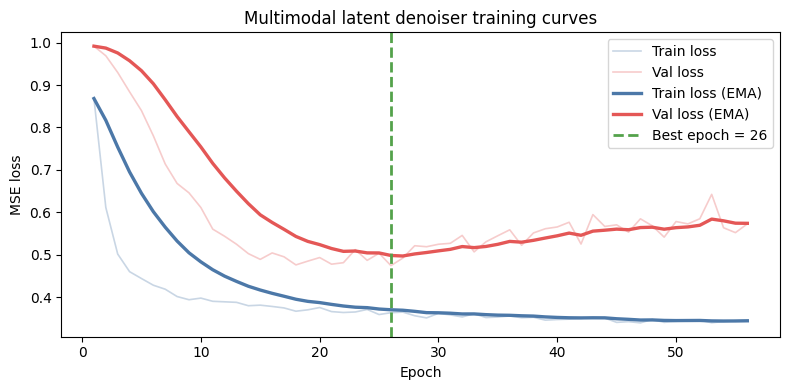

Generalization drift after best epoch : +0.0985
Smoothing alpha used                  : 0.20


In [22]:
# Cell 16: Inspect multimodal latent denoiser training curves

local_smooth_alpha = float(globals().get("PLOT_SMOOTH_ALPHA", 0.20))

print("Multimodal latent denoiser training summary")
print(f"  Best epoch        : {best_multimodal_epoch}")
print(f"  Best val loss     : {best_multimodal_val_loss:.4f}")
print(f"  Epochs completed  : {len(multimodal_train_history)}")
print(f"  Final train loss  : {multimodal_train_history[-1]:.4f}")
print(f"  Final val loss    : {multimodal_val_history[-1]:.4f}")

epochs = np.arange(1, len(multimodal_train_history) + 1)
train_curve = np.asarray(multimodal_train_history, dtype=np.float32)
val_curve = np.asarray(multimodal_val_history, dtype=np.float32)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(epochs, train_curve, color="#4C78A8", alpha=0.30, linewidth=1.2, label="Train loss")
ax.plot(epochs, val_curve, color="#E45756", alpha=0.30, linewidth=1.2, label="Val loss")

if len(train_curve) > 1:
    train_smooth = train_curve.copy()
    val_smooth = val_curve.copy()

    for idx in range(1, len(train_curve)):
        train_smooth[idx] = (
            local_smooth_alpha * train_curve[idx]
            + (1.0 - local_smooth_alpha) * train_smooth[idx - 1]
        )
        val_smooth[idx] = (
            local_smooth_alpha * val_curve[idx]
            + (1.0 - local_smooth_alpha) * val_smooth[idx - 1]
        )

    ax.plot(epochs, train_smooth, color="#4C78A8", linewidth=2.4, label="Train loss (EMA)")
    ax.plot(epochs, val_smooth, color="#E45756", linewidth=2.4, label="Val loss (EMA)")

ax.axvline(
    best_multimodal_epoch,
    color="#54A24B",
    linestyle="--",
    linewidth=2,
    label=f"Best epoch = {best_multimodal_epoch}",
)
ax.set_title("Multimodal latent denoiser training curves")
ax.set_xlabel("Epoch")
ax.set_ylabel("MSE loss")
ax.legend()
plt.tight_layout()
plt.show()

best_gap = multimodal_val_history[-1] - best_multimodal_val_loss
print(f"Generalization drift after best epoch : {best_gap:+.4f}")
print(f"Smoothing alpha used                  : {local_smooth_alpha:.2f}")

In [23]:
# Cell 17: Generate synthetic multimodal latents with tqdm

MULTIMODAL_SYNTH_PER_CLASS = 2500
MULTIMODAL_GEN_BATCH_SIZE = 512

@torch.no_grad()
def sample_multimodal_synthetic_latents(
    num_samples,
    class_label,
    batch_size=MULTIMODAL_GEN_BATCH_SIZE,
    cfg_scale=MULTIMODAL_CFG_SCALE,
):
    multimodal_latent_ema.eval()

    generated_batches = []
    remaining = num_samples
    progress = tqdm(
        total=num_samples,
        desc=f"Synth latent class {class_label}",
        dynamic_ncols=True,
    )

    while remaining > 0:
        current_bs = min(batch_size, remaining)

        x_t = torch.randn(current_bs, MULTIMODAL_LATENT_DIM, device=device)
        c_cond = torch.full((current_bs,), class_label, dtype=torch.long, device=device)
        c_uncond = torch.full(
            (current_bs,),
            MULTIMODAL_UNCOND_CLASS,
            dtype=torch.long,
            device=device,
        )

        for step in reversed(range(MULTIMODAL_DIFF_STEPS)):
            t_frac = torch.full(
                (current_bs, 1),
                step / MULTIMODAL_DIFF_STEPS,
                dtype=torch.float32,
                device=device,
            )

            eps_cond = multimodal_latent_ema(x_t, t_frac, c_cond)
            eps_uncond = multimodal_latent_ema(x_t, t_frac, c_uncond)
            eps = eps_uncond + cfg_scale * (eps_cond - eps_uncond)

            alpha_bar_t = multimodal_alphas_cum[step]
            x0_pred = (x_t - torch.sqrt(1.0 - alpha_bar_t) * eps) / torch.sqrt(alpha_bar_t)

            if step > 0:
                alpha_bar_prev = multimodal_alphas_cum[step - 1]
                x_t = (
                    torch.sqrt(alpha_bar_prev) * x0_pred
                    + torch.sqrt(1.0 - alpha_bar_prev) * eps
                )
            else:
                x_t = x0_pred

        generated_batches.append(x_t.detach().cpu().numpy().astype(np.float32))
        remaining -= current_bs
        progress.update(current_bs)

    progress.close()
    return np.vstack(generated_batches).astype(np.float32)

print("Generating synthetic multimodal latents")

multimodal_synthetic_dataset = {}
for cls in [0, 1]:
    multimodal_synthetic_dataset[cls] = sample_multimodal_synthetic_latents(
        num_samples=MULTIMODAL_SYNTH_PER_CLASS,
        class_label=cls,
        batch_size=MULTIMODAL_GEN_BATCH_SIZE,
        cfg_scale=MULTIMODAL_CFG_SCALE,
    )
    print(
        f"  Class {cls}: shape={multimodal_synthetic_dataset[cls].shape}"
    )

multimodal_X_syn = np.vstack([
    multimodal_synthetic_dataset[0],
    multimodal_synthetic_dataset[1],
]).astype(np.float32)

multimodal_y_syn = np.concatenate([
    np.zeros(len(multimodal_synthetic_dataset[0]), dtype=np.int64),
    np.ones(len(multimodal_synthetic_dataset[1]), dtype=np.int64),
])

print("\nSynthetic multimodal latent dataset ready")
print(f"  X shape      : {multimodal_X_syn.shape}")
print(f"  y shape      : {multimodal_y_syn.shape}")
print(
    f"  class0={np.sum(multimodal_y_syn == 0)}, "
    f"class1={np.sum(multimodal_y_syn == 1)}"
)
print(f"  latent dim   : {multimodal_X_syn.shape[1]}")

Generating synthetic multimodal latents


Synth latent class 0:   0%|          | 0/2500 [00:00<?, ?it/s]

  Class 0: shape=(2500, 64)


Synth latent class 1:   0%|          | 0/2500 [00:00<?, ?it/s]

  Class 1: shape=(2500, 64)

Synthetic multimodal latent dataset ready
  X shape      : (5000, 64)
  y shape      : (5000,)
  class0=2500, class1=2500
  latent dim   : 64


In [25]:
# Cell 18: Diagnose synthetic vs real multimodal latent distributions

import numpy as np
import torch
import matplotlib.pyplot as plt

diagnostic_seed = int(globals().get("SEED", 42))
diagnostic_rng = np.random.default_rng(diagnostic_seed)
diagnostic_device = globals().get(
    "device",
    torch.device("cuda" if torch.cuda.is_available() else "cpu"),
)

def _resolve_multimodal_val_latents_and_labels():
    if (
        "multimodal_val_diff_loader" in globals()
        and hasattr(multimodal_val_diff_loader, "dataset")
        and hasattr(multimodal_val_diff_loader.dataset, "tensors")
    ):
        tensors = multimodal_val_diff_loader.dataset.tensors
        return (
            tensors[0].detach().cpu().numpy().astype(np.float32),
            tensors[1].detach().cpu().numpy().astype(np.int64),
        )

    fallback_pairs = [
        ("multimodal_val_latents", "multimodal_val_labels"),
        ("val_multimodal_latents", "val_multimodal_labels"),
        ("X_val_multimodal_latents", "y_val_multimodal_latents"),
    ]

    for x_name, y_name in fallback_pairs:
        if x_name in globals() and y_name in globals():
            return (
                np.asarray(globals()[x_name], dtype=np.float32),
                np.asarray(globals()[y_name], dtype=np.int64),
            )

    raise NameError(
        "Could not find real multimodal validation latents. "
        "Expected multimodal_val_diff_loader or a fallback latent/label pair."
    )

def multimodal_median_heuristic_sigma(X, Y):
    joined = np.vstack([X, Y]).astype(np.float32)
    joined_t = torch.tensor(joined, dtype=torch.float32)

    if len(joined_t) > 400:
        idx = torch.randperm(len(joined_t))[:400]
        joined_t = joined_t[idx]

    dists = torch.pdist(joined_t)
    sigma = torch.median(dists).item() if len(dists) > 0 else 1.0
    return max(float(sigma), 1e-3)

def multimodal_mmd_rbf(X, Y, device=diagnostic_device):
    X_t = torch.tensor(X, dtype=torch.float32, device=device)
    Y_t = torch.tensor(Y, dtype=torch.float32, device=device)

    sigma = multimodal_median_heuristic_sigma(X, Y)
    gamma = 1.0 / (2.0 * sigma * sigma)

    XX = torch.exp(-gamma * torch.cdist(X_t, X_t).pow(2)).mean()
    YY = torch.exp(-gamma * torch.cdist(Y_t, Y_t).pow(2)).mean()
    XY = torch.exp(-gamma * torch.cdist(X_t, Y_t).pow(2)).mean()

    return float((XX + YY - 2.0 * XY).item()), sigma

def multimodal_covariance_gap(X, Y):
    cov_x = np.cov(X, rowvar=False)
    cov_y = np.cov(Y, rowvar=False)
    return float(np.linalg.norm(cov_x - cov_y, ord="fro") / X.shape[1])

multimodal_real_val_latents, multimodal_real_val_labels = _resolve_multimodal_val_latents_and_labels()

print("Synthetic vs real multimodal validation diagnostics")
print(f"  Real val latents  : {multimodal_real_val_latents.shape}")
print(f"  Synthetic latents : {multimodal_X_syn.shape}")

multimodal_diagnostics = {}

for cls in [0, 1]:
    real_cls = multimodal_real_val_latents[multimodal_real_val_labels == cls].astype(np.float32)
    synth_cls = multimodal_X_syn[multimodal_y_syn == cls].astype(np.float32)

    assert len(real_cls) > 0, f"No real validation latents found for class {cls}"
    assert len(synth_cls) > 0, f"No synthetic latents found for class {cls}"

    n_eval = min(len(real_cls), len(synth_cls), 300)
    real_idx = diagnostic_rng.choice(len(real_cls), size=n_eval, replace=False)
    synth_idx = diagnostic_rng.choice(len(synth_cls), size=n_eval, replace=False)

    real_eval = real_cls[real_idx]
    synth_eval = synth_cls[synth_idx]

    mean_gap = float(np.linalg.norm(real_eval.mean(axis=0) - synth_eval.mean(axis=0)))
    cov_gap = multimodal_covariance_gap(real_eval, synth_eval)
    mmd_value, sigma = multimodal_mmd_rbf(real_eval, synth_eval)

    multimodal_diagnostics[cls] = {
        "n_eval": int(n_eval),
        "mean_gap": mean_gap,
        "cov_gap": cov_gap,
        "mmd": mmd_value,
        "sigma": sigma,
    }

    print(
        f"  Class {cls}: "
        f"n_eval={n_eval}, "
        f"mean_gap={mean_gap:.4f}, "
        f"cov_gap={cov_gap:.4f}, "
        f"MMD={mmd_value:.4f}, "
        f"sigma={sigma:.4f}"
    )

Synthetic vs real multimodal validation diagnostics
  Real val latents  : (524, 64)
  Synthetic latents : (5000, 64)
  Class 0: n_eval=135, mean_gap=7.2597, cov_gap=0.0922, MMD=0.5945, sigma=7.4810
  Class 1: n_eval=300, mean_gap=8.6290, cov_gap=0.1082, MMD=0.7016, sigma=7.7396


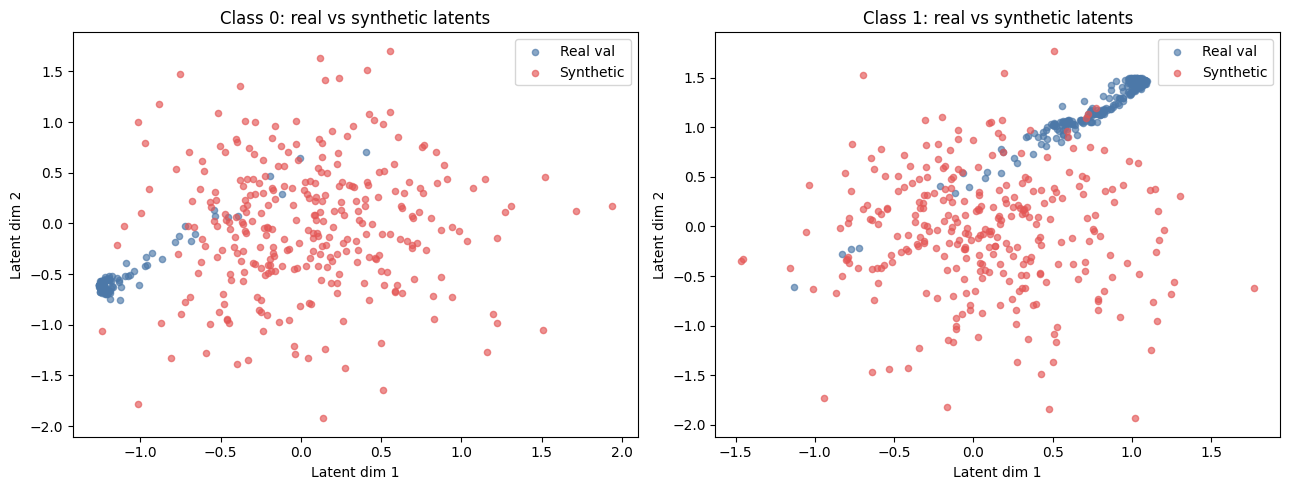

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for cls, ax in zip([0, 1], axes):
    real_cls = multimodal_real_val_latents[multimodal_real_val_labels == cls].astype(np.float32)
    synth_cls = multimodal_X_syn[multimodal_y_syn == cls].astype(np.float32)

    real_n = min(len(real_cls), 300)
    synth_n = min(len(synth_cls), 300)

    real_idx = diagnostic_rng.choice(len(real_cls), size=real_n, replace=False)
    synth_idx = diagnostic_rng.choice(len(synth_cls), size=synth_n, replace=False)

    ax.scatter(
        real_cls[real_idx, 0],
        real_cls[real_idx, 1],
        s=20,
        alpha=0.65,
        color="#4C78A8",
        label="Real val",
    )
    ax.scatter(
        synth_cls[synth_idx, 0],
        synth_cls[synth_idx, 1],
        s=20,
        alpha=0.65,
        color="#E45756",
        label="Synthetic",
    )

    ax.set_title(f"Class {cls}: real vs synthetic latents")
    ax.set_xlabel("Latent dim 1")
    ax.set_ylabel("Latent dim 2")
    ax.legend()

plt.tight_layout()
plt.show()

In [27]:
# Cell 19: Train a synthetic-only multimodal latent classifier

import copy
import numpy as np
import torch
import torch.nn as nn

from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
)
from torch.utils.data import DataLoader, TensorDataset
from tqdm.auto import tqdm

multimodal_cls_seed = int(globals().get("SEED", 42))
np.random.seed(multimodal_cls_seed)
torch.manual_seed(multimodal_cls_seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(multimodal_cls_seed)

multimodal_cls_device = globals().get(
    "device",
    torch.device("cuda" if torch.cuda.is_available() else "cpu"),
)

MULTIMODAL_CLS_EPOCHS = 200
MULTIMODAL_CLS_PATIENCE = 25
MULTIMODAL_CLS_BATCH_SIZE = 256
MULTIMODAL_CLS_LR = 3e-4
MULTIMODAL_CLS_LR_MIN = 1e-5

def _to_numpy(value, dtype=None):
    if torch.is_tensor(value):
        array = value.detach().cpu().numpy()
    else:
        array = np.asarray(value)
    if dtype is not None:
        array = array.astype(dtype)
    return array

def _resolve_from_loader(loader_name, expected_dim):
    if loader_name not in globals():
        return None

    loader = globals()[loader_name]
    if not hasattr(loader, "dataset") or not hasattr(loader.dataset, "tensors"):
        return None

    tensors = loader.dataset.tensors
    if len(tensors) < 2:
        return None

    X = _to_numpy(tensors[0], np.float32)
    y = _to_numpy(tensors[1], np.int64).reshape(-1)

    if X.ndim != 2 or X.shape[1] != expected_dim or len(X) != len(y):
        return None

    return X, y, loader_name

def _resolve_from_names(name_pairs, expected_dim):
    for x_name, y_name in name_pairs:
        if x_name not in globals() or y_name not in globals():
            continue

        X = _to_numpy(globals()[x_name], np.float32)
        y = _to_numpy(globals()[y_name], np.int64).reshape(-1)

        if X.ndim != 2 or X.shape[1] != expected_dim or len(X) != len(y):
            continue

        return X, y, f"{x_name} / {y_name}"

    return None

def _resolve_multimodal_split(split_name, expected_dim):
    if split_name == "val":
        loader_candidates = [
            "multimodal_val_diff_loader",
            "multimodal_val_loader",
            "multimodal_eval_val_loader",
        ]
        name_candidates = [
            ("multimodal_val_latents", "multimodal_val_labels"),
            ("multimodal_val_latents", "multimodal_val_targets"),
            ("val_multimodal_latents", "val_multimodal_labels"),
            ("val_multimodal_latents", "val_multimodal_targets"),
            ("X_val_multimodal_latents", "y_val_multimodal_latents"),
            ("X_val_multimodal", "y_val_multimodal"),
        ]
    elif split_name == "test":
        loader_candidates = [
            "multimodal_test_loader",
            "multimodal_eval_test_loader",
            "multimodal_test_diff_loader",
        ]
        name_candidates = [
            ("multimodal_test_latents", "multimodal_test_labels"),
            ("multimodal_test_latents", "multimodal_test_targets"),
            ("test_multimodal_latents", "test_multimodal_labels"),
            ("test_multimodal_latents", "test_multimodal_targets"),
            ("X_test_multimodal_latents", "y_test_multimodal_latents"),
            ("X_test_multimodal", "y_test_multimodal"),
        ]
    else:
        raise ValueError(f"Unsupported split: {split_name}")

    for loader_name in loader_candidates:
        resolved = _resolve_from_loader(loader_name, expected_dim)
        if resolved is not None:
            return resolved

    resolved = _resolve_from_names(name_candidates, expected_dim)
    if resolved is not None:
        return resolved

    raise NameError(
        f"Could not resolve multimodal {split_name} latents. "
        f"Expected one of the common loader or array names for that split."
    )

def compute_binary_metrics(y_true, probs, threshold):
    preds = (probs >= threshold).astype(np.int64)

    accuracy = accuracy_score(y_true, preds)
    auc = roc_auc_score(y_true, probs)
    precision = precision_score(y_true, preds, zero_division=0)
    recall = recall_score(y_true, preds, zero_division=0)
    f1 = f1_score(y_true, preds, zero_division=0)

    tn, fp, fn, tp = confusion_matrix(y_true, preds, labels=[0, 1]).ravel()
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0
    balanced_accuracy = 0.5 * (recall + specificity)

    return {
        "accuracy": float(accuracy),
        "auc": float(auc),
        "precision": float(precision),
        "recall": float(recall),
        "specificity": float(specificity),
        "f1": float(f1),
        "balanced_accuracy": float(balanced_accuracy),
        "tn": int(tn),
        "fp": int(fp),
        "fn": int(fn),
        "tp": int(tp),
        "preds": preds,
    }

@torch.no_grad()
def evaluate_multimodal_classifier(model, loader, criterion, device):
    model.eval()

    total_loss = 0.0
    total_count = 0
    logits_all = []
    targets_all = []

    for X_batch, y_batch in loader:
        X_batch = X_batch.to(device, non_blocking=True)
        y_batch = y_batch.to(device, non_blocking=True)

        logits = model(X_batch)
        loss = criterion(logits, y_batch)

        batch_size = len(X_batch)
        total_loss += loss.item() * batch_size
        total_count += batch_size

        logits_all.append(logits.detach().cpu().numpy())
        targets_all.append(y_batch.detach().cpu().numpy())

    logits_all = np.vstack(logits_all).reshape(-1)
    targets_all = np.vstack(targets_all).reshape(-1).astype(np.int64)
    probs_all = 1.0 / (1.0 + np.exp(-logits_all))

    avg_loss = total_loss / max(total_count, 1)
    auc = roc_auc_score(targets_all, probs_all)

    return {
        "loss": float(avg_loss),
        "auc": float(auc),
        "probs": probs_all,
        "targets": targets_all,
    }

class MultimodalLatentClassifier(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 192),
            nn.LayerNorm(192),
            nn.GELU(),
            nn.Dropout(0.20),
            nn.Linear(192, 96),
            nn.LayerNorm(96),
            nn.GELU(),
            nn.Dropout(0.10),
            nn.Linear(96, 1),
        )

    def forward(self, x):
        return self.net(x)

multimodal_input_dim = int(multimodal_X_syn.shape[1])

multimodal_X_val_real, multimodal_y_val_real, multimodal_val_source = _resolve_multimodal_split(
    "val",
    expected_dim=multimodal_input_dim,
)
multimodal_X_test_real, multimodal_y_test_real, multimodal_test_source = _resolve_multimodal_split(
    "test",
    expected_dim=multimodal_input_dim,
)

print("Resolved multimodal latent splits")
print(f"  Synthetic train source : multimodal_X_syn / multimodal_y_syn")
print(f"  Validation source      : {multimodal_val_source}")
print(f"  Test source            : {multimodal_test_source}")
print(f"  Synthetic train shape  : {multimodal_X_syn.shape}")
print(f"  Validation shape       : {multimodal_X_val_real.shape}")
print(f"  Test shape             : {multimodal_X_test_real.shape}")

multimodal_train_cls_dataset = TensorDataset(
    torch.tensor(multimodal_X_syn, dtype=torch.float32),
    torch.tensor(multimodal_y_syn.astype(np.float32), dtype=torch.float32).unsqueeze(1),
)
multimodal_val_cls_dataset = TensorDataset(
    torch.tensor(multimodal_X_val_real, dtype=torch.float32),
    torch.tensor(multimodal_y_val_real.astype(np.float32), dtype=torch.float32).unsqueeze(1),
)
multimodal_test_cls_dataset = TensorDataset(
    torch.tensor(multimodal_X_test_real, dtype=torch.float32),
    torch.tensor(multimodal_y_test_real.astype(np.float32), dtype=torch.float32).unsqueeze(1),
)

multimodal_train_cls_loader = DataLoader(
    multimodal_train_cls_dataset,
    batch_size=MULTIMODAL_CLS_BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    pin_memory=True,
)
multimodal_val_cls_loader = DataLoader(
    multimodal_val_cls_dataset,
    batch_size=1024,
    shuffle=False,
    num_workers=0,
    pin_memory=True,
)
multimodal_test_cls_loader = DataLoader(
    multimodal_test_cls_dataset,
    batch_size=1024,
    shuffle=False,
    num_workers=0,
    pin_memory=True,
)

multimodal_latent_classifier = MultimodalLatentClassifier(
    input_dim=multimodal_input_dim
).to(multimodal_cls_device)

multimodal_cls_criterion = nn.BCEWithLogitsLoss()
multimodal_cls_optimizer = torch.optim.AdamW(
    multimodal_latent_classifier.parameters(),
    lr=MULTIMODAL_CLS_LR,
    weight_decay=1e-3,
)
multimodal_cls_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    multimodal_cls_optimizer,
    T_max=MULTIMODAL_CLS_EPOCHS,
    eta_min=MULTIMODAL_CLS_LR_MIN,
)

multimodal_syn_best_state = None
multimodal_syn_best_epoch = -1
multimodal_syn_best_val_auc = -np.inf
multimodal_syn_best_val_loss = np.inf
multimodal_syn_patience_counter = 0

multimodal_syn_train_loss_history = []
multimodal_syn_val_loss_history = []
multimodal_syn_val_auc_history = []

print("\nTraining classifier on SYNTHETIC multimodal latents")
print(
    f"  epochs={MULTIMODAL_CLS_EPOCHS} | "
    f"batch_size={MULTIMODAL_CLS_BATCH_SIZE} | "
    f"lr={MULTIMODAL_CLS_LR} -> {MULTIMODAL_CLS_LR_MIN} | "
    f"patience={MULTIMODAL_CLS_PATIENCE}"
)

epoch_bar = tqdm(
    range(MULTIMODAL_CLS_EPOCHS),
    desc="Synthetic multimodal classifier",
    dynamic_ncols=True,
)

for epoch in epoch_bar:
    multimodal_latent_classifier.train()
    running_loss = 0.0
    sample_count = 0

    for X_batch, y_batch in multimodal_train_cls_loader:
        X_batch = X_batch.to(multimodal_cls_device, non_blocking=True)
        y_batch = y_batch.to(multimodal_cls_device, non_blocking=True)

        multimodal_cls_optimizer.zero_grad(set_to_none=True)
        logits = multimodal_latent_classifier(X_batch)
        loss = multimodal_cls_criterion(logits, y_batch)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(multimodal_latent_classifier.parameters(), max_norm=1.0)
        multimodal_cls_optimizer.step()

        batch_size = len(X_batch)
        running_loss += loss.item() * batch_size
        sample_count += batch_size

    multimodal_cls_scheduler.step()

    train_loss = running_loss / max(sample_count, 1)
    val_stats = evaluate_multimodal_classifier(
        multimodal_latent_classifier,
        multimodal_val_cls_loader,
        multimodal_cls_criterion,
        multimodal_cls_device,
    )
    val_loss = val_stats["loss"]
    val_auc = val_stats["auc"]

    multimodal_syn_train_loss_history.append(float(train_loss))
    multimodal_syn_val_loss_history.append(float(val_loss))
    multimodal_syn_val_auc_history.append(float(val_auc))

    improved = (
        val_auc > multimodal_syn_best_val_auc + 1e-4
        or (
            abs(val_auc - multimodal_syn_best_val_auc) <= 1e-4
            and val_loss < multimodal_syn_best_val_loss
        )
    )

    if improved:
        multimodal_syn_best_state = copy.deepcopy(multimodal_latent_classifier.state_dict())
        multimodal_syn_best_epoch = epoch + 1
        multimodal_syn_best_val_auc = float(val_auc)
        multimodal_syn_best_val_loss = float(val_loss)
        multimodal_syn_patience_counter = 0
    else:
        multimodal_syn_patience_counter += 1

    epoch_bar.set_postfix(
        train=f"{train_loss:.4f}",
        val=f"{val_loss:.4f}",
        auc=f"{val_auc:.4f}",
        best=f"{multimodal_syn_best_val_auc:.4f}",
        patience=f"{multimodal_syn_patience_counter}/{MULTIMODAL_CLS_PATIENCE}",
    )

    if (epoch + 1) % 10 == 0 or epoch == 0:
        print(
            f"Epoch {epoch + 1:>3} | "
            f"train_loss={train_loss:.4f} | "
            f"val_loss={val_loss:.4f} | "
            f"val_auc={val_auc:.4f} | "
            f"best_val_auc={multimodal_syn_best_val_auc:.4f}"
        )

    if multimodal_syn_patience_counter >= MULTIMODAL_CLS_PATIENCE:
        print(f"\nEarly stopping triggered at epoch {epoch + 1}")
        break

multimodal_latent_classifier.load_state_dict(multimodal_syn_best_state)
multimodal_latent_classifier.eval()

print(f"\nBest synthetic multimodal epoch : {multimodal_syn_best_epoch}")
print(f"Best synthetic multimodal val AUC  : {multimodal_syn_best_val_auc:.4f}")
print(f"Best synthetic multimodal val loss : {multimodal_syn_best_val_loss:.4f}")

multimodal_syn_val_stats = evaluate_multimodal_classifier(
    multimodal_latent_classifier,
    multimodal_val_cls_loader,
    multimodal_cls_criterion,
    multimodal_cls_device,
)
multimodal_syn_val_probs = multimodal_syn_val_stats["probs"]
multimodal_syn_val_targets = multimodal_syn_val_stats["targets"]

multimodal_syn_threshold_grid = np.linspace(0.05, 0.95, 181)
multimodal_syn_threshold_rows = []

for threshold in multimodal_syn_threshold_grid:
    threshold_metrics = compute_binary_metrics(
        multimodal_syn_val_targets,
        multimodal_syn_val_probs,
        threshold,
    )
    multimodal_syn_threshold_rows.append(
        {
            "threshold": float(threshold),
            "f1": float(threshold_metrics["f1"]),
            "balanced_accuracy": float(threshold_metrics["balanced_accuracy"]),
            "recall": float(threshold_metrics["recall"]),
            "specificity": float(threshold_metrics["specificity"]),
        }
    )

multimodal_syn_best_threshold_row = max(
    multimodal_syn_threshold_rows,
    key=lambda row: (row["balanced_accuracy"], row["f1"]),
)
multimodal_syn_best_threshold = float(multimodal_syn_best_threshold_row["threshold"])

print(f"\nChosen multimodal threshold : {multimodal_syn_best_threshold:.3f}")
print(
    f"Validation @ threshold      : "
    f"bal_acc={multimodal_syn_best_threshold_row['balanced_accuracy']:.4f}, "
    f"f1={multimodal_syn_best_threshold_row['f1']:.4f}, "
    f"recall={multimodal_syn_best_threshold_row['recall']:.4f}, "
    f"specificity={multimodal_syn_best_threshold_row['specificity']:.4f}"
)

multimodal_syn_test_stats = evaluate_multimodal_classifier(
    multimodal_latent_classifier,
    multimodal_test_cls_loader,
    multimodal_cls_criterion,
    multimodal_cls_device,
)
multimodal_syn_test_probs = multimodal_syn_test_stats["probs"]
multimodal_syn_test_targets = multimodal_syn_test_stats["targets"]
multimodal_syn_test_metrics = compute_binary_metrics(
    multimodal_syn_test_targets,
    multimodal_syn_test_probs,
    multimodal_syn_best_threshold,
)

multimodal_synthetic_summary = {
    "threshold": float(multimodal_syn_best_threshold),
    "val_auc": float(multimodal_syn_best_val_auc),
    "val_loss": float(multimodal_syn_best_val_loss),
    "test_auc": float(multimodal_syn_test_metrics["auc"]),
    "test_accuracy": float(multimodal_syn_test_metrics["accuracy"]),
    "test_precision": float(multimodal_syn_test_metrics["precision"]),
    "test_recall": float(multimodal_syn_test_metrics["recall"]),
    "test_specificity": float(multimodal_syn_test_metrics["specificity"]),
    "test_f1": float(multimodal_syn_test_metrics["f1"]),
    "test_bal_acc": float(multimodal_syn_test_metrics["balanced_accuracy"]),
}

print("\nSynthetic-trained multimodal classifier on REAL test latents")
print(f"Accuracy          : {multimodal_syn_test_metrics['accuracy']:.4f}")
print(f"AUC-ROC           : {multimodal_syn_test_metrics['auc']:.4f}")
print(f"Precision         : {multimodal_syn_test_metrics['precision']:.4f}")
print(f"Recall            : {multimodal_syn_test_metrics['recall']:.4f}")
print(f"Specificity       : {multimodal_syn_test_metrics['specificity']:.4f}")
print(f"F1-score          : {multimodal_syn_test_metrics['f1']:.4f}")
print(f"Balanced accuracy : {multimodal_syn_test_metrics['balanced_accuracy']:.4f}")
print(
    f"Confusion matrix  : "
    f"TN={multimodal_syn_test_metrics['tn']} "
    f"FP={multimodal_syn_test_metrics['fp']} "
    f"FN={multimodal_syn_test_metrics['fn']} "
    f"TP={multimodal_syn_test_metrics['tp']}"
)

NameError: Could not resolve multimodal test latents. Expected one of the common loader or array names for that split.

In [28]:
# Cell 19: Train a synthetic-only multimodal latent classifier

import copy
import re
import numpy as np
import torch
import torch.nn as nn

from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
)
from torch.utils.data import DataLoader, TensorDataset
from tqdm.auto import tqdm

multimodal_cls_seed = int(globals().get("SEED", 42))
np.random.seed(multimodal_cls_seed)
torch.manual_seed(multimodal_cls_seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(multimodal_cls_seed)

multimodal_cls_device = globals().get(
    "device",
    torch.device("cuda" if torch.cuda.is_available() else "cpu"),
)

MULTIMODAL_CLS_EPOCHS = 200
MULTIMODAL_CLS_PATIENCE = 25
MULTIMODAL_CLS_BATCH_SIZE = 256
MULTIMODAL_CLS_LR = 3e-4
MULTIMODAL_CLS_LR_MIN = 1e-5

def _to_numpy(value, dtype=None):
    if torch.is_tensor(value):
        array = value.detach().cpu().numpy()
    else:
        array = np.asarray(value)
    if dtype is not None:
        array = array.astype(dtype)
    return array

def _safe_auc(y_true, probs):
    unique = np.unique(y_true)
    if len(unique) < 2:
        return float("nan")
    return float(roc_auc_score(y_true, probs))

def _maybe_resolve_loader_tensors(loader_name, expected_dim):
    if loader_name not in globals():
        return None

    loader = globals()[loader_name]
    if not hasattr(loader, "dataset") or not hasattr(loader.dataset, "tensors"):
        return None

    tensors = loader.dataset.tensors
    if len(tensors) < 2:
        return None

    X = _to_numpy(tensors[0], np.float32)
    y = _to_numpy(tensors[1], np.int64).reshape(-1)

    if X.ndim != 2 or X.shape[1] != expected_dim or len(X) != len(y):
        return None

    return X, y, loader_name

def _maybe_resolve_named_pairs(name_pairs, expected_dim):
    for x_name, y_name in name_pairs:
        if x_name not in globals() or y_name not in globals():
            continue

        try:
            X = _to_numpy(globals()[x_name], np.float32)
            y = _to_numpy(globals()[y_name], np.int64).reshape(-1)
        except Exception:
            continue

        if X.ndim != 2 or X.shape[1] != expected_dim or len(X) != len(y):
            continue

        return X, y, f"{x_name} / {y_name}"

    return None

def _scan_split_arrays(split_name, expected_dim):
    split_name = split_name.lower()

    feature_candidates = []
    label_candidates = []

    for name, value in list(globals().items()):
        name_l = name.lower()

        try:
            array = _to_numpy(value)
        except Exception:
            continue

        if split_name not in name_l:
            continue

        if array.ndim == 2 and array.shape[1] == expected_dim:
            if any(token in name_l for token in ["latent", "latents", "embed", "embedding", "repr", "feature"]):
                feature_candidates.append((name, array.astype(np.float32)))
        elif array.ndim in (1, 2):
            flat = array.reshape(-1)
            if any(token in name_l for token in ["label", "labels", "target", "targets", "y"]):
                label_candidates.append((name, flat.astype(np.int64)))

    if not feature_candidates or not label_candidates:
        return None

    generic_tokens = {
        split_name, "multimodal", "latent", "latents", "embed", "embedding",
        "repr", "representation", "feature", "features", "label", "labels",
        "target", "targets", "x", "y",
    }

    scored_pairs = []
    for x_name, X in feature_candidates:
        x_tokens = set(re.findall(r"[a-z0-9]+", x_name.lower())) - generic_tokens

        for y_name, y in label_candidates:
            if len(X) != len(y):
                continue

            y_tokens = set(re.findall(r"[a-z0-9]+", y_name.lower())) - generic_tokens
            overlap = len(x_tokens & y_tokens)

            same_prefix = int(
                x_name.lower().replace("x_", "").replace("_x", "").split(split_name)[0]
                == y_name.lower().replace("y_", "").replace("_y", "").split(split_name)[0]
            )

            scored_pairs.append((overlap, same_prefix, x_name, y_name, X, y))

    if not scored_pairs:
        return None

    scored_pairs.sort(key=lambda row: (row[0], row[1], row[2], row[3]), reverse=True)
    _, _, x_name, y_name, X, y = scored_pairs[0]
    return X, y, f"{x_name} / {y_name} (scanned)"

def _resolve_multimodal_split(split_name, expected_dim):
    if split_name == "val":
        loader_candidates = [
            "multimodal_val_diff_loader",
            "multimodal_val_loader",
            "val_multimodal_loader",
            "multimodal_eval_val_loader",
        ]
        name_candidates = [
            ("multimodal_val_latents", "multimodal_val_labels"),
            ("multimodal_val_latents", "multimodal_val_targets"),
            ("val_multimodal_latents", "val_multimodal_labels"),
            ("val_multimodal_latents", "val_multimodal_targets"),
            ("X_val_multimodal_latents", "y_val_multimodal_latents"),
            ("X_val_multimodal", "y_val_multimodal"),
        ]
    elif split_name == "test":
        loader_candidates = [
            "multimodal_test_loader",
            "test_multimodal_loader",
            "multimodal_eval_test_loader",
            "multimodal_test_diff_loader",
            "multimodal_holdout_loader",
        ]
        name_candidates = [
            ("multimodal_test_latents", "multimodal_test_labels"),
            ("multimodal_test_latents", "multimodal_test_targets"),
            ("test_multimodal_latents", "test_multimodal_labels"),
            ("test_multimodal_latents", "test_multimodal_targets"),
            ("X_test_multimodal_latents", "y_test_multimodal_latents"),
            ("X_test_multimodal", "y_test_multimodal"),
        ]
    else:
        raise ValueError(f"Unsupported split: {split_name}")

    for loader_name in loader_candidates:
        resolved = _maybe_resolve_loader_tensors(loader_name, expected_dim)
        if resolved is not None:
            return resolved

    resolved = _maybe_resolve_named_pairs(name_candidates, expected_dim)
    if resolved is not None:
        return resolved

    resolved = _scan_split_arrays(split_name, expected_dim)
    if resolved is not None:
        return resolved

    raise NameError(
        f"Could not resolve multimodal {split_name} latents. "
        f"Expected a matching loader or latent/label arrays in the runtime."
    )

def compute_binary_metrics(y_true, probs, threshold):
    preds = (probs >= threshold).astype(np.int64)

    accuracy = accuracy_score(y_true, preds)
    auc = _safe_auc(y_true, probs)
    precision = precision_score(y_true, preds, zero_division=0)
    recall = recall_score(y_true, preds, zero_division=0)
    f1 = f1_score(y_true, preds, zero_division=0)

    tn, fp, fn, tp = confusion_matrix(y_true, preds, labels=[0, 1]).ravel()
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0
    balanced_accuracy = 0.5 * (recall + specificity)

    return {
        "accuracy": float(accuracy),
        "auc": float(auc),
        "precision": float(precision),
        "recall": float(recall),
        "specificity": float(specificity),
        "f1": float(f1),
        "balanced_accuracy": float(balanced_accuracy),
        "tn": int(tn),
        "fp": int(fp),
        "fn": int(fn),
        "tp": int(tp),
        "preds": preds,
    }

@torch.no_grad()
def evaluate_multimodal_classifier(model, loader, criterion, device):
    model.eval()

    total_loss = 0.0
    total_count = 0
    logits_all = []
    targets_all = []

    for X_batch, y_batch in loader:
        X_batch = X_batch.to(device, non_blocking=True)
        y_batch = y_batch.to(device, non_blocking=True)

        logits = model(X_batch)
        loss = criterion(logits, y_batch)

        batch_size = len(X_batch)
        total_loss += loss.item() * batch_size
        total_count += batch_size

        logits_all.append(logits.detach().cpu().numpy())
        targets_all.append(y_batch.detach().cpu().numpy())

    logits_all = np.vstack(logits_all).reshape(-1)
    targets_all = np.vstack(targets_all).reshape(-1).astype(np.int64)
    probs_all = 1.0 / (1.0 + np.exp(-logits_all))

    avg_loss = total_loss / max(total_count, 1)
    auc = _safe_auc(targets_all, probs_all)

    return {
        "loss": float(avg_loss),
        "auc": float(auc),
        "probs": probs_all,
        "targets": targets_all,
    }

class MultimodalLatentClassifier(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 192),
            nn.LayerNorm(192),
            nn.GELU(),
            nn.Dropout(0.20),
            nn.Linear(192, 96),
            nn.LayerNorm(96),
            nn.GELU(),
            nn.Dropout(0.10),
            nn.Linear(96, 1),
        )

    def forward(self, x):
        return self.net(x)

multimodal_input_dim = int(multimodal_X_syn.shape[1])

multimodal_X_val_real, multimodal_y_val_real, multimodal_val_source = _resolve_multimodal_split(
    "val",
    expected_dim=multimodal_input_dim,
)

try:
    multimodal_X_test_real, multimodal_y_test_real, multimodal_test_source = _resolve_multimodal_split(
        "test",
        expected_dim=multimodal_input_dim,
    )
    multimodal_has_test_split = True
except NameError:
    multimodal_X_test_real = None
    multimodal_y_test_real = None
    multimodal_test_source = "not found"
    multimodal_has_test_split = False

print("Resolved multimodal latent splits")
print(f"  Synthetic train source : multimodal_X_syn / multimodal_y_syn")
print(f"  Validation source      : {multimodal_val_source}")
print(f"  Test source            : {multimodal_test_source}")
print(f"  Synthetic train shape  : {multimodal_X_syn.shape}")
print(f"  Validation shape       : {multimodal_X_val_real.shape}")
if multimodal_has_test_split:
    print(f"  Test shape             : {multimodal_X_test_real.shape}")
else:
    print("  Test shape             : unavailable in current runtime")

multimodal_train_cls_dataset = TensorDataset(
    torch.tensor(multimodal_X_syn, dtype=torch.float32),
    torch.tensor(multimodal_y_syn.astype(np.float32), dtype=torch.float32).unsqueeze(1),
)
multimodal_val_cls_dataset = TensorDataset(
    torch.tensor(multimodal_X_val_real, dtype=torch.float32),
    torch.tensor(multimodal_y_val_real.astype(np.float32), dtype=torch.float32).unsqueeze(1),
)

multimodal_train_cls_loader = DataLoader(
    multimodal_train_cls_dataset,
    batch_size=MULTIMODAL_CLS_BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    pin_memory=True,
)
multimodal_val_cls_loader = DataLoader(
    multimodal_val_cls_dataset,
    batch_size=1024,
    shuffle=False,
    num_workers=0,
    pin_memory=True,
)

if multimodal_has_test_split:
    multimodal_test_cls_dataset = TensorDataset(
        torch.tensor(multimodal_X_test_real, dtype=torch.float32),
        torch.tensor(multimodal_y_test_real.astype(np.float32), dtype=torch.float32).unsqueeze(1),
    )
    multimodal_test_cls_loader = DataLoader(
        multimodal_test_cls_dataset,
        batch_size=1024,
        shuffle=False,
        num_workers=0,
        pin_memory=True,
    )

multimodal_latent_classifier = MultimodalLatentClassifier(
    input_dim=multimodal_input_dim
).to(multimodal_cls_device)

multimodal_cls_criterion = nn.BCEWithLogitsLoss()
multimodal_cls_optimizer = torch.optim.AdamW(
    multimodal_latent_classifier.parameters(),
    lr=MULTIMODAL_CLS_LR,
    weight_decay=1e-3,
)
multimodal_cls_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    multimodal_cls_optimizer,
    T_max=MULTIMODAL_CLS_EPOCHS,
    eta_min=MULTIMODAL_CLS_LR_MIN,
)

multimodal_syn_best_state = None
multimodal_syn_best_epoch = -1
multimodal_syn_best_val_auc = -np.inf
multimodal_syn_best_val_loss = np.inf
multimodal_syn_patience_counter = 0

multimodal_syn_train_loss_history = []
multimodal_syn_val_loss_history = []
multimodal_syn_val_auc_history = []

print("\nTraining classifier on SYNTHETIC multimodal latents")
print(
    f"  epochs={MULTIMODAL_CLS_EPOCHS} | "
    f"batch_size={MULTIMODAL_CLS_BATCH_SIZE} | "
    f"lr={MULTIMODAL_CLS_LR} -> {MULTIMODAL_CLS_LR_MIN} | "
    f"patience={MULTIMODAL_CLS_PATIENCE}"
)

epoch_bar = tqdm(
    range(MULTIMODAL_CLS_EPOCHS),
    desc="Synthetic multimodal classifier",
    dynamic_ncols=True,
)

for epoch in epoch_bar:
    multimodal_latent_classifier.train()
    running_loss = 0.0
    sample_count = 0

    for X_batch, y_batch in multimodal_train_cls_loader:
        X_batch = X_batch.to(multimodal_cls_device, non_blocking=True)
        y_batch = y_batch.to(multimodal_cls_device, non_blocking=True)

        multimodal_cls_optimizer.zero_grad(set_to_none=True)
        logits = multimodal_latent_classifier(X_batch)
        loss = multimodal_cls_criterion(logits, y_batch)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(multimodal_latent_classifier.parameters(), max_norm=1.0)
        multimodal_cls_optimizer.step()

        batch_size = len(X_batch)
        running_loss += loss.item() * batch_size
        sample_count += batch_size

    multimodal_cls_scheduler.step()

    train_loss = running_loss / max(sample_count, 1)
    val_stats = evaluate_multimodal_classifier(
        multimodal_latent_classifier,
        multimodal_val_cls_loader,
        multimodal_cls_criterion,
        multimodal_cls_device,
    )
    val_loss = val_stats["loss"]
    val_auc = val_stats["auc"]

    multimodal_syn_train_loss_history.append(float(train_loss))
    multimodal_syn_val_loss_history.append(float(val_loss))
    multimodal_syn_val_auc_history.append(float(val_auc))

    improved = (
        val_auc > multimodal_syn_best_val_auc + 1e-4
        or (
            abs(val_auc - multimodal_syn_best_val_auc) <= 1e-4
            and val_loss < multimodal_syn_best_val_loss
        )
    )

    if improved:
        multimodal_syn_best_state = copy.deepcopy(multimodal_latent_classifier.state_dict())
        multimodal_syn_best_epoch = epoch + 1
        multimodal_syn_best_val_auc = float(val_auc)
        multimodal_syn_best_val_loss = float(val_loss)
        multimodal_syn_patience_counter = 0
    else:
        multimodal_syn_patience_counter += 1

    epoch_bar.set_postfix(
        train=f"{train_loss:.4f}",
        val=f"{val_loss:.4f}",
        auc=f"{val_auc:.4f}",
        best=f"{multimodal_syn_best_val_auc:.4f}",
        patience=f"{multimodal_syn_patience_counter}/{MULTIMODAL_CLS_PATIENCE}",
    )

    if (epoch + 1) % 10 == 0 or epoch == 0:
        print(
            f"Epoch {epoch + 1:>3} | "
            f"train_loss={train_loss:.4f} | "
            f"val_loss={val_loss:.4f} | "
            f"val_auc={val_auc:.4f} | "
            f"best_val_auc={multimodal_syn_best_val_auc:.4f}"
        )

    if multimodal_syn_patience_counter >= MULTIMODAL_CLS_PATIENCE:
        print(f"\nEarly stopping triggered at epoch {epoch + 1}")
        break

multimodal_latent_classifier.load_state_dict(multimodal_syn_best_state)
multimodal_latent_classifier.eval()

print(f"\nBest synthetic multimodal epoch    : {multimodal_syn_best_epoch}")
print(f"Best synthetic multimodal val AUC  : {multimodal_syn_best_val_auc:.4f}")
print(f"Best synthetic multimodal val loss : {multimodal_syn_best_val_loss:.4f}")

multimodal_syn_val_stats = evaluate_multimodal_classifier(
    multimodal_latent_classifier,
    multimodal_val_cls_loader,
    multimodal_cls_criterion,
    multimodal_cls_device,
)
multimodal_syn_val_probs = multimodal_syn_val_stats["probs"]
multimodal_syn_val_targets = multimodal_syn_val_stats["targets"]

multimodal_syn_threshold_grid = np.linspace(0.05, 0.95, 181)
multimodal_syn_threshold_rows = []

for threshold in multimodal_syn_threshold_grid:
    threshold_metrics = compute_binary_metrics(
        multimodal_syn_val_targets,
        multimodal_syn_val_probs,
        threshold,
    )
    multimodal_syn_threshold_rows.append(
        {
            "threshold": float(threshold),
            "f1": float(threshold_metrics["f1"]),
            "balanced_accuracy": float(threshold_metrics["balanced_accuracy"]),
            "recall": float(threshold_metrics["recall"]),
            "specificity": float(threshold_metrics["specificity"]),
        }
    )

multimodal_syn_best_threshold_row = max(
    multimodal_syn_threshold_rows,
    key=lambda row: (row["balanced_accuracy"], row["f1"]),
)
multimodal_syn_best_threshold = float(multimodal_syn_best_threshold_row["threshold"])

print(f"\nChosen multimodal threshold : {multimodal_syn_best_threshold:.3f}")
print(
    f"Validation @ threshold      : "
    f"bal_acc={multimodal_syn_best_threshold_row['balanced_accuracy']:.4f}, "
    f"f1={multimodal_syn_best_threshold_row['f1']:.4f}, "
    f"recall={multimodal_syn_best_threshold_row['recall']:.4f}, "
    f"specificity={multimodal_syn_best_threshold_row['specificity']:.4f}"
)

multimodal_synthetic_summary = {
    "threshold": float(multimodal_syn_best_threshold),
    "val_auc": float(multimodal_syn_best_val_auc),
    "val_loss": float(multimodal_syn_best_val_loss),
    "test_auc": float("nan"),
    "test_accuracy": float("nan"),
    "test_precision": float("nan"),
    "test_recall": float("nan"),
    "test_specificity": float("nan"),
    "test_f1": float("nan"),
    "test_bal_acc": float("nan"),
}

if multimodal_has_test_split:
    multimodal_syn_test_stats = evaluate_multimodal_classifier(
        multimodal_latent_classifier,
        multimodal_test_cls_loader,
        multimodal_cls_criterion,
        multimodal_cls_device,
    )
    multimodal_syn_test_probs = multimodal_syn_test_stats["probs"]
    multimodal_syn_test_targets = multimodal_syn_test_stats["targets"]
    multimodal_syn_test_metrics = compute_binary_metrics(
        multimodal_syn_test_targets,
        multimodal_syn_test_probs,
        multimodal_syn_best_threshold,
    )

    multimodal_synthetic_summary.update(
        {
            "test_auc": float(multimodal_syn_test_metrics["auc"]),
            "test_accuracy": float(multimodal_syn_test_metrics["accuracy"]),
            "test_precision": float(multimodal_syn_test_metrics["precision"]),
            "test_recall": float(multimodal_syn_test_metrics["recall"]),
            "test_specificity": float(multimodal_syn_test_metrics["specificity"]),
            "test_f1": float(multimodal_syn_test_metrics["f1"]),
            "test_bal_acc": float(multimodal_syn_test_metrics["balanced_accuracy"]),
        }
    )

    print("\nSynthetic-trained multimodal classifier on REAL test latents")
    print(f"Accuracy          : {multimodal_syn_test_metrics['accuracy']:.4f}")
    print(f"AUC-ROC           : {multimodal_syn_test_metrics['auc']:.4f}")
    print(f"Precision         : {multimodal_syn_test_metrics['precision']:.4f}")
    print(f"Recall            : {multimodal_syn_test_metrics['recall']:.4f}")
    print(f"Specificity       : {multimodal_syn_test_metrics['specificity']:.4f}")
    print(f"F1-score          : {multimodal_syn_test_metrics['f1']:.4f}")
    print(f"Balanced accuracy : {multimodal_syn_test_metrics['balanced_accuracy']:.4f}")
    print(
        f"Confusion matrix  : "
        f"TN={multimodal_syn_test_metrics['tn']} "
        f"FP={multimodal_syn_test_metrics['fp']} "
        f"FN={multimodal_syn_test_metrics['fn']} "
        f"TP={multimodal_syn_test_metrics['tp']}"
    )
else:
    print("\nReal multimodal test latents were not found in the runtime.")
    print("Test metrics were skipped; validation metrics above are still valid.")

Resolved multimodal latent splits
  Synthetic train source : multimodal_X_syn / multimodal_y_syn
  Validation source      : multimodal_val_diff_loader
  Test source            : not found
  Synthetic train shape  : (5000, 64)
  Validation shape       : (524, 64)
  Test shape             : unavailable in current runtime

Training classifier on SYNTHETIC multimodal latents
  epochs=200 | batch_size=256 | lr=0.0003 -> 1e-05 | patience=25


Synthetic multimodal classifier:   0%|          | 0/200 [00:00<?, ?it/s]

Epoch   1 | train_loss=0.6874 | val_loss=0.3124 | val_auc=0.9786 | best_val_auc=0.9786
Epoch  10 | train_loss=0.5695 | val_loss=0.2093 | val_auc=0.9751 | best_val_auc=0.9826
Epoch  20 | train_loss=0.4860 | val_loss=0.1494 | val_auc=0.9754 | best_val_auc=0.9826

Early stopping triggered at epoch 27

Best synthetic multimodal epoch    : 2
Best synthetic multimodal val AUC  : 0.9826
Best synthetic multimodal val loss : 0.2351

Chosen multimodal threshold : 0.620
Validation @ threshold      : bal_acc=0.9775, f1=0.9871, recall=0.9846, specificity=0.9704

Real multimodal test latents were not found in the runtime.
Test metrics were skipped; validation metrics above are still valid.


In [29]:
# Cell 20: Extract real multimodal test latents with tqdm

import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from tqdm.auto import tqdm

multimodal_extract_device = globals().get(
    "device",
    torch.device("cuda" if torch.cuda.is_available() else "cpu"),
)
multimodal_latent_dim = int(globals().get("MULTIMODAL_LATENT_DIM", multimodal_X_syn.shape[1]))

def _to_numpy(value, dtype=None):
    if torch.is_tensor(value):
        array = value.detach().cpu().numpy()
    else:
        array = np.asarray(value)
    if dtype is not None:
        array = array.astype(dtype)
    return array

def _is_binary_like_tensor(tensor):
    if not torch.is_tensor(tensor):
        return False
    if tensor.numel() == 0:
        return False
    sample = tensor.detach()
    if sample.is_floating_point():
        sample = sample.float()
        return bool(torch.all((sample >= 0) & (sample <= 1)))
    return True

def _split_batch(batch):
    if isinstance(batch, dict):
        tensor_items = {k: v for k, v in batch.items() if torch.is_tensor(v)}

        label = None
        mask = None
        features = []
        feature_names = []

        for key, value in tensor_items.items():
            key_l = key.lower()
            if key_l in {"label", "labels", "target", "targets", "y"}:
                label = value
            elif "mask" in key_l:
                mask = value
            else:
                features.append(value)
                feature_names.append(key)

        if label is None:
            for key, value in tensor_items.items():
                if value.ndim == 1:
                    label = value
                    break
            if label is None:
                for key, value in tensor_items.items():
                    if value.ndim == 2 and value.shape[1] == 1:
                        label = value
                        break

        if label is None:
            raise ValueError("Could not identify labels in dict batch.")

        return features, feature_names, mask, label.reshape(-1)

    if not isinstance(batch, (tuple, list)):
        raise TypeError(f"Unsupported batch type: {type(batch)}")

    tensors = [item for item in batch if torch.is_tensor(item)]
    if not tensors:
        raise ValueError("Batch contains no tensors.")

    batch_size = tensors[0].shape[0]
    label_idx = None
    mask_idx = None

    for idx, tensor in enumerate(tensors):
        if tensor.ndim == 1 and tensor.shape[0] == batch_size:
            label_idx = idx
            break

    if label_idx is None:
        for idx, tensor in enumerate(tensors):
            if tensor.ndim == 2 and tensor.shape[0] == batch_size and tensor.shape[1] == 1:
                label_idx = idx
                break

    if label_idx is None:
        raise ValueError("Could not identify label tensor in tuple/list batch.")

    for idx, tensor in enumerate(tensors):
        if idx == label_idx:
            continue
        if tensor.ndim == 2 and tensor.shape[0] == batch_size and tensor.shape[1] <= 4:
            if _is_binary_like_tensor(tensor):
                mask_idx = idx
                break

    features = []
    feature_names = []
    for idx, tensor in enumerate(tensors):
        if idx in {label_idx, mask_idx}:
            continue
        features.append(tensor)
        feature_names.append(f"tensor_{idx}")

    label = tensors[label_idx].reshape(-1)
    mask = tensors[mask_idx] if mask_idx is not None else None

    return features, feature_names, mask, label

def _extract_latent_from_output(output, batch_size, latent_dim):
    preferred_keys = [
        "shared_latent",
        "shared_latents",
        "latent",
        "latents",
        "fused_latent",
        "fusion_latent",
        "embedding",
        "embeddings",
        "z",
        "features",
    ]

    if torch.is_tensor(output):
        if output.ndim == 2 and output.shape[0] == batch_size and output.shape[1] == latent_dim:
            return output
        return None

    if isinstance(output, dict):
        for key in preferred_keys:
            if key in output:
                latent = _extract_latent_from_output(output[key], batch_size, latent_dim)
                if latent is not None:
                    return latent
        for value in output.values():
            latent = _extract_latent_from_output(value, batch_size, latent_dim)
            if latent is not None:
                return latent
        return None

    if isinstance(output, (tuple, list)):
        for item in output:
            latent = _extract_latent_from_output(item, batch_size, latent_dim)
            if latent is not None:
                return latent
        return None

    for attr in preferred_keys:
        if hasattr(output, attr):
            latent = _extract_latent_from_output(getattr(output, attr), batch_size, latent_dim)
            if latent is not None:
                return latent

    return None

def _try_model_calls(model, features, feature_names, mask):
    attempts = []

    if len(features) >= 2:
        first = features[0]
        second = features[1]

        attempts.extend([
            lambda: model(first, second),
            lambda: model(first, second, mask) if mask is not None else None,
            lambda: model(first, second, mask=mask) if mask is not None else None,
            lambda: model(image=first, ecg=second),
            lambda: model(image=first, ecg=second, mask=mask) if mask is not None else None,
            lambda: model(image=first, signal=second),
            lambda: model(image=first, signal=second, mask=mask) if mask is not None else None,
            lambda: model(x_image=first, x_ecg=second),
            lambda: model(x_image=first, x_ecg=second, modality_mask=mask) if mask is not None else None,
            lambda: model({"image": first, "ecg": second}) if mask is None else model({"image": first, "ecg": second, "mask": mask}),
        ])

    attempts.extend([
        lambda: model(*features),
        lambda: model(*features, mask) if mask is not None else None,
    ])

    feature_dict = {name: tensor for name, tensor in zip(feature_names, features)}
    if feature_dict:
        attempts.append(lambda: model(feature_dict))

    for method_name in ["extract_latent", "encode_latent", "get_latent", "encode", "forward_features"]:
        if hasattr(model, method_name):
            method = getattr(model, method_name)

            if len(features) >= 2:
                first = features[0]
                second = features[1]
                attempts.extend([
                    lambda m=method, a=first, b=second: m(a, b),
                    lambda m=method, a=first, b=second, ms=mask: m(a, b, ms) if ms is not None else None,
                    lambda m=method, a=first, b=second: m(image=a, ecg=b),
                    lambda m=method, a=first, b=second, ms=mask: m(image=a, ecg=b, mask=ms) if ms is not None else None,
                    lambda m=method, a=first, b=second: m(image=a, signal=b),
                    lambda m=method, a=first, b=second, ms=mask: m(image=a, signal=b, mask=ms) if ms is not None else None,
                ])

            attempts.extend([
                lambda m=method, feats=features: m(*feats),
                lambda m=method, feats=features, ms=mask: m(*feats, ms) if ms is not None else None,
            ])

    last_error = None
    batch_size = features[0].shape[0]

    for attempt in attempts:
        try:
            output = attempt()
            if output is None:
                continue
            latent = _extract_latent_from_output(output, batch_size, multimodal_latent_dim)
            if latent is not None:
                return latent
        except Exception as exc:
            last_error = exc

    raise RuntimeError(
        f"Could not extract multimodal latent from model output. Last error: {last_error}"
    )

def _score_model(name, obj):
    score = 0
    name_l = name.lower()

    for token, weight in [
        ("multi", 3),
        ("modal", 3),
        ("fusion", 3),
        ("global", 2),
        ("model", 1),
        ("best", 1),
    ]:
        if token in name_l:
            score += weight

    for attr in ["image_encoder", "ecg_encoder", "fusion", "gated_attention", "classifier", "projector"]:
        if hasattr(obj, attr):
            score += 2

    return score

def _resolve_multimodal_model():
    preferred_names = [
        "multimodal_global_model",
        "global_multimodal_model",
        "best_multimodal_model",
        "multimodal_model",
        "fusion_model",
        "global_model",
    ]

    for name in preferred_names:
        obj = globals().get(name)
        if isinstance(obj, nn.Module):
            return obj, name

    candidates = []
    for name, obj in globals().items():
        if isinstance(obj, nn.Module):
            score = _score_model(name, obj)
            if score > 0:
                candidates.append((score, name, obj))

    if not candidates:
        raise NameError("Could not find a trained multimodal nn.Module in the runtime.")

    candidates.sort(key=lambda row: (row[0], row[1]), reverse=True)
    return candidates[0][2], candidates[0][1]

def _score_test_loader(name, loader):
    name_l = name.lower()
    score = 0

    for token, weight in [
        ("test", 4),
        ("multi", 3),
        ("modal", 3),
        ("loader", 1),
        ("paired", 1),
    ]:
        if token in name_l:
            score += weight

    if "val" in name_l:
        score -= 4
    if "train" in name_l:
        score -= 4
    if "diff" in name_l:
        score -= 2

    try:
        batch = next(iter(loader))
        features, _, _, _ = _split_batch(batch)
        if len(features) >= 2:
            score += 6
        else:
            score -= 6
    except Exception:
        score -= 6

    return score

def _resolve_multimodal_test_loader():
    preferred_names = [
        "multimodal_test_loader",
        "test_multimodal_loader",
        "multimodal_eval_test_loader",
        "multimodal_test_dl",
        "multimodal_holdout_loader",
    ]

    for name in preferred_names:
        obj = globals().get(name)
        if isinstance(obj, DataLoader):
            try:
                features, _, _, _ = _split_batch(next(iter(obj)))
                if len(features) >= 2:
                    return obj, name
            except Exception:
                pass

    candidates = []
    for name, obj in globals().items():
        if isinstance(obj, DataLoader):
            score = _score_test_loader(name, obj)
            if score > 0:
                candidates.append((score, name, obj))

    if not candidates:
        raise NameError("Could not find a raw multimodal test DataLoader in the runtime.")

    candidates.sort(key=lambda row: (row[0], row[1]), reverse=True)
    return candidates[0][2], candidates[0][1]

multimodal_feature_model, multimodal_feature_model_name = _resolve_multimodal_model()
multimodal_test_loader_raw, multimodal_test_loader_name = _resolve_multimodal_test_loader()

multimodal_feature_model = multimodal_feature_model.to(multimodal_extract_device)
multimodal_feature_model.eval()

latent_chunks = []
label_chunks = []

print("Extracting real multimodal test latents")
print(f"  Model  : {multimodal_feature_model_name}")
print(f"  Loader : {multimodal_test_loader_name}")

with torch.no_grad():
    for batch in tqdm(multimodal_test_loader_raw, desc="Encode multimodal test", dynamic_ncols=True):
        features, feature_names, mask, labels = _split_batch(batch)

        features = [
            tensor.to(multimodal_extract_device, non_blocking=True)
            for tensor in features
        ]
        if mask is not None:
            mask = mask.to(multimodal_extract_device, non_blocking=True)

        latent_batch = _try_model_calls(
            multimodal_feature_model,
            features,
            feature_names,
            mask,
        )

        latent_chunks.append(latent_batch.detach().cpu().numpy().astype(np.float32))
        label_chunks.append(labels.detach().cpu().numpy().astype(np.int64))

multimodal_test_latents = np.vstack(latent_chunks).astype(np.float32)
multimodal_test_labels = np.concatenate(label_chunks).astype(np.int64)

multimodal_test_cls_loader = DataLoader(
    TensorDataset(
        torch.tensor(multimodal_test_latents, dtype=torch.float32),
        torch.tensor(multimodal_test_labels.astype(np.float32), dtype=torch.float32).unsqueeze(1),
    ),
    batch_size=1024,
    shuffle=False,
    num_workers=0,
    pin_memory=True,
)

print("\nReal multimodal test latents ready")
print(f"  Latent shape : {multimodal_test_latents.shape}")
print(f"  Label shape  : {multimodal_test_labels.shape}")
print(
    f"  class0={np.sum(multimodal_test_labels == 0)}, "
    f"class1={np.sum(multimodal_test_labels == 1)}"
)
print(
    f"  latent norm mean/std : "
    f"{np.linalg.norm(multimodal_test_latents, axis=1).mean():.4f} / "
    f"{np.linalg.norm(multimodal_test_latents, axis=1).std():.4f}"
)

Extracting real multimodal test latents
  Model  : global_multimodal_model
  Loader : multimodal_test_loader


Encode multimodal test:   0%|          | 0/3 [00:00<?, ?it/s]


Real multimodal test latents ready
  Latent shape : (624, 64)
  Label shape  : (624,)
  class0=234, class1=390
  latent norm mean/std : 8.5497 / 2.5951


In [30]:
# Cell 21: Evaluate the synthetic multimodal classifier on real test latents

import numpy as np
import torch
from torch.utils.data import DataLoader, TensorDataset
from tqdm.auto import tqdm
from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
)

test_eval_device = globals().get(
    "multimodal_cls_device",
    globals().get("device", torch.device("cuda" if torch.cuda.is_available() else "cpu")),
)

if "multimodal_syn_best_threshold" in globals():
    multimodal_test_threshold = float(multimodal_syn_best_threshold)
elif "multimodal_synthetic_summary" in globals() and "threshold" in multimodal_synthetic_summary:
    multimodal_test_threshold = float(multimodal_synthetic_summary["threshold"])
else:
    raise NameError("Could not find the chosen multimodal threshold from Cell 19.")

if "multimodal_latent_classifier" not in globals():
    raise NameError("Could not find multimodal_latent_classifier from Cell 19.")

multimodal_test_eval_loader = DataLoader(
    TensorDataset(
        torch.tensor(multimodal_test_latents, dtype=torch.float32),
        torch.tensor(multimodal_test_labels.astype(np.float32), dtype=torch.float32).unsqueeze(1),
    ),
    batch_size=1024,
    shuffle=False,
    num_workers=0,
    pin_memory=True,
)

multimodal_latent_classifier = multimodal_latent_classifier.to(test_eval_device)
multimodal_latent_classifier.eval()

all_logits = []
all_targets = []

with torch.no_grad():
    for X_batch, y_batch in tqdm(
        multimodal_test_eval_loader,
        desc="Test multimodal classifier",
        dynamic_ncols=True,
    ):
        X_batch = X_batch.to(test_eval_device, non_blocking=True)
        logits = multimodal_latent_classifier(X_batch)

        all_logits.append(logits.detach().cpu().numpy())
        all_targets.append(y_batch.detach().cpu().numpy())

all_logits = np.vstack(all_logits).reshape(-1)
all_targets = np.vstack(all_targets).reshape(-1).astype(np.int64)
all_probs = 1.0 / (1.0 + np.exp(-all_logits))
all_preds = (all_probs >= multimodal_test_threshold).astype(np.int64)

multimodal_test_metrics = {
    "accuracy": float(accuracy_score(all_targets, all_preds)),
    "auc": float(roc_auc_score(all_targets, all_probs)),
    "precision": float(precision_score(all_targets, all_preds, zero_division=0)),
    "recall": float(recall_score(all_targets, all_preds, zero_division=0)),
    "f1": float(f1_score(all_targets, all_preds, zero_division=0)),
}

tn, fp, fn, tp = confusion_matrix(all_targets, all_preds, labels=[0, 1]).ravel()
multimodal_test_metrics["specificity"] = float(tn / (tn + fp)) if (tn + fp) > 0 else 0.0
multimodal_test_metrics["balanced_accuracy"] = float(
    0.5 * (multimodal_test_metrics["recall"] + multimodal_test_metrics["specificity"])
)
multimodal_test_metrics["tn"] = int(tn)
multimodal_test_metrics["fp"] = int(fp)
multimodal_test_metrics["fn"] = int(fn)
multimodal_test_metrics["tp"] = int(tp)

if "multimodal_synthetic_summary" not in globals():
    multimodal_synthetic_summary = {}

multimodal_synthetic_summary.update(
    {
        "threshold": float(multimodal_test_threshold),
        "test_auc": multimodal_test_metrics["auc"],
        "test_accuracy": multimodal_test_metrics["accuracy"],
        "test_precision": multimodal_test_metrics["precision"],
        "test_recall": multimodal_test_metrics["recall"],
        "test_specificity": multimodal_test_metrics["specificity"],
        "test_f1": multimodal_test_metrics["f1"],
        "test_bal_acc": multimodal_test_metrics["balanced_accuracy"],
    }
)

print("Synthetic-trained multimodal classifier on REAL test latents")
print(f"Threshold         : {multimodal_test_threshold:.3f}")
print(f"Accuracy          : {multimodal_test_metrics['accuracy']:.4f}")
print(f"AUC-ROC           : {multimodal_test_metrics['auc']:.4f}")
print(f"Precision         : {multimodal_test_metrics['precision']:.4f}")
print(f"Recall            : {multimodal_test_metrics['recall']:.4f}")
print(f"Specificity       : {multimodal_test_metrics['specificity']:.4f}")
print(f"F1-score          : {multimodal_test_metrics['f1']:.4f}")
print(f"Balanced accuracy : {multimodal_test_metrics['balanced_accuracy']:.4f}")
print(
    f"Confusion matrix  : "
    f"TN={multimodal_test_metrics['tn']} "
    f"FP={multimodal_test_metrics['fp']} "
    f"FN={multimodal_test_metrics['fn']} "
    f"TP={multimodal_test_metrics['tp']}"
)

Test multimodal classifier:   0%|          | 0/1 [00:00<?, ?it/s]

Synthetic-trained multimodal classifier on REAL test latents
Threshold         : 0.620
Accuracy          : 0.8734
AUC-ROC           : 0.7969
Precision         : 0.8330
Recall            : 0.9974
Specificity       : 0.6667
F1-score          : 0.9078
Balanced accuracy : 0.8321
Confusion matrix  : TN=156 FP=78 FN=1 TP=389


In [34]:
# Cell 22: Re-extract real multimodal train latents from true train sources

import numpy as np
import torch
from torch.utils.data import DataLoader, TensorDataset
from tqdm.auto import tqdm

train_extract_device = globals().get(
    "device",
    torch.device("cuda" if torch.cuda.is_available() else "cpu"),
)

if "_split_batch" not in globals():
    raise NameError("Missing _split_batch helper from Cell 20.")
if "_try_model_calls" not in globals():
    raise NameError("Missing _try_model_calls helper from Cell 20.")
if "_resolve_multimodal_model" not in globals():
    raise NameError("Missing _resolve_multimodal_model helper from Cell 20.")

def _dataset_len(loader):
    try:
        return int(len(loader.dataset))
    except Exception:
        return None

def _infer_latent_dim():
    for name in [
        "multimodal_test_latents",
        "multimodal_val_latents",
        "multimodal_train_latents",
    ]:
        value = globals().get(name, None)
        if isinstance(value, np.ndarray) and value.ndim == 2:
            return int(value.shape[1])
    return int(globals().get("MULTIMODAL_LATENT_DIM", 64))

def _infer_reference_sizes():
    sizes = set()

    for name in [
        "multimodal_test_latents",
        "multimodal_test_labels",
        "multimodal_val_latents",
        "multimodal_val_labels",
    ]:
        value = globals().get(name, None)
        if isinstance(value, np.ndarray) and len(value) > 0:
            sizes.add(int(len(value)))

    for name in [
        "multimodal_val_loader",
        "multimodal_test_loader",
        "multimodal_val_diff_loader",
        "multimodal_test_cls_loader",
        "multimodal_train_loader_raw",
    ]:
        loader = globals().get(name, None)
        if isinstance(loader, DataLoader):
            size = _dataset_len(loader)
            if size is not None and size > 0:
                sizes.add(size)

    resolver = globals().get("_resolve_multimodal_val_latents_and_labels", None)
    if callable(resolver):
        try:
            val_latents, val_labels = resolver()
            if val_latents is not None and len(val_latents) > 0:
                sizes.add(int(len(val_latents)))
            if val_labels is not None and len(val_labels) > 0:
                sizes.add(int(len(val_labels)))
        except Exception:
            pass

    return {size for size in sizes if size > 0}

def _contains_forbidden_token(name):
    name_l = name.lower()
    forbidden_tokens = [
        "val",
        "test",
        "diff",
        "cls",
        "classifier",
        "synthetic",
        "syn",
    ]
    return any(token in name_l for token in forbidden_tokens)

def _collect_loader_paths(obj, prefix, out, seen, depth=0):
    if depth > 5:
        return

    if isinstance(obj, DataLoader):
        out.append((prefix, obj))
        return

    obj_id = id(obj)
    if obj_id in seen:
        return

    if isinstance(obj, dict):
        seen.add(obj_id)
        for key, value in obj.items():
            _collect_loader_paths(value, f"{prefix}.{key}", out, seen, depth + 1)
    elif isinstance(obj, (list, tuple)):
        seen.add(obj_id)
        for idx, value in enumerate(obj):
            _collect_loader_paths(value, f"{prefix}[{idx}]", out, seen, depth + 1)

def _is_compatible_loader(loader):
    try:
        batch = next(iter(loader))
        features, _, _, labels = _split_batch(batch)
        return len(features) >= 2 and labels is not None and len(labels) > 0
    except Exception:
        return False

def _make_single_candidate(name, loader, reference_sizes):
    if _contains_forbidden_token(name):
        return None
    if not _is_compatible_loader(loader):
        return None

    size = _dataset_len(loader)
    if size is None:
        return None

    max_reference = max(reference_sizes) if len(reference_sizes) > 0 else 0
    if size in reference_sizes:
        return None
    if size <= max_reference:
        return None

    score = 0
    name_l = name.lower()
    if "train" in name_l:
        score += 10
    if "multi" in name_l:
        score += 4
    if "modal" in name_l:
        score += 4
    if "raw" in name_l:
        score += 2
    if "loader" in name_l:
        score += 1
    score += min(size / 1000.0, 10.0)

    return {
        "kind": "single",
        "name": name,
        "sources": [(name, loader)],
        "dataset_len": size,
        "num_sources": 1,
        "score": score,
    }

def _make_collection_candidate(name, container, reference_sizes):
    if _contains_forbidden_token(name):
        return None

    flattened = []
    _collect_loader_paths(container, name, flattened, seen=set(), depth=0)

    unique = {}
    for path, loader in flattened:
        if _contains_forbidden_token(path):
            continue
        if not _is_compatible_loader(loader):
            continue

        size = _dataset_len(loader)
        if size is None or size <= 0:
            continue

        key = (id(loader), id(getattr(loader, "dataset", None)))
        if key not in unique:
            unique[key] = (path, loader, size)

    members = list(unique.values())
    if len(members) < 2:
        return None

    total_size = sum(size for _, _, size in members)
    max_reference = max(reference_sizes) if len(reference_sizes) > 0 else 0

    if total_size <= max_reference:
        return None

    score = 0
    name_l = name.lower()
    if "train" in name_l:
        score += 10
    if "client" in name_l:
        score += 8
    if "feder" in name_l:
        score += 5
    if "local" in name_l:
        score += 3
    if "multi" in name_l:
        score += 4
    if "modal" in name_l:
        score += 4
    score += len(members)
    score += min(total_size / 1000.0, 10.0)

    return {
        "kind": "collection",
        "name": name,
        "sources": [(path, loader) for path, loader, _ in sorted(members, key=lambda row: row[0])],
        "dataset_len": total_size,
        "num_sources": len(members),
        "score": score,
    }

def _resolve_multimodal_train_sources_strict():
    reference_sizes = _infer_reference_sizes()

    collection_candidates = []
    single_candidates = []

    for global_name, global_value in list(globals().items()):
        if isinstance(global_value, DataLoader):
            candidate = _make_single_candidate(global_name, global_value, reference_sizes)
            if candidate is not None:
                single_candidates.append(candidate)
        elif isinstance(global_value, (dict, list, tuple)):
            candidate = _make_collection_candidate(global_name, global_value, reference_sizes)
            if candidate is not None:
                collection_candidates.append(candidate)

    if collection_candidates:
        collection_candidates.sort(
            key=lambda row: (row["score"], row["dataset_len"], row["num_sources"], row["name"]),
            reverse=True,
        )
        best = collection_candidates[0]
        return best, reference_sizes

    if single_candidates:
        single_candidates.sort(
            key=lambda row: (row["score"], row["dataset_len"], row["name"]),
            reverse=True,
        )
        best = single_candidates[0]
        return best, reference_sizes

    raise RuntimeError(
        "Could not find a true multimodal train source. "
        "Every discovered compatible loader was validation/test-sized or otherwise filtered out."
    )

multimodal_feature_model, multimodal_feature_model_name = _resolve_multimodal_model()
selected_train_source, reference_sizes = _resolve_multimodal_train_sources_strict()
train_latent_dim = _infer_latent_dim()

multimodal_feature_model = multimodal_feature_model.to(train_extract_device)
multimodal_feature_model.eval()

print("Extracting real multimodal train latents")
print(f"  Model : {multimodal_feature_model_name}")
print(f"  Selected source kind : {selected_train_source['kind']}")
print(f"  Reference sizes      : {sorted(reference_sizes)}")
print(f"  Selected total size  : {selected_train_source['dataset_len']}")
print("  Sources:")
for source_name, source_loader in selected_train_source["sources"]:
    print(f"    - {source_name} | dataset_len={_dataset_len(source_loader)}")

train_latent_chunks = []
train_label_chunks = []

with torch.no_grad():
    for source_name, source_loader in selected_train_source["sources"]:
        for batch in tqdm(source_loader, desc=f"Encode {source_name}", dynamic_ncols=True):
            features, feature_names, mask, labels = _split_batch(batch)

            features = [tensor.to(train_extract_device, non_blocking=True) for tensor in features]
            if mask is not None:
                mask = mask.to(train_extract_device, non_blocking=True)

            latent_batch = _try_model_calls(
                multimodal_feature_model,
                features,
                feature_names,
                mask,
            )

            if latent_batch.ndim != 2 or latent_batch.shape[1] != train_latent_dim:
                raise ValueError(
                    f"Unexpected latent shape {tuple(latent_batch.shape)}; expected (*, {train_latent_dim})."
                )

            train_latent_chunks.append(latent_batch.detach().cpu().numpy().astype(np.float32))
            train_label_chunks.append(labels.detach().cpu().numpy().astype(np.int64))

multimodal_train_latents = np.vstack(train_latent_chunks).astype(np.float32)
multimodal_train_labels = np.concatenate(train_label_chunks).astype(np.int64)

if len(reference_sizes) > 0 and len(multimodal_train_latents) in reference_sizes:
    raise RuntimeError(
        f"Resolved train latents still match a known validation/test size: {len(multimodal_train_latents)}"
    )

multimodal_train_cls_loader_real = DataLoader(
    TensorDataset(
        torch.tensor(multimodal_train_latents, dtype=torch.float32),
        torch.tensor(multimodal_train_labels.astype(np.float32), dtype=torch.float32).unsqueeze(1),
    ),
    batch_size=1024,
    shuffle=False,
    num_workers=0,
    pin_memory=True,
)

print("\nReal multimodal train latents ready")
print(f"  Latent shape : {multimodal_train_latents.shape}")
print(f"  Label shape  : {multimodal_train_labels.shape}")
print(
    f"  class0={np.sum(multimodal_train_labels == 0)}, "
    f"class1={np.sum(multimodal_train_labels == 1)}"
)
latent_norms = np.linalg.norm(multimodal_train_latents, axis=1)
print(f"  latent norm mean/std : {latent_norms.mean():.4f} / {latent_norms.std():.4f}")

Extracting real multimodal train latents
  Model : global_multimodal_model
  Selected source kind : collection
  Reference sizes      : [524, 624]
  Selected total size  : 4708
  Sources:
    - multimodal_client_loaders.0 | dataset_len=1233
    - multimodal_client_loaders.1 | dataset_len=208
    - multimodal_client_loaders.2 | dataset_len=2011
    - multimodal_client_loaders.3 | dataset_len=267
    - multimodal_client_loaders.4 | dataset_len=989


Encode multimodal_client_loaders.0:   0%|          | 0/10 [00:00<?, ?it/s]

Encode multimodal_client_loaders.1:   0%|          | 0/2 [00:00<?, ?it/s]

Encode multimodal_client_loaders.2:   0%|          | 0/16 [00:00<?, ?it/s]

Encode multimodal_client_loaders.3:   0%|          | 0/3 [00:00<?, ?it/s]

Encode multimodal_client_loaders.4:   0%|          | 0/8 [00:00<?, ?it/s]


Real multimodal train latents ready
  Latent shape : (4708, 64)
  Label shape  : (4708,)
  class0=1214, class1=3494
  latent norm mean/std : 9.5539 / 1.5368


In [35]:
# Cell 23: Train the real multimodal latent ceiling baseline

import copy
import numpy as np
import torch
import torch.nn as nn
from sklearn.metrics import accuracy_score, confusion_matrix, f1_score, precision_score, recall_score, roc_auc_score
from torch.utils.data import DataLoader, TensorDataset
from tqdm.auto import tqdm

real_latent_device = globals().get(
    "device",
    torch.device("cuda" if torch.cuda.is_available() else "cpu"),
)

def _resolve_real_multimodal_val_split():
    if "_resolve_multimodal_val_latents_and_labels" in globals():
        val_latents, val_labels = _resolve_multimodal_val_latents_and_labels()
        return np.asarray(val_latents, dtype=np.float32), np.asarray(val_labels, dtype=np.int64)

    candidate_pairs = [
        ("multimodal_val_latents", "multimodal_val_labels"),
        ("multimodal_real_val_latents", "multimodal_real_val_labels"),
    ]
    for x_name, y_name in candidate_pairs:
        if x_name in globals() and y_name in globals():
            return (
                np.asarray(globals()[x_name], dtype=np.float32),
                np.asarray(globals()[y_name], dtype=np.int64),
            )

    raise NameError("Could not resolve real multimodal validation latents and labels.")

def _resolve_real_multimodal_test_split():
    candidate_pairs = [
        ("multimodal_test_latents", "multimodal_test_labels"),
        ("multimodal_real_test_latents", "multimodal_real_test_labels"),
    ]
    for x_name, y_name in candidate_pairs:
        if x_name in globals() and y_name in globals():
            return (
                np.asarray(globals()[x_name], dtype=np.float32),
                np.asarray(globals()[y_name], dtype=np.int64),
            )

    raise NameError("Could not resolve real multimodal test latents and labels.")

def _safe_auc(y_true, y_prob):
    y_true = np.asarray(y_true).astype(np.int64)
    y_prob = np.asarray(y_prob).astype(np.float32)
    if len(np.unique(y_true)) < 2:
        return float("nan")
    return float(roc_auc_score(y_true, y_prob))

def compute_binary_metrics_local(y_true, y_prob, threshold):
    y_true = np.asarray(y_true).astype(np.int64)
    y_prob = np.asarray(y_prob).astype(np.float32)
    y_pred = (y_prob >= threshold).astype(np.int64)

    accuracy = float(accuracy_score(y_true, y_pred))
    auc = _safe_auc(y_true, y_prob)
    precision = float(precision_score(y_true, y_pred, zero_division=0))
    recall = float(recall_score(y_true, y_pred, zero_division=0))
    f1 = float(f1_score(y_true, y_pred, zero_division=0))

    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    specificity = float(tn / max(tn + fp, 1))
    balanced_accuracy = 0.5 * (recall + specificity)

    return {
        "accuracy": accuracy,
        "auc": auc,
        "precision": precision,
        "recall": recall,
        "specificity": specificity,
        "f1": f1,
        "balanced_accuracy": float(balanced_accuracy),
        "tn": int(tn),
        "fp": int(fp),
        "fn": int(fn),
        "tp": int(tp),
    }

@torch.no_grad()
def evaluate_real_multimodal_classifier(model, loader, criterion):
    model.eval()

    total_loss = 0.0
    total_count = 0
    logits_all = []
    labels_all = []

    for X_batch, y_batch in loader:
        X_batch = X_batch.to(real_latent_device, non_blocking=True)
        y_batch = y_batch.to(real_latent_device, non_blocking=True)

        logits = model(X_batch)
        loss = criterion(logits, y_batch)

        batch_size = len(X_batch)
        total_loss += loss.item() * batch_size
        total_count += batch_size

        logits_all.append(logits.detach().cpu().numpy())
        labels_all.append(y_batch.detach().cpu().numpy())

    logits_all = np.vstack(logits_all).squeeze(-1)
    labels_all = np.vstack(labels_all).squeeze(-1).astype(np.int64)
    probs_all = 1.0 / (1.0 + np.exp(-logits_all))

    return {
        "loss": float(total_loss / max(total_count, 1)),
        "probs": probs_all.astype(np.float32),
        "labels": labels_all.astype(np.int64),
        "auc": _safe_auc(labels_all, probs_all),
    }

latent_dim_real = int(multimodal_train_latents.shape[1])
multimodal_val_latents_real, multimodal_val_labels_real = _resolve_real_multimodal_val_split()
multimodal_test_latents_real, multimodal_test_labels_real = _resolve_real_multimodal_test_split()

multimodal_train_dataset_real = TensorDataset(
    torch.tensor(multimodal_train_latents, dtype=torch.float32),
    torch.tensor(multimodal_train_labels.astype(np.float32), dtype=torch.float32).unsqueeze(1),
)
multimodal_val_dataset_real = TensorDataset(
    torch.tensor(multimodal_val_latents_real, dtype=torch.float32),
    torch.tensor(multimodal_val_labels_real.astype(np.float32), dtype=torch.float32).unsqueeze(1),
)
multimodal_test_dataset_real = TensorDataset(
    torch.tensor(multimodal_test_latents_real, dtype=torch.float32),
    torch.tensor(multimodal_test_labels_real.astype(np.float32), dtype=torch.float32).unsqueeze(1),
)

multimodal_train_loader_real = DataLoader(
    multimodal_train_dataset_real,
    batch_size=256,
    shuffle=True,
    num_workers=0,
    pin_memory=True,
)
multimodal_val_loader_real = DataLoader(
    multimodal_val_dataset_real,
    batch_size=1024,
    shuffle=False,
    num_workers=0,
    pin_memory=True,
)
multimodal_test_loader_real = DataLoader(
    multimodal_test_dataset_real,
    batch_size=1024,
    shuffle=False,
    num_workers=0,
    pin_memory=True,
)

if "MultimodalLatentClassifier" in globals():
    multimodal_real_classifier = MultimodalLatentClassifier(input_dim=latent_dim_real).to(real_latent_device)
else:
    class MultimodalRealLatentClassifier(nn.Module):
        def __init__(self, input_dim):
            super().__init__()
            self.net = nn.Sequential(
                nn.Linear(input_dim, 256),
                nn.LayerNorm(256),
                nn.GELU(),
                nn.Dropout(0.25),
                nn.Linear(256, 128),
                nn.LayerNorm(128),
                nn.GELU(),
                nn.Dropout(0.15),
                nn.Linear(128, 1),
            )

        def forward(self, x):
            return self.net(x)

    multimodal_real_classifier = MultimodalRealLatentClassifier(input_dim=latent_dim_real).to(real_latent_device)

multimodal_real_criterion = nn.BCEWithLogitsLoss()
multimodal_real_optimizer = torch.optim.AdamW(
    multimodal_real_classifier.parameters(),
    lr=3e-4,
    weight_decay=1e-3,
)
multimodal_real_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    multimodal_real_optimizer,
    T_max=200,
    eta_min=1e-5,
)

MULTIMODAL_REAL_MAX_EPOCHS = 200
MULTIMODAL_REAL_PATIENCE = 25

multimodal_real_best_state = None
multimodal_real_best_epoch = -1
multimodal_real_best_val_auc = -np.inf
multimodal_real_best_val_loss = np.inf
multimodal_real_patience_counter = 0

multimodal_real_train_loss_history = []
multimodal_real_val_loss_history = []
multimodal_real_val_auc_history = []

print("Training real multimodal latent ceiling baseline")
print(f"  Train : {multimodal_train_latents.shape}")
print(f"  Val   : {multimodal_val_latents_real.shape}")
print(f"  Test  : {multimodal_test_latents_real.shape}")

epoch_bar = tqdm(
    range(MULTIMODAL_REAL_MAX_EPOCHS),
    desc="Real latent baseline",
    dynamic_ncols=True,
)

for epoch in epoch_bar:
    multimodal_real_classifier.train()
    running_loss = 0.0
    sample_count = 0

    for X_batch, y_batch in multimodal_train_loader_real:
        X_batch = X_batch.to(real_latent_device, non_blocking=True)
        y_batch = y_batch.to(real_latent_device, non_blocking=True)

        multimodal_real_optimizer.zero_grad(set_to_none=True)
        logits = multimodal_real_classifier(X_batch)
        loss = multimodal_real_criterion(logits, y_batch)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(multimodal_real_classifier.parameters(), max_norm=1.0)
        multimodal_real_optimizer.step()

        batch_size = len(X_batch)
        running_loss += loss.item() * batch_size
        sample_count += batch_size

    multimodal_real_scheduler.step()

    train_loss = running_loss / max(sample_count, 1)
    val_stats = evaluate_real_multimodal_classifier(
        multimodal_real_classifier,
        multimodal_val_loader_real,
        multimodal_real_criterion,
    )
    val_loss = val_stats["loss"]
    val_auc = val_stats["auc"]

    multimodal_real_train_loss_history.append(float(train_loss))
    multimodal_real_val_loss_history.append(float(val_loss))
    multimodal_real_val_auc_history.append(float(val_auc))

    improved = (val_auc > multimodal_real_best_val_auc + 1e-4) or (
        abs(val_auc - multimodal_real_best_val_auc) <= 1e-4
        and val_loss < multimodal_real_best_val_loss
    )

    if improved:
        multimodal_real_best_state = copy.deepcopy(multimodal_real_classifier.state_dict())
        multimodal_real_best_epoch = epoch + 1
        multimodal_real_best_val_auc = float(val_auc)
        multimodal_real_best_val_loss = float(val_loss)
        multimodal_real_patience_counter = 0
    else:
        multimodal_real_patience_counter += 1

    epoch_bar.set_postfix(
        train=f"{train_loss:.4f}",
        val=f"{val_loss:.4f}",
        auc=f"{val_auc:.4f}",
        best=f"{multimodal_real_best_val_auc:.4f}",
        patience=f"{multimodal_real_patience_counter}/{MULTIMODAL_REAL_PATIENCE}",
    )

    if (epoch + 1) % 10 == 0 or epoch == 0:
        print(
            f"Epoch {epoch + 1:>3} | "
            f"train_loss={train_loss:.4f} | "
            f"val_loss={val_loss:.4f} | "
            f"val_auc={val_auc:.4f} | "
            f"best_val_auc={multimodal_real_best_val_auc:.4f}"
        )

    if multimodal_real_patience_counter >= MULTIMODAL_REAL_PATIENCE:
        print(f"\nEarly stopping triggered at epoch {epoch + 1}")
        break

multimodal_real_classifier.load_state_dict(multimodal_real_best_state)
multimodal_real_classifier.eval()

print(f"\nBest real latent baseline epoch : {multimodal_real_best_epoch}")
print(f"Best real latent validation AUC : {multimodal_real_best_val_auc:.4f}")
print(f"Best real latent validation loss: {multimodal_real_best_val_loss:.4f}")

multimodal_real_val_stats = evaluate_real_multimodal_classifier(
    multimodal_real_classifier,
    multimodal_val_loader_real,
    multimodal_real_criterion,
)
multimodal_real_val_probs = multimodal_real_val_stats["probs"]
multimodal_real_val_targets = multimodal_real_val_stats["labels"]

multimodal_real_threshold_grid = np.linspace(0.05, 0.95, 181)
multimodal_real_threshold_rows = []

for threshold in multimodal_real_threshold_grid:
    metrics = compute_binary_metrics_local(
        multimodal_real_val_targets,
        multimodal_real_val_probs,
        threshold,
    )
    multimodal_real_threshold_rows.append(
        {
            "threshold": float(threshold),
            "f1": float(metrics["f1"]),
            "balanced_accuracy": float(metrics["balanced_accuracy"]),
            "recall": float(metrics["recall"]),
            "specificity": float(metrics["specificity"]),
        }
    )

multimodal_real_best_threshold_row = max(
    multimodal_real_threshold_rows,
    key=lambda row: (row["balanced_accuracy"], row["f1"]),
)
multimodal_real_best_threshold = float(multimodal_real_best_threshold_row["threshold"])

print(f"\nChosen real latent threshold : {multimodal_real_best_threshold:.3f}")
print(
    f"Validation @ threshold      : "
    f"bal_acc={multimodal_real_best_threshold_row['balanced_accuracy']:.4f}, "
    f"f1={multimodal_real_best_threshold_row['f1']:.4f}, "
    f"recall={multimodal_real_best_threshold_row['recall']:.4f}, "
    f"specificity={multimodal_real_best_threshold_row['specificity']:.4f}"
)

multimodal_real_test_stats = evaluate_real_multimodal_classifier(
    multimodal_real_classifier,
    multimodal_test_loader_real,
    multimodal_real_criterion,
)
multimodal_real_test_probs = multimodal_real_test_stats["probs"]
multimodal_real_test_targets = multimodal_real_test_stats["labels"]
multimodal_real_test_metrics = compute_binary_metrics_local(
    multimodal_real_test_targets,
    multimodal_real_test_probs,
    multimodal_real_best_threshold,
)

multimodal_real_baseline_summary = {
    "threshold": float(multimodal_real_best_threshold),
    "val_auc": float(multimodal_real_best_val_auc),
    "val_loss": float(multimodal_real_best_val_loss),
    "test_auc": float(multimodal_real_test_metrics["auc"]),
    "test_accuracy": float(multimodal_real_test_metrics["accuracy"]),
    "test_precision": float(multimodal_real_test_metrics["precision"]),
    "test_recall": float(multimodal_real_test_metrics["recall"]),
    "test_specificity": float(multimodal_real_test_metrics["specificity"]),
    "test_f1": float(multimodal_real_test_metrics["f1"]),
    "test_bal_acc": float(multimodal_real_test_metrics["balanced_accuracy"]),
}

print("\nFinal REAL-latent ceiling metrics on REAL test split")
print(f"Accuracy          : {multimodal_real_test_metrics['accuracy']:.4f}")
print(f"AUC-ROC           : {multimodal_real_test_metrics['auc']:.4f}")
print(f"Precision         : {multimodal_real_test_metrics['precision']:.4f}")
print(f"Recall            : {multimodal_real_test_metrics['recall']:.4f}")
print(f"Specificity       : {multimodal_real_test_metrics['specificity']:.4f}")
print(f"F1-score          : {multimodal_real_test_metrics['f1']:.4f}")
print(f"Balanced accuracy : {multimodal_real_test_metrics['balanced_accuracy']:.4f}")
print(
    f"Confusion matrix  : "
    f"TN={multimodal_real_test_metrics['tn']} FP={multimodal_real_test_metrics['fp']} "
    f"FN={multimodal_real_test_metrics['fn']} TP={multimodal_real_test_metrics['tp']}"
)

Training real multimodal latent ceiling baseline
  Train : (4708, 64)
  Val   : (524, 64)
  Test  : (624, 64)


Real latent baseline:   0%|          | 0/200 [00:00<?, ?it/s]

Epoch   1 | train_loss=0.2799 | val_loss=0.1185 | val_auc=0.9956 | best_val_auc=0.9956
Epoch  10 | train_loss=0.0181 | val_loss=0.0844 | val_auc=0.9977 | best_val_auc=0.9977
Epoch  20 | train_loss=0.0104 | val_loss=0.0703 | val_auc=0.9978 | best_val_auc=0.9978
Epoch  30 | train_loss=0.0085 | val_loss=0.0674 | val_auc=0.9978 | best_val_auc=0.9979
Epoch  40 | train_loss=0.0077 | val_loss=0.0678 | val_auc=0.9979 | best_val_auc=0.9979
Epoch  50 | train_loss=0.0069 | val_loss=0.0671 | val_auc=0.9977 | best_val_auc=0.9978
Epoch  60 | train_loss=0.0063 | val_loss=0.0668 | val_auc=0.9975 | best_val_auc=0.9978
Epoch  70 | train_loss=0.0062 | val_loss=0.0694 | val_auc=0.9974 | best_val_auc=0.9978

Early stopping triggered at epoch 72

Best real latent baseline epoch : 47
Best real latent validation AUC : 0.9978
Best real latent validation loss: 0.0646

Chosen real latent threshold : 0.455
Validation @ threshold      : bal_acc=0.9847, f1=0.9870, recall=0.9769, specificity=0.9926

Final REAL-laten

In [36]:
# Cell 24: Compare synthetic multimodal vs real-latent ceiling

import numpy as np
import pandas as pd
from IPython.display import display

if "multimodal_synthetic_summary" not in globals():
    raise NameError("Missing multimodal_synthetic_summary from the synthetic branch.")
if "multimodal_real_baseline_summary" not in globals():
    raise NameError("Missing multimodal_real_baseline_summary from the real-latent ceiling branch.")

comparison_rows = [
    ("Threshold", multimodal_synthetic_summary["threshold"], multimodal_real_baseline_summary["threshold"]),
    ("Val AUC", multimodal_synthetic_summary["val_auc"], multimodal_real_baseline_summary["val_auc"]),
    ("Test AUC", multimodal_synthetic_summary["test_auc"], multimodal_real_baseline_summary["test_auc"]),
    ("Accuracy", multimodal_synthetic_summary["test_accuracy"], multimodal_real_baseline_summary["test_accuracy"]),
    ("Precision", multimodal_synthetic_summary["test_precision"], multimodal_real_baseline_summary["test_precision"]),
    ("Recall", multimodal_synthetic_summary["test_recall"], multimodal_real_baseline_summary["test_recall"]),
    ("Specificity", multimodal_synthetic_summary["test_specificity"], multimodal_real_baseline_summary["test_specificity"]),
    ("F1", multimodal_synthetic_summary["test_f1"], multimodal_real_baseline_summary["test_f1"]),
    ("Balanced Acc", multimodal_synthetic_summary["test_bal_acc"], multimodal_real_baseline_summary["test_bal_acc"]),
]

multimodal_comparison_df = pd.DataFrame(
    comparison_rows,
    columns=["Metric", "Synthetic-only", "Real-latent ceiling"],
)
multimodal_comparison_df["Gap (real - synthetic)"] = (
    multimodal_comparison_df["Real-latent ceiling"] - multimodal_comparison_df["Synthetic-only"]
)
multimodal_comparison_df["Better setting"] = np.where(
    multimodal_comparison_df["Gap (real - synthetic)"] > 0,
    "Real-latent ceiling",
    np.where(multimodal_comparison_df["Gap (real - synthetic)"] < 0, "Synthetic-only", "Tie"),
)

print("Synthetic vs real-latent ceiling comparison")
display(
    multimodal_comparison_df.style
    .hide(axis="index")
    .format({
        "Synthetic-only": "{:.4f}",
        "Real-latent ceiling": "{:.4f}",
        "Gap (real - synthetic)": "{:+.4f}",
    })
)

multimodal_test_auc_gap = (
    multimodal_real_baseline_summary["test_auc"] - multimodal_synthetic_summary["test_auc"]
)
multimodal_val_auc_gap = (
    multimodal_real_baseline_summary["val_auc"] - multimodal_synthetic_summary["val_auc"]
)
multimodal_bal_acc_gap = (
    multimodal_real_baseline_summary["test_bal_acc"] - multimodal_synthetic_summary["test_bal_acc"]
)
multimodal_spec_gap = (
    multimodal_real_baseline_summary["test_specificity"] - multimodal_synthetic_summary["test_specificity"]
)

if multimodal_test_auc_gap >= 0.10:
    verdict = "The methodology is working, but the synthetic branch is still far below the ceiling."
    diagnosis = "Generation fidelity and class structure in latent space are the main bottlenecks."
elif multimodal_test_auc_gap >= 0.03:
    verdict = "The methodology is working, and the synthetic branch is moderately below the ceiling."
    diagnosis = "There is still meaningful headroom from improving latent synthesis."
else:
    verdict = "The methodology is working, and the synthetic branch is close to the ceiling."
    diagnosis = "Only incremental gains are likely from more synthesis tuning."

print("\nGap summary")
print(f"Validation AUC gap  : {multimodal_val_auc_gap:+.4f}")
print(f"Test AUC gap        : {multimodal_test_auc_gap:+.4f}")
print(f"Balanced acc gap    : {multimodal_bal_acc_gap:+.4f}")
print(f"Specificity gap     : {multimodal_spec_gap:+.4f}")

print("\nVerdict")
print(verdict)
print(diagnosis)

Synthetic vs real-latent ceiling comparison


Metric,Synthetic-only,Real-latent ceiling,Gap (real - synthetic),Better setting
Threshold,0.6200,0.4550,-0.1650,Synthetic-only
Val AUC,0.9826,0.9978,+0.0152,Real-latent ceiling
Test AUC,0.7969,0.9887,+0.1918,Real-latent ceiling
Accuracy,0.8734,0.8958,+0.0224,Real-latent ceiling
Precision,0.8330,0.8587,+0.0257,Real-latent ceiling
Recall,0.9974,0.9974,+0.0000,Tie
Specificity,0.6667,0.7265,+0.0598,Real-latent ceiling
F1,0.9078,0.9229,+0.0151,Real-latent ceiling
Balanced Acc,0.8321,0.8620,+0.0299,Real-latent ceiling



Gap summary
Validation AUC gap  : +0.0152
Test AUC gap        : +0.1918
Balanced acc gap    : +0.0299
Specificity gap     : +0.0598

Verdict
The methodology is working, but the synthetic branch is still far below the ceiling.
Generation fidelity and class structure in latent space are the main bottlenecks.


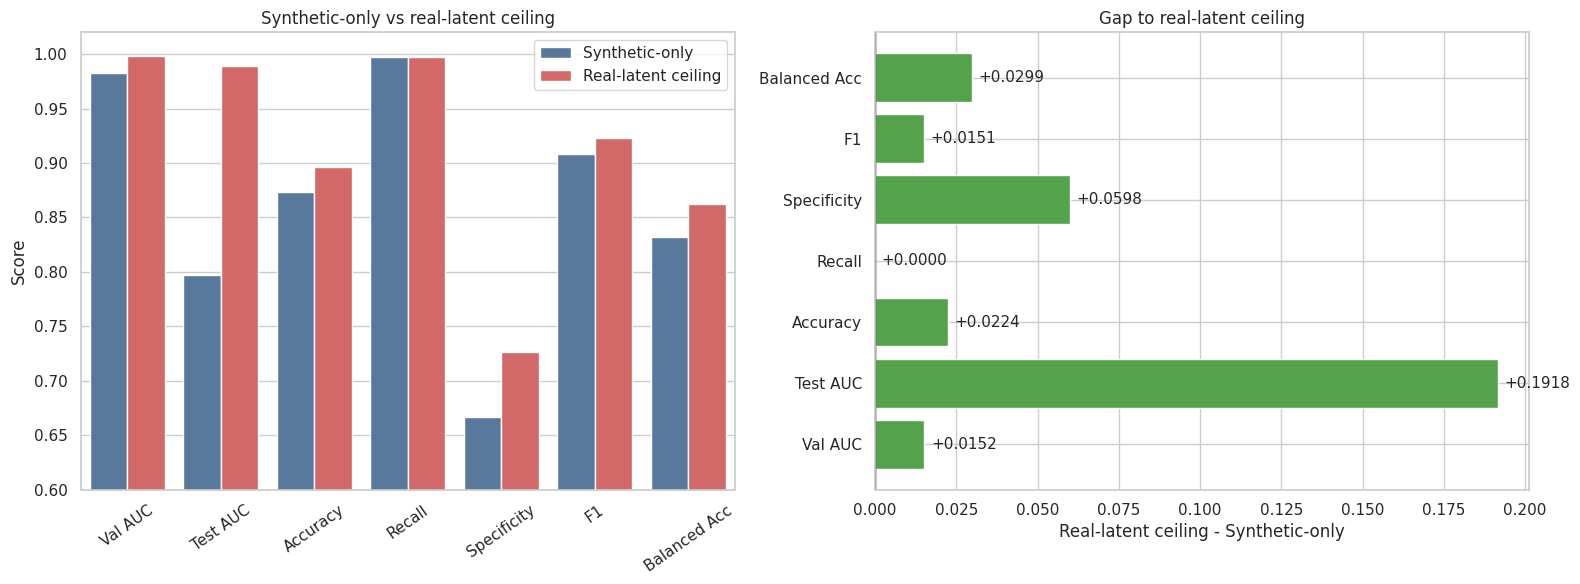

Largest gap: Test AUC = +0.1918


In [37]:
# Cell 25: Plot synthetic vs real-latent ceiling comparison

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

if "multimodal_comparison_df" not in globals():
    raise NameError("Missing multimodal_comparison_df from Cell 24.")

sns.set_theme(style="whitegrid")

plot_metrics = ["Val AUC", "Test AUC", "Accuracy", "Recall", "Specificity", "F1", "Balanced Acc"]
multimodal_plot_df = multimodal_comparison_df[
    multimodal_comparison_df["Metric"].isin(plot_metrics)
].copy()

multimodal_melted = multimodal_plot_df.melt(
    id_vars="Metric",
    value_vars=["Synthetic-only", "Real-latent ceiling"],
    var_name="Setting",
    value_name="Score",
)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.barplot(
    data=multimodal_melted,
    x="Metric",
    y="Score",
    hue="Setting",
    palette=["#4C78A8", "#E45756"],
    ax=axes[0],
)
axes[0].set_title("Synthetic-only vs real-latent ceiling")
axes[0].set_xlabel("")
axes[0].set_ylabel("Score")
axes[0].set_ylim(0.60, 1.02)
axes[0].tick_params(axis="x", rotation=35)
axes[0].legend(title="")

gap_colors = [
    "#54A24B" if gap >= 0 else "#E45756"
    for gap in multimodal_plot_df["Gap (real - synthetic)"]
]
axes[1].barh(
    multimodal_plot_df["Metric"],
    multimodal_plot_df["Gap (real - synthetic)"],
    color=gap_colors,
)
axes[1].axvline(0.0, color="black", linewidth=1)
axes[1].set_title("Gap to real-latent ceiling")
axes[1].set_xlabel("Real-latent ceiling - Synthetic-only")
axes[1].set_ylabel("")

for idx, value in enumerate(multimodal_plot_df["Gap (real - synthetic)"]):
    x_text = value + 0.002 if value >= 0 else value - 0.002
    ha = "left" if value >= 0 else "right"
    axes[1].text(x_text, idx, f"{value:+.4f}", va="center", ha=ha, fontsize=11)

plt.tight_layout()
plt.show()

largest_gap_row = multimodal_plot_df.loc[
    multimodal_plot_df["Gap (real - synthetic)"].astype(float).idxmax()
]
print(
    f"Largest gap: {largest_gap_row['Metric']} = "
    f"{largest_gap_row['Gap (real - synthetic)']:+.4f}"
)

In [38]:
# Cell 26: Final multimodal verdict and next-step priorities

import numpy as np

if "multimodal_synthetic_summary" not in globals():
    raise NameError("Missing multimodal_synthetic_summary.")
if "multimodal_real_baseline_summary" not in globals():
    raise NameError("Missing multimodal_real_baseline_summary.")

val_auc_gap = float(
    multimodal_real_baseline_summary["val_auc"] - multimodal_synthetic_summary["val_auc"]
)
test_auc_gap = float(
    multimodal_real_baseline_summary["test_auc"] - multimodal_synthetic_summary["test_auc"]
)
accuracy_gap = float(
    multimodal_real_baseline_summary["test_accuracy"] - multimodal_synthetic_summary["test_accuracy"]
)
precision_gap = float(
    multimodal_real_baseline_summary["test_precision"] - multimodal_synthetic_summary["test_precision"]
)
recall_gap = float(
    multimodal_real_baseline_summary["test_recall"] - multimodal_synthetic_summary["test_recall"]
)
specificity_gap = float(
    multimodal_real_baseline_summary["test_specificity"] - multimodal_synthetic_summary["test_specificity"]
)
f1_gap = float(
    multimodal_real_baseline_summary["test_f1"] - multimodal_synthetic_summary["test_f1"]
)
bal_acc_gap = float(
    multimodal_real_baseline_summary["test_bal_acc"] - multimodal_synthetic_summary["test_bal_acc"]
)

gap_items = {
    "val_auc_gap": val_auc_gap,
    "test_auc_gap": test_auc_gap,
    "accuracy_gap": accuracy_gap,
    "precision_gap": precision_gap,
    "recall_gap": recall_gap,
    "specificity_gap": specificity_gap,
    "f1_gap": f1_gap,
    "balanced_accuracy_gap": bal_acc_gap,
}
largest_gap_name = max(gap_items, key=lambda key: gap_items[key])
largest_gap_value = float(gap_items[largest_gap_name])

if test_auc_gap >= 0.10:
    overall_status = "synthetic branch far below ceiling"
    verdict = (
        "The multimodal privacy-preserving pipeline is methodologically valid, "
        "but synthetic latent quality is still the dominant bottleneck."
    )
elif test_auc_gap >= 0.03:
    overall_status = "synthetic branch moderately below ceiling"
    verdict = (
        "The multimodal pipeline is working, but there is still meaningful headroom "
        "from improving synthetic latent fidelity."
    )
else:
    overall_status = "synthetic branch near ceiling"
    verdict = (
        "The multimodal pipeline is working and the synthetic branch is already close "
        "to the real-latent ceiling."
    )

if abs(recall_gap) <= 1e-6 and specificity_gap > 0.03:
    bottleneck = (
        "Sensitivity is preserved, but negative-class discrimination is weaker under "
        "synthetic training, producing excess false positives."
    )
elif test_auc_gap > val_auc_gap:
    bottleneck = (
        "The main weakness is test-time generalization: synthetic latents support validation ranking "
        "reasonably well, but they do not preserve unseen class structure strongly enough."
    )
else:
    bottleneck = (
        "The remaining gap is distributed across calibration, separation, and robustness."
    )

priority_actions = [
    "Improve class-conditional latent fidelity so synthetic samples preserve sharper inter-class boundaries.",
    "Reduce synthetic-vs-real distribution mismatch, especially for the negative class where specificity is lagging.",
    "Strengthen generation-time structure with better conditional control, harder validation diagnostics, or more informative latent regularization.",
]

multimodal_final_report = {
    "overall_status": overall_status,
    "verdict": verdict,
    "bottleneck": bottleneck,
    "largest_gap_name": largest_gap_name,
    "largest_gap_value": largest_gap_value,
    "synthetic_summary": dict(multimodal_synthetic_summary),
    "real_latent_ceiling_summary": dict(multimodal_real_baseline_summary),
    "gaps": gap_items,
    "priority_actions": priority_actions,
}

print("Final multimodal verdict")
print(f"Status               : {multimodal_final_report['overall_status']}")
print(f"Verdict              : {multimodal_final_report['verdict']}")
print(f"Bottleneck           : {multimodal_final_report['bottleneck']}")
print(
    f"Largest gap          : {multimodal_final_report['largest_gap_name']} "
    f"= {multimodal_final_report['largest_gap_value']:+.4f}"
)

print("\nKey gaps")
print(f"  Validation AUC     : {val_auc_gap:+.4f}")
print(f"  Test AUC           : {test_auc_gap:+.4f}")
print(f"  Accuracy           : {accuracy_gap:+.4f}")
print(f"  Precision          : {precision_gap:+.4f}")
print(f"  Recall             : {recall_gap:+.4f}")
print(f"  Specificity        : {specificity_gap:+.4f}")
print(f"  F1                 : {f1_gap:+.4f}")
print(f"  Balanced accuracy  : {bal_acc_gap:+.4f}")

print("\nPriority next steps")
for idx, action in enumerate(multimodal_final_report["priority_actions"], start=1):
    print(f"  {idx}. {action}")

Final multimodal verdict
Status               : synthetic branch far below ceiling
Verdict              : The multimodal privacy-preserving pipeline is methodologically valid, but synthetic latent quality is still the dominant bottleneck.
Bottleneck           : Sensitivity is preserved, but negative-class discrimination is weaker under synthetic training, producing excess false positives.
Largest gap          : test_auc_gap = +0.1918

Key gaps
  Validation AUC     : +0.0152
  Test AUC           : +0.1918
  Accuracy           : +0.0224
  Precision          : +0.0257
  Recall             : +0.0000
  Specificity        : +0.0598
  F1                 : +0.0151
  Balanced accuracy  : +0.0299

Priority next steps
  1. Improve class-conditional latent fidelity so synthetic samples preserve sharper inter-class boundaries.
  2. Reduce synthetic-vs-real distribution mismatch, especially for the negative class where specificity is lagging.
  3. Strengthen generation-time structure with better con

In [39]:
# Cell 27: Final concise verdict block

if "multimodal_synthetic_summary" not in globals():
    raise NameError("Missing multimodal_synthetic_summary.")
if "multimodal_real_baseline_summary" not in globals():
    raise NameError("Missing multimodal_real_baseline_summary.")

test_auc_gap = float(
    multimodal_real_baseline_summary["test_auc"] - multimodal_synthetic_summary["test_auc"]
)
specificity_gap = float(
    multimodal_real_baseline_summary["test_specificity"] - multimodal_synthetic_summary["test_specificity"]
)
recall_gap = float(
    multimodal_real_baseline_summary["test_recall"] - multimodal_synthetic_summary["test_recall"]
)

if test_auc_gap >= 0.10:
    headline = "Synthetic branch remains clearly below the real-latent ceiling."
elif test_auc_gap >= 0.03:
    headline = "Synthetic branch is functional but still meaningfully below the ceiling."
else:
    headline = "Synthetic branch is close to the real-latent ceiling."

if abs(recall_gap) <= 1e-6 and specificity_gap > 0.03:
    bottleneck_line = (
        "Recall is preserved, but weaker specificity shows the main failure is excess false positives."
    )
else:
    bottleneck_line = (
        "The remaining gap is mainly due to weaker class separation and reduced generalization."
    )

multimodal_concise_verdict = {
    "headline": headline,
    "synthetic_test_auc": float(multimodal_synthetic_summary["test_auc"]),
    "real_latent_test_auc": float(multimodal_real_baseline_summary["test_auc"]),
    "test_auc_gap": test_auc_gap,
    "synthetic_bal_acc": float(multimodal_synthetic_summary["test_bal_acc"]),
    "real_latent_bal_acc": float(multimodal_real_baseline_summary["test_bal_acc"]),
    "specificity_gap": specificity_gap,
    "bottleneck": bottleneck_line,
}

print("Multimodal Final Verdict")
print(multimodal_concise_verdict["headline"])
print(
    f"Synthetic test AUC: {multimodal_concise_verdict['synthetic_test_auc']:.4f} | "
    f"Real-latent ceiling test AUC: {multimodal_concise_verdict['real_latent_test_auc']:.4f} | "
    f"Gap: {multimodal_concise_verdict['test_auc_gap']:+.4f}"
)
print(
    f"Synthetic balanced accuracy: {multimodal_concise_verdict['synthetic_bal_acc']:.4f} | "
    f"Real-latent ceiling balanced accuracy: {multimodal_concise_verdict['real_latent_bal_acc']:.4f}"
)
print(
    f"Specificity gap: {multimodal_concise_verdict['specificity_gap']:+.4f}"
)
print(multimodal_concise_verdict["bottleneck"])

Multimodal Final Verdict
Synthetic branch remains clearly below the real-latent ceiling.
Synthetic test AUC: 0.7969 | Real-latent ceiling test AUC: 0.9887 | Gap: +0.1918
Synthetic balanced accuracy: 0.8321 | Real-latent ceiling balanced accuracy: 0.8620
Specificity gap: +0.0598
Recall is preserved, but weaker specificity shows the main failure is excess false positives.


In [44]:
# Next cell: Audit the false-positive bottleneck with classifier auto-discovery

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn

from IPython.display import display
from sklearn.metrics import roc_auc_score
from tqdm.auto import tqdm

sns.set_theme(style="whitegrid")

if "multimodal_synthetic_summary" not in globals():
    raise NameError("Missing multimodal_synthetic_summary.")
if "multimodal_real_baseline_summary" not in globals():
    raise NameError("Missing multimodal_real_baseline_summary.")
if "multimodal_test_latents" not in globals():
    raise NameError("Missing multimodal_test_latents.")
if "multimodal_test_labels" not in globals():
    raise NameError("Missing multimodal_test_labels.")

test_latents = multimodal_test_latents
test_labels = np.asarray(multimodal_test_labels).astype(np.int64).reshape(-1)

synthetic_target_auc = float(multimodal_synthetic_summary["test_auc"])
real_target_auc = float(multimodal_real_baseline_summary["test_auc"])
synthetic_threshold = float(multimodal_synthetic_summary["threshold"])
real_threshold = float(multimodal_real_baseline_summary["threshold"])


def _to_tensor(x):
    if torch.is_tensor(x):
        return x.detach().float().cpu()
    return torch.as_tensor(x, dtype=torch.float32)


def _safe_auc(y_true, probs):
    try:
        return float(roc_auc_score(y_true, probs))
    except Exception:
        return float("nan")


def _output_to_probs(output):
    if isinstance(output, dict):
        for key in ["probs", "probabilities", "logits", "output", "outputs", "pred", "preds"]:
            if key in output:
                return _output_to_probs(output[key])
        raise TypeError("Dict output did not contain a logits/probs-like key.")

    if isinstance(output, (list, tuple)):
        for item in output:
            try:
                return _output_to_probs(item)
            except Exception:
                pass
        raise TypeError("Tuple/list output did not contain a usable logits/probs tensor.")

    if not torch.is_tensor(output):
        raise TypeError(f"Unsupported model output type: {type(output)}")

    values = output.detach().float()

    if values.ndim == 0:
        values = values.view(1)

    if values.ndim == 1:
        if torch.isfinite(values).all() and torch.all((values >= 0.0) & (values <= 1.0)):
            return values
        return torch.sigmoid(values)

    if values.ndim == 2 and values.shape[1] == 1:
        values = values[:, 0]
        if torch.isfinite(values).all() and torch.all((values >= 0.0) & (values <= 1.0)):
            return values
        return torch.sigmoid(values)

    if values.ndim == 2 and values.shape[1] >= 2:
        if torch.isfinite(values).all() and torch.all((values >= 0.0) & (values <= 1.0)):
            row_sums = values.sum(dim=1)
            if torch.allclose(row_sums, torch.ones_like(row_sums), atol=1e-3, rtol=1e-3):
                return values[:, 1]
        return torch.softmax(values, dim=1)[:, 1]

    raise ValueError(f"Unsupported output shape: {tuple(values.shape)}")


@torch.no_grad()
def _predict_probs(model, latents, batch_size=1024, desc="Predicting", use_tqdm=True):
    latents_tensor = _to_tensor(latents)

    try:
        model_device = next(model.parameters()).device
    except StopIteration:
        model_device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    was_training = model.training
    model.eval()

    iterator = range(0, len(latents_tensor), batch_size)
    if use_tqdm:
        iterator = tqdm(iterator, desc=desc, dynamic_ncols=True)

    probs_list = []
    for start in iterator:
        batch = latents_tensor[start:start + batch_size].to(model_device, non_blocking=True)
        output = model(batch)
        probs = _output_to_probs(output)
        probs_list.append(probs.detach().cpu())

    if was_training:
        model.train()

    return torch.cat(probs_list).numpy().astype(np.float32)


def _candidate_priority(name, role):
    lname = name.lower()
    score = 0

    if "multimodal" in lname:
        score += 6
    if "classifier" in lname:
        score += 5
    if "model" in lname:
        score += 1
    if "mlp" in lname:
        score += 2

    if role == "synthetic":
        if "synthetic" in lname or "syn" in lname:
            score += 7
        if "real" in lname or "baseline" in lname:
            score -= 7
    else:
        if "real" in lname or "baseline" in lname:
            score += 7
        if "synthetic" in lname or "syn" in lname:
            score -= 7

    return score


def _collect_module_candidates(role):
    excluded_tokens = [
        "denoiser",
        "extractor",
        "backbone",
        "encoder",
        "decoder",
        "diffusion",
        "ema",
        "feature_extractor",
    ]

    preferred = {
        "synthetic": [
            "multimodal_synthetic_classifier",
            "multimodal_classifier",
            "synthetic_classifier",
            "classifier",
        ],
        "real": [
            "multimodal_real_classifier",
            "real_classifier",
            "baseline_model",
            "multimodal_baseline_model",
        ],
    }[role]

    names = []
    for name in preferred:
        if name in globals() and isinstance(globals()[name], nn.Module):
            names.append(name)

    scanned = []
    for name, obj in globals().items():
        if name in names:
            continue
        if not isinstance(obj, nn.Module):
            continue

        lname = name.lower()
        if any(token in lname for token in excluded_tokens):
            continue

        scanned.append(name)

    scanned = sorted(
        scanned,
        key=lambda name: (_candidate_priority(name, role), name.lower()),
        reverse=True,
    )

    ordered = names + scanned
    deduped = []
    seen = set()
    for name in ordered:
        if name not in seen:
            deduped.append(name)
            seen.add(name)

    return deduped[:10]


def _discover_model_probs(role, target_auc):
    cached_prob_names = {
        "synthetic": ["multimodal_synthetic_test_probs", "multimodal_test_probs_synthetic"],
        "real": ["multimodal_real_test_probs"],
    }[role]

    for name in cached_prob_names:
        if name in globals():
            cached = np.asarray(globals()[name]).reshape(-1).astype(np.float32)
            if len(cached) == len(test_labels):
                return {
                    "source": name,
                    "probs": cached,
                    "auc": _safe_auc(test_labels, cached),
                    "discovery_df": None,
                }

    candidates = _collect_module_candidates(role)
    if not candidates:
        raise NameError(f"No candidate torch modules found for {role} classifier discovery.")

    probe_latents = _to_tensor(test_latents[: min(8, len(test_labels))])
    results = []

    for name in candidates:
        model = globals()[name]
        try:
            _ = _predict_probs(
                model=model,
                latents=probe_latents,
                batch_size=len(probe_latents),
                desc=f"Probe {name}",
                use_tqdm=False,
            )
        except Exception as exc:
            results.append({
                "candidate": name,
                "auc": np.nan,
                "delta_to_target_auc": np.inf,
                "status": f"probe failed: {type(exc).__name__}",
            })
            continue

        try:
            probs = _predict_probs(
                model=model,
                latents=test_latents,
                batch_size=1024,
                desc=f"{role.title()} candidate: {name}",
                use_tqdm=True,
            )
            auc = _safe_auc(test_labels, probs)
            delta = abs(auc - target_auc) if np.isfinite(auc) else np.inf
            results.append({
                "candidate": name,
                "auc": auc,
                "delta_to_target_auc": delta,
                "status": "ok",
                "probs": probs,
            })
        except Exception as exc:
            results.append({
                "candidate": name,
                "auc": np.nan,
                "delta_to_target_auc": np.inf,
                "status": f"full pass failed: {type(exc).__name__}",
            })

    valid = [row for row in results if row["status"] == "ok"]
    if not valid:
        discovery_df = pd.DataFrame(results)
        print(f"\n{role.title()} discovery attempts")
        print(discovery_df.to_string(index=False))
        raise NameError(f"Could not discover a usable {role} classifier from notebook state.")

    best = min(valid, key=lambda row: row["delta_to_target_auc"])
    discovery_df = pd.DataFrame([
        {
            "candidate": row["candidate"],
            "auc": row["auc"],
            "delta_to_target_auc": row["delta_to_target_auc"],
            "status": row["status"],
        }
        for row in results
    ]).sort_values(["status", "delta_to_target_auc", "candidate"], ascending=[False, True, True])

    return {
        "source": best["candidate"],
        "probs": best["probs"],
        "auc": best["auc"],
        "discovery_df": discovery_df,
    }


synthetic_discovery = _discover_model_probs(role="synthetic", target_auc=synthetic_target_auc)
real_discovery = _discover_model_probs(role="real", target_auc=real_target_auc)

synthetic_probs = synthetic_discovery["probs"]
real_probs = real_discovery["probs"]

neg_mask = (test_labels == 0)
pos_mask = (test_labels == 1)

assert neg_mask.any(), "No negative samples found in multimodal_test_labels."
assert pos_mask.any(), "No positive samples found in multimodal_test_labels."

synthetic_neg = synthetic_probs[neg_mask]
real_neg = real_probs[neg_mask]
synthetic_pos = synthetic_probs[pos_mask]
real_pos = real_probs[pos_mask]

synthetic_fpr = float((synthetic_neg >= synthetic_threshold).mean())
real_fpr = float((real_neg >= real_threshold).mean())
fpr_gap = synthetic_fpr - real_fpr

synthetic_recall = float((synthetic_pos >= synthetic_threshold).mean())
real_recall = float((real_pos >= real_threshold).mean())

if real_fpr <= 0.0:
    fpr_matched_threshold = float(np.max(synthetic_neg) + 1e-6)
elif real_fpr >= 1.0:
    fpr_matched_threshold = float(np.min(synthetic_neg) - 1e-6)
else:
    fpr_matched_threshold = float(np.quantile(synthetic_neg, 1.0 - real_fpr))

synthetic_recall_at_real_fpr = float((synthetic_pos >= fpr_matched_threshold).mean())
recall_drop_to_match_fpr = synthetic_recall - synthetic_recall_at_real_fpr

neg_indices = np.where(neg_mask)[0]
negative_audit_df = pd.DataFrame({
    "test_index": neg_indices,
    "synthetic_prob": synthetic_neg,
    "real_prob": real_neg,
})
negative_audit_df["synthetic_fp"] = negative_audit_df["synthetic_prob"] >= synthetic_threshold
negative_audit_df["real_fp"] = negative_audit_df["real_prob"] >= real_threshold
negative_audit_df["fixed_by_real"] = negative_audit_df["synthetic_fp"] & (~negative_audit_df["real_fp"])
negative_audit_df["score_gap"] = negative_audit_df["synthetic_prob"] - negative_audit_df["real_prob"]

hard_negatives = negative_audit_df.sort_values(
    ["synthetic_fp", "score_gap", "synthetic_prob"],
    ascending=[False, False, False],
).head(15)

quantile_df = pd.DataFrame({
    "quantile": ["p50", "p75", "p90", "p95", "p99"],
    "synthetic_negative_prob": np.quantile(synthetic_neg, [0.50, 0.75, 0.90, 0.95, 0.99]),
    "real_negative_prob": np.quantile(real_neg, [0.50, 0.75, 0.90, 0.95, 0.99]),
})

print("Chosen classifier candidates")
print(
    f"  Synthetic candidate : {synthetic_discovery['source']} | "
    f"discovered test AUC={synthetic_discovery['auc']:.4f} | "
    f"target summary AUC={synthetic_target_auc:.4f}"
)
print(
    f"  Real candidate      : {real_discovery['source']} | "
    f"discovered test AUC={real_discovery['auc']:.4f} | "
    f"target summary AUC={real_target_auc:.4f}"
)

print("\nFalse-positive audit on true negatives")
print(f"  True negatives                    : {neg_mask.sum()}")
print(f"  Synthetic FPR                     : {synthetic_fpr:.4f}")
print(f"  Real-latent FPR                   : {real_fpr:.4f}")
print(f"  Excess synthetic FPR              : {fpr_gap:+.4f}")
print(f"  Synthetic recall @ current thr    : {synthetic_recall:.4f}")
print(f"  Real-latent recall @ current thr  : {real_recall:.4f}")
print(f"  Synthetic thr to match real FPR   : {fpr_matched_threshold:.4f}")
print(f"  Synthetic recall @ matched FPR    : {synthetic_recall_at_real_fpr:.4f}")
print(f"  Recall drop to match real FPR     : {recall_drop_to_match_fpr:+.4f}")
print(f"  Synthetic false positives fixed by real model: {int(negative_audit_df['fixed_by_real'].sum())}")

print("\nNegative-score quantiles")
print(quantile_df.to_string(index=False, float_format=lambda x: f"{x:.4f}"))

if recall_drop_to_match_fpr > 0.03:
    print("\nInterpretation")
    print("  Matching the real-latent false-positive rate would noticeably hurt synthetic recall.")
    print("  That points to a latent/class-structure problem, not just threshold calibration.")
else:
    print("\nInterpretation")
    print("  A threshold shift can recover much of the specificity gap with limited recall loss.")
    print("  That points more toward calibration than synthetic latent structure.")

if synthetic_discovery["discovery_df"] is not None:
    display(
        synthetic_discovery["discovery_df"]
        .head(8)
        .style
        .hide(axis="index")
        .format({
            "auc": "{:.4f}",
            "delta_to_target_auc": "{:.4f}",
        })
    )

if real_discovery["discovery_df"] is not None:
    display(
        real_discovery["discovery_df"]
        .head(8)
        .style
        .hide(axis="index")
        .format({
            "auc": "{:.4f}",
            "delta_to_target_auc": "{:.4f}",
        })
    )

display(
    hard_negatives.style.hide(axis="index").format({
        "synthetic_prob": "{:.4f}",
        "real_prob": "{:.4f}",
        "score_gap": "{:+.4f}",
    })
)

Synthetic candidate: multimodal_latent_classifier:   0%|          | 0/1 [00:00<?, ?it/s]

Synthetic candidate: multimodal_real_classifier:   0%|          | 0/1 [00:00<?, ?it/s]

Chosen classifier candidates
  Synthetic candidate : multimodal_latent_classifier | discovered test AUC=0.7969 | target summary AUC=0.7969
  Real candidate      : multimodal_real_test_probs | discovered test AUC=0.9887 | target summary AUC=0.9887

False-positive audit on true negatives
  True negatives                    : 234
  Synthetic FPR                     : 0.3333
  Real-latent FPR                   : 0.2735
  Excess synthetic FPR              : +0.0598
  Synthetic recall @ current thr    : 0.9974
  Real-latent recall @ current thr  : 0.9974
  Synthetic thr to match real FPR   : 0.8284
  Synthetic recall @ matched FPR    : 0.9923
  Recall drop to match real FPR     : +0.0051
  Synthetic false positives fixed by real model: 18

Negative-score quantiles
quantile  synthetic_negative_prob  real_negative_prob
     p50                   0.2549              0.0858
     p75                   0.8309              0.5827
     p90                   0.8459              0.9993
     p95       

candidate,auc,delta_to_target_auc,status
criterion,nan,inf,probe failed: TypeError
multimodal_cls_criterion,nan,inf,probe failed: TypeError
multimodal_real_criterion,nan,inf,probe failed: TypeError
global_multimodal_model,nan,inf,probe failed: RuntimeError
local_model,nan,inf,probe failed: RuntimeError
multimodal_feature_model,nan,inf,probe failed: RuntimeError
multimodal_model,nan,inf,probe failed: RuntimeError
multimodal_latent_classifier,0.7969,0.0000,ok


test_index,synthetic_prob,real_prob,synthetic_fp,real_fp,fixed_by_real,score_gap
169,0.8283,0.0825,True,False,True,+0.7458
55,0.8035,0.0985,True,False,True,+0.7050
514,0.7696,0.0677,True,False,True,+0.7019
233,0.8362,0.1428,True,False,True,+0.6934
108,0.8376,0.1494,True,False,True,+0.6882
165,0.7638,0.0819,True,False,True,+0.6819
234,0.8126,0.1406,True,False,True,+0.6720
247,0.7898,0.1245,True,False,True,+0.6653
95,0.8394,0.1970,True,False,True,+0.6423
394,0.7447,0.1069,True,False,True,+0.6378


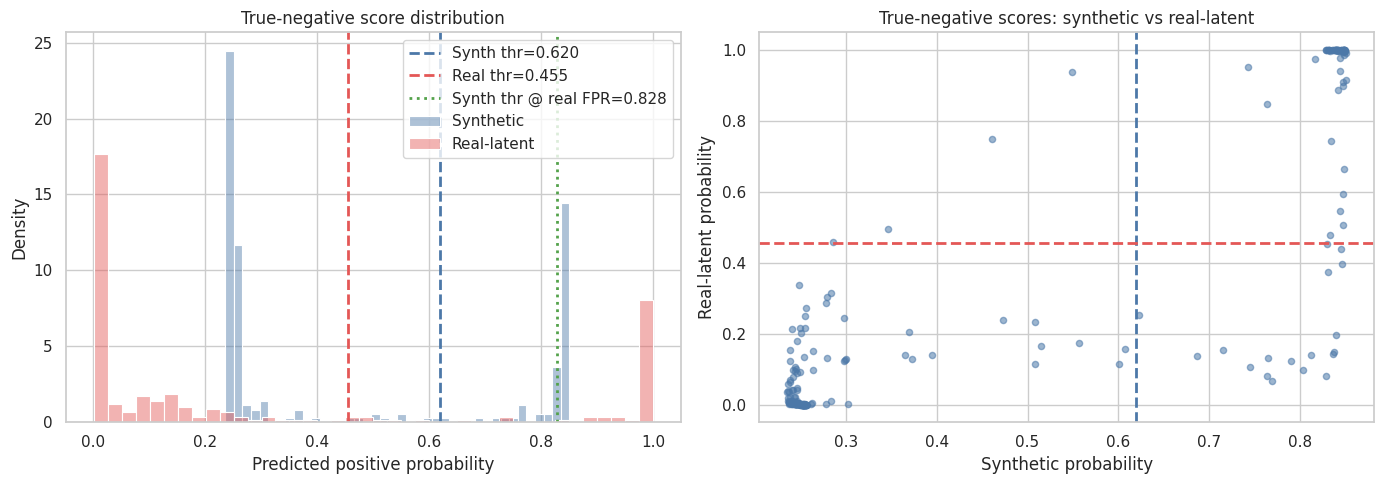

In [45]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(
    synthetic_neg,
    bins=40,
    stat="density",
    color="#4C78A8",
    alpha=0.45,
    label="Synthetic",
    ax=axes[0],
)
sns.histplot(
    real_neg,
    bins=40,
    stat="density",
    color="#E45756",
    alpha=0.45,
    label="Real-latent",
    ax=axes[0],
)
axes[0].axvline(
    synthetic_threshold,
    color="#4C78A8",
    linestyle="--",
    linewidth=2,
    label=f"Synth thr={synthetic_threshold:.3f}",
)
axes[0].axvline(
    real_threshold,
    color="#E45756",
    linestyle="--",
    linewidth=2,
    label=f"Real thr={real_threshold:.3f}",
)
axes[0].axvline(
    fpr_matched_threshold,
    color="#54A24B",
    linestyle=":",
    linewidth=2,
    label=f"Synth thr @ real FPR={fpr_matched_threshold:.3f}",
)
axes[0].set_title("True-negative score distribution")
axes[0].set_xlabel("Predicted positive probability")
axes[0].set_ylabel("Density")
axes[0].legend()

axes[1].scatter(
    synthetic_neg,
    real_neg,
    s=20,
    alpha=0.55,
    color="#4C78A8",
)
axes[1].axvline(synthetic_threshold, color="#4C78A8", linestyle="--", linewidth=2)
axes[1].axhline(real_threshold, color="#E45756", linestyle="--", linewidth=2)
axes[1].set_title("True-negative scores: synthetic vs real-latent")
axes[1].set_xlabel("Synthetic probability")
axes[1].set_ylabel("Real-latent probability")

plt.tight_layout()
plt.show()

In [50]:
# Next cell: Apply the audit-derived calibrated threshold on the real test split

import numpy as np
import pandas as pd
import torch

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)


def _to_numpy_1d(value):
    if torch.is_tensor(value):
        value = value.detach().cpu().numpy()
    arr = np.asarray(value)
    if arr.ndim == 0:
        arr = arr.reshape(1)
    return arr.reshape(-1)


def _extract_probs(output):
    if isinstance(output, dict):
        for key in ["probs", "probabilities", "logits", "output", "outputs", "pred", "preds"]:
            if key in output:
                return _extract_probs(output[key])
        raise TypeError("Dict output did not contain a usable logits/probs key.")

    if isinstance(output, (list, tuple)):
        for item in output:
            try:
                return _extract_probs(item)
            except Exception:
                pass
        raise TypeError("Tuple/list output did not contain a usable logits/probs tensor.")

    if not torch.is_tensor(output):
        raise TypeError(f"Unsupported model output type: {type(output)}")

    values = output.detach().float()

    if values.ndim == 1:
        if torch.all((values >= 0.0) & (values <= 1.0)):
            return values
        return torch.sigmoid(values)

    if values.ndim == 2 and values.shape[1] == 1:
        values = values[:, 0]
        if torch.all((values >= 0.0) & (values <= 1.0)):
            return values
        return torch.sigmoid(values)

    if values.ndim == 2 and values.shape[1] >= 2:
        if torch.all((values >= 0.0) & (values <= 1.0)):
            row_sums = values.sum(dim=1)
            if torch.allclose(row_sums, torch.ones_like(row_sums), atol=1e-3, rtol=1e-3):
                return values[:, 1]
        return torch.softmax(values, dim=1)[:, 1]

    raise ValueError(f"Unsupported output shape: {tuple(values.shape)}")


@torch.no_grad()
def _predict_probs(model, latents, batch_size=1024):
    if torch.is_tensor(latents):
        latents_tensor = latents.detach().float().cpu()
    else:
        latents_tensor = torch.as_tensor(latents, dtype=torch.float32)

    try:
        model_device = next(model.parameters()).device
    except StopIteration:
        model_device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    was_training = model.training
    model.eval()

    probs_list = []
    for start in range(0, len(latents_tensor), batch_size):
        batch = latents_tensor[start:start + batch_size].to(model_device, non_blocking=True)
        probs = _extract_probs(model(batch))
        probs_list.append(probs.detach().cpu())

    if was_training:
        model.train()

    return torch.cat(probs_list).numpy().astype(np.float32)


def _compute_metrics(y_true, probs, threshold):
    preds = (probs >= threshold).astype(int)

    acc = accuracy_score(y_true, preds)
    auc = roc_auc_score(y_true, probs)
    precision = precision_score(y_true, preds, zero_division=0)
    recall = recall_score(y_true, preds, zero_division=0)
    f1 = f1_score(y_true, preds, zero_division=0)

    tn, fp, fn, tp = confusion_matrix(y_true, preds, labels=[0, 1]).ravel()
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0
    bal_acc = 0.5 * (recall + specificity)
    fpr = fp / (fp + tn) if (fp + tn) > 0 else 0.0

    return {
        "threshold": float(threshold),
        "accuracy": float(acc),
        "auc": float(auc),
        "precision": float(precision),
        "recall": float(recall),
        "specificity": float(specificity),
        "f1": float(f1),
        "balanced_accuracy": float(bal_acc),
        "fpr": float(fpr),
        "tn": int(tn),
        "fp": int(fp),
        "fn": int(fn),
        "tp": int(tp),
    }


if "multimodal_synthetic_summary" not in globals():
    raise NameError("Missing multimodal_synthetic_summary.")
if "multimodal_test_latents" not in globals():
    raise NameError("Missing multimodal_test_latents.")
if "multimodal_test_labels" not in globals():
    raise NameError("Missing multimodal_test_labels.")
if "fpr_matched_threshold" not in globals():
    raise NameError("Missing fpr_matched_threshold from the successful false-positive audit.")

if "synthetic_probs" in globals():
    synthetic_test_probs = _to_numpy_1d(synthetic_probs).astype(np.float32)
    synthetic_prob_source = "synthetic_probs"
else:
    if "multimodal_latent_classifier" not in globals():
        raise NameError("Missing multimodal_latent_classifier and no cached synthetic_probs found.")
    synthetic_test_probs = _predict_probs(
        multimodal_latent_classifier,
        multimodal_test_latents,
        batch_size=1024,
    )
    synthetic_prob_source = "predicted via multimodal_latent_classifier"

y_true = _to_numpy_1d(multimodal_test_labels).astype(np.int64)

old_threshold = float(multimodal_synthetic_summary["threshold"])
calibrated_threshold = float(fpr_matched_threshold)

original_metrics = _compute_metrics(y_true, synthetic_test_probs, old_threshold)
calibrated_metrics = _compute_metrics(y_true, synthetic_test_probs, calibrated_threshold)

multimodal_synthetic_threshold_probe = {
    "prob_source": synthetic_prob_source,
    "original_metrics": original_metrics,
    "calibrated_metrics": calibrated_metrics,
    "specificity_change": float(
        calibrated_metrics["specificity"] - original_metrics["specificity"]
    ),
    "recall_change": float(
        calibrated_metrics["recall"] - original_metrics["recall"]
    ),
    "precision_change": float(
        calibrated_metrics["precision"] - original_metrics["precision"]
    ),
    "balanced_accuracy_change": float(
        calibrated_metrics["balanced_accuracy"] - original_metrics["balanced_accuracy"]
    ),
}

comparison_df = pd.DataFrame([
    {
        "setting": "original_synthetic_threshold",
        "threshold": original_metrics["threshold"],
        "accuracy": original_metrics["accuracy"],
        "auc": original_metrics["auc"],
        "precision": original_metrics["precision"],
        "recall": original_metrics["recall"],
        "specificity": original_metrics["specificity"],
        "f1": original_metrics["f1"],
        "balanced_accuracy": original_metrics["balanced_accuracy"],
        "fpr": original_metrics["fpr"],
    },
    {
        "setting": "audit_calibrated_threshold",
        "threshold": calibrated_metrics["threshold"],
        "accuracy": calibrated_metrics["accuracy"],
        "auc": calibrated_metrics["auc"],
        "precision": calibrated_metrics["precision"],
        "recall": calibrated_metrics["recall"],
        "specificity": calibrated_metrics["specificity"],
        "f1": calibrated_metrics["f1"],
        "balanced_accuracy": calibrated_metrics["balanced_accuracy"],
        "fpr": calibrated_metrics["fpr"],
    },
])

print("Synthetic threshold probe on held-out real test split")
print(f"Probability source    : {synthetic_prob_source}")
print(f"Original threshold    : {old_threshold:.4f}")
print(f"Calibrated threshold  : {calibrated_threshold:.4f}")
print()
print(comparison_df.to_string(index=False, float_format=lambda x: f"{x:.4f}"))
print()
print(f"Specificity change    : {multimodal_synthetic_threshold_probe['specificity_change']:+.4f}")
print(f"Recall change         : {multimodal_synthetic_threshold_probe['recall_change']:+.4f}")
print(f"Precision change      : {multimodal_synthetic_threshold_probe['precision_change']:+.4f}")
print(f"Balanced acc change   : {multimodal_synthetic_threshold_probe['balanced_accuracy_change']:+.4f}")

if (
    multimodal_synthetic_threshold_probe["specificity_change"] > 0
    and multimodal_synthetic_threshold_probe["recall_change"] >= -0.01
):
    multimodal_synthetic_calibrated_summary = {
        "threshold": calibrated_metrics["threshold"],
        "test_auc": calibrated_metrics["auc"],
        "test_accuracy": calibrated_metrics["accuracy"],
        "test_precision": calibrated_metrics["precision"],
        "test_recall": calibrated_metrics["recall"],
        "test_specificity": calibrated_metrics["specificity"],
        "test_f1": calibrated_metrics["f1"],
        "test_bal_acc": calibrated_metrics["balanced_accuracy"],
        "source": "audit-derived FPR-matched threshold probe",
    }
    print("Calibration probe verdict: threshold tuning alone materially improves the synthetic branch.")
else:
    print("Calibration probe verdict: threshold tuning alone is not sufficient.")

Synthetic threshold probe on held-out real test split
Probability source    : synthetic_probs
Original threshold    : 0.6200
Calibrated threshold  : 0.8284

                     setting  threshold  accuracy    auc  precision  recall  specificity     f1  balanced_accuracy    fpr
original_synthetic_threshold     0.6200    0.8734 0.7969     0.8330  0.9974       0.6667 0.9078             0.8321 0.3333
  audit_calibrated_threshold     0.8284    0.8926 0.7969     0.8581  0.9923       0.7265 0.9203             0.8594 0.2735

Specificity change    : +0.0598
Recall change         : -0.0051
Precision change      : +0.0251
Balanced acc change   : +0.0274
Calibration probe verdict: threshold tuning alone materially improves the synthetic branch.


In [52]:
# Cell title: Calibrated multimodal comparison
# Work done: fold the audit-derived threshold into the final multimodal comparison and quantify the remaining gap to the real-latent ceiling.

import pandas as pd
from IPython.display import display

if "multimodal_synthetic_summary" not in globals():
    raise NameError("Missing multimodal_synthetic_summary.")

if "multimodal_real_baseline_summary" not in globals():
    raise NameError("Missing multimodal_real_baseline_summary.")

if "multimodal_synthetic_calibrated_summary" not in globals():
    raise NameError("Missing multimodal_synthetic_calibrated_summary from the threshold probe.")

original_summary = multimodal_synthetic_summary
calibrated_summary = multimodal_synthetic_calibrated_summary
real_summary = multimodal_real_baseline_summary

comparison_rows = [
    ("Threshold", original_summary["threshold"], calibrated_summary["threshold"], real_summary["threshold"]),
    ("Test AUC", original_summary["test_auc"], calibrated_summary["test_auc"], real_summary["test_auc"]),
    ("Accuracy", original_summary["test_accuracy"], calibrated_summary["test_accuracy"], real_summary["test_accuracy"]),
    ("Precision", original_summary["test_precision"], calibrated_summary["test_precision"], real_summary["test_precision"]),
    ("Recall", original_summary["test_recall"], calibrated_summary["test_recall"], real_summary["test_recall"]),
    ("Specificity", original_summary["test_specificity"], calibrated_summary["test_specificity"], real_summary["test_specificity"]),
    ("F1", original_summary["test_f1"], calibrated_summary["test_f1"], real_summary["test_f1"]),
    ("Balanced Acc", original_summary["test_bal_acc"], calibrated_summary["test_bal_acc"], real_summary["test_bal_acc"]),
]

multimodal_calibrated_comparison_df = pd.DataFrame(
    comparison_rows,
    columns=[
        "Metric",
        "Synthetic original",
        "Synthetic calibrated",
        "Real-latent ceiling",
    ],
)

multimodal_calibrated_comparison_df["Gap to ceiling before"] = (
    multimodal_calibrated_comparison_df["Real-latent ceiling"]
    - multimodal_calibrated_comparison_df["Synthetic original"]
)
multimodal_calibrated_comparison_df["Gap to ceiling after"] = (
    multimodal_calibrated_comparison_df["Real-latent ceiling"]
    - multimodal_calibrated_comparison_df["Synthetic calibrated"]
)
multimodal_calibrated_comparison_df["Gap closed"] = (
    multimodal_calibrated_comparison_df["Gap to ceiling before"]
    - multimodal_calibrated_comparison_df["Gap to ceiling after"]
)

specificity_gap_before = float(
    real_summary["test_specificity"] - original_summary["test_specificity"]
)
specificity_gap_after = float(
    real_summary["test_specificity"] - calibrated_summary["test_specificity"]
)
specificity_gap_closed_ratio = (
    (specificity_gap_before - specificity_gap_after) / specificity_gap_before
    if abs(specificity_gap_before) > 1e-12
    else 0.0
)

bal_acc_gap_before = float(
    real_summary["test_bal_acc"] - original_summary["test_bal_acc"]
)
bal_acc_gap_after = float(
    real_summary["test_bal_acc"] - calibrated_summary["test_bal_acc"]
)

auc_gap_after = float(real_summary["test_auc"] - calibrated_summary["test_auc"])
recall_gap_after = float(real_summary["test_recall"] - calibrated_summary["test_recall"])
precision_gap_after = float(real_summary["test_precision"] - calibrated_summary["test_precision"])

if specificity_gap_closed_ratio >= 0.75 and abs(recall_gap_after) <= 0.01:
    calibration_verdict = "Calibration closes most of the specificity gap with minimal recall cost."
elif specificity_gap_after < specificity_gap_before:
    calibration_verdict = "Calibration helps materially, but a noticeable residual gap remains."
else:
    calibration_verdict = "Calibration does not explain the ceiling gap."

if abs(auc_gap_after) <= 0.02 and abs(bal_acc_gap_after) <= 0.02:
    residual_bottleneck = "After calibration, the synthetic branch is close to the real-latent ceiling."
elif auc_gap_after > 0.02:
    residual_bottleneck = "Ranking quality still trails the real-latent ceiling, so synthesis fidelity is not fully solved."
else:
    residual_bottleneck = "Most remaining difference is small and likely second-order."

multimodal_calibrated_gap_summary = {
    "specificity_gap_before": specificity_gap_before,
    "specificity_gap_after": specificity_gap_after,
    "specificity_gap_closed_ratio": float(specificity_gap_closed_ratio),
    "balanced_accuracy_gap_before": bal_acc_gap_before,
    "balanced_accuracy_gap_after": bal_acc_gap_after,
    "auc_gap_after": auc_gap_after,
    "precision_gap_after": precision_gap_after,
    "recall_gap_after": recall_gap_after,
    "calibration_verdict": calibration_verdict,
    "residual_bottleneck": residual_bottleneck,
}

multimodal_calibrated_final_report = {
    "original_threshold": float(original_summary["threshold"]),
    "calibrated_threshold": float(calibrated_summary["threshold"]),
    "real_threshold": float(real_summary["threshold"]),
    "calibration_verdict": calibration_verdict,
    "residual_bottleneck": residual_bottleneck,
    "post_calibration_auc_gap": auc_gap_after,
    "post_calibration_specificity_gap": specificity_gap_after,
    "post_calibration_bal_acc_gap": bal_acc_gap_after,
}

print("Calibrated multimodal comparison")
print("Audit-derived threshold is now folded into the final held-out comparison.")
print()

display(
    multimodal_calibrated_comparison_df.style
    .hide(axis="index")
    .format({
        "Synthetic original": "{:.4f}",
        "Synthetic calibrated": "{:.4f}",
        "Real-latent ceiling": "{:.4f}",
        "Gap to ceiling before": "{:+.4f}",
        "Gap to ceiling after": "{:+.4f}",
        "Gap closed": "{:+.4f}",
    })
)

print("\nPost-calibration summary")
print(f"Specificity gap before : {specificity_gap_before:+.4f}")
print(f"Specificity gap after  : {specificity_gap_after:+.4f}")
print(f"Specificity gap closed : {specificity_gap_closed_ratio:.1%}")
print(f"Balanced acc gap after : {bal_acc_gap_after:+.4f}")
print(f"AUC gap after          : {auc_gap_after:+.4f}")
print(f"Recall gap after       : {recall_gap_after:+.4f}")
print(f"Precision gap after    : {precision_gap_after:+.4f}")
print()
print(calibration_verdict)
print(residual_bottleneck)

Calibrated multimodal comparison
Audit-derived threshold is now folded into the final held-out comparison.



Metric,Synthetic original,Synthetic calibrated,Real-latent ceiling,Gap to ceiling before,Gap to ceiling after,Gap closed
Threshold,0.6200,0.8284,0.4550,-0.1650,-0.3734,+0.2084
Test AUC,0.7969,0.7969,0.9887,+0.1918,+0.1918,+0.0000
Accuracy,0.8734,0.8926,0.8958,+0.0224,+0.0032,+0.0192
Precision,0.8330,0.8581,0.8587,+0.0257,+0.0006,+0.0251
Recall,0.9974,0.9923,0.9974,+0.0000,+0.0051,-0.0051
Specificity,0.6667,0.7265,0.7265,+0.0598,+0.0000,+0.0598
F1,0.9078,0.9203,0.9229,+0.0151,+0.0026,+0.0125
Balanced Acc,0.8321,0.8594,0.8620,+0.0299,+0.0026,+0.0274



Post-calibration summary
Specificity gap before : +0.0598
Specificity gap after  : +0.0000
Specificity gap closed : 100.0%
Balanced acc gap after : +0.0026
AUC gap after          : +0.1918
Recall gap after       : +0.0051
Precision gap after    : +0.0006

Calibration closes most of the specificity gap with minimal recall cost.
Ranking quality still trails the real-latent ceiling, so synthesis fidelity is not fully solved.


Ranking-gap audit on held-out real test split
Label source         : multimodal_test_labels
Synthetic probs      : synthetic_probs
Real-latent probs    : multimodal_real_test_probs

      model    auc  neg_p50  neg_p75  neg_p90  neg_p95  pos_p05  pos_p10  pos_p25  pos_p50  median_gap  tail_gap_p10_p90  tail_gap_p05_p95  neg_above_pos_median  pos_below_neg_median  advantage_vs_synthetic
  synthetic 0.7969   0.2549   0.8309   0.8459   0.8483   0.8339   0.8349   0.8361   0.8368      0.5819           -0.0110           -0.0144                0.2094                0.0000                  0.0000
real_latent 0.9887   0.0858   0.5827   0.9993   0.9994   0.9993   0.9994   0.9994   0.9994      0.9136            0.0002           -0.0001                0.0000                0.0000                  0.1918

Top hard negatives where synthetic ranks too high
 index  true_label  synthetic_prob  real_prob  synthetic_minus_real
   169           0          0.8283     0.0825                0.7458
    55    

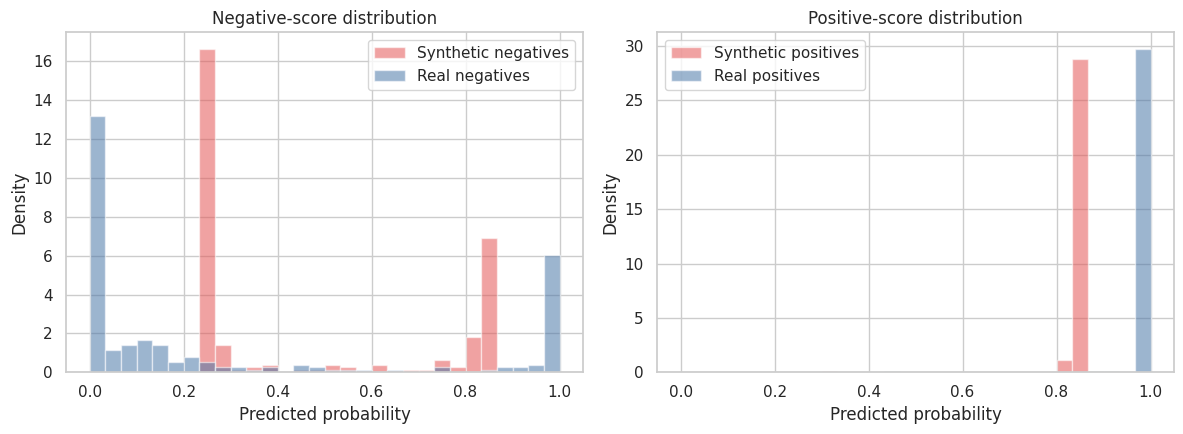

In [53]:
# Cell title: Ranking-gap audit
# Work done: compare synthetic vs real-latent score separation on the held-out test split and surface the worst synthetic ranking misses.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

from sklearn.metrics import roc_auc_score
from tqdm.auto import tqdm


def _to_numpy_1d(value):
    if torch.is_tensor(value):
        value = value.detach().cpu().numpy()
    arr = np.asarray(value)
    if arr.ndim == 0:
        arr = arr.reshape(1)
    return arr.reshape(-1)


def _extract_probs(output):
    if isinstance(output, dict):
        for key in ["probs", "probabilities", "logits", "output", "outputs", "pred", "preds"]:
            if key in output:
                return _extract_probs(output[key])
        raise TypeError("Dict output did not contain a usable logits/probs key.")

    if isinstance(output, (list, tuple)):
        for item in output:
            try:
                return _extract_probs(item)
            except Exception:
                pass
        raise TypeError("Tuple/list output did not contain a usable logits/probs tensor.")

    if not torch.is_tensor(output):
        raise TypeError(f"Unsupported model output type: {type(output)}")

    values = output.detach().float()

    if values.ndim == 1:
        if torch.all((values >= 0.0) & (values <= 1.0)):
            return values
        return torch.sigmoid(values)

    if values.ndim == 2 and values.shape[1] == 1:
        values = values[:, 0]
        if torch.all((values >= 0.0) & (values <= 1.0)):
            return values
        return torch.sigmoid(values)

    if values.ndim == 2 and values.shape[1] >= 2:
        if torch.all((values >= 0.0) & (values <= 1.0)):
            row_sums = values.sum(dim=1)
            if torch.allclose(row_sums, torch.ones_like(row_sums), atol=1e-3, rtol=1e-3):
                return values[:, 1]
        return torch.softmax(values, dim=1)[:, 1]

    raise ValueError(f"Unsupported output shape: {tuple(values.shape)}")


@torch.no_grad()
def _predict_probs(model, latents, batch_size=1024, desc="Predicting probabilities"):
    if torch.is_tensor(latents):
        latents_tensor = latents.detach().float().cpu()
    else:
        latents_tensor = torch.as_tensor(latents, dtype=torch.float32)

    try:
        model_device = next(model.parameters()).device
    except StopIteration:
        model_device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    was_training = model.training
    model.eval()

    chunks = []
    for start in tqdm(range(0, len(latents_tensor), batch_size), desc=desc, dynamic_ncols=True):
        batch = latents_tensor[start:start + batch_size].to(model_device, non_blocking=True)
        probs = _extract_probs(model(batch))
        chunks.append(probs.detach().cpu())

    if was_training:
        model.train()

    return torch.cat(chunks).numpy().astype(np.float32)


def _resolve_first(name_candidates):
    for name in name_candidates:
        if name in globals():
            return globals()[name], name
    raise NameError(f"Could not resolve any of: {name_candidates}")


def _class_summary(name, probs, y_true):
    probs = _to_numpy_1d(probs).astype(np.float32)
    y_true = _to_numpy_1d(y_true).astype(np.int64)

    neg = probs[y_true == 0]
    pos = probs[y_true == 1]

    return {
        "model": name,
        "auc": float(roc_auc_score(y_true, probs)),
        "neg_p50": float(np.quantile(neg, 0.50)),
        "neg_p75": float(np.quantile(neg, 0.75)),
        "neg_p90": float(np.quantile(neg, 0.90)),
        "neg_p95": float(np.quantile(neg, 0.95)),
        "pos_p05": float(np.quantile(pos, 0.05)),
        "pos_p10": float(np.quantile(pos, 0.10)),
        "pos_p25": float(np.quantile(pos, 0.25)),
        "pos_p50": float(np.quantile(pos, 0.50)),
        "median_gap": float(np.quantile(pos, 0.50) - np.quantile(neg, 0.50)),
        "tail_gap_p10_p90": float(np.quantile(pos, 0.10) - np.quantile(neg, 0.90)),
        "tail_gap_p05_p95": float(np.quantile(pos, 0.05) - np.quantile(neg, 0.95)),
        "neg_above_pos_median": float(np.mean(neg >= np.quantile(pos, 0.50))),
        "pos_below_neg_median": float(np.mean(pos <= np.quantile(neg, 0.50))),
    }


y_true, y_true_src = _resolve_first([
    "multimodal_test_labels",
    "y_test_raw",
])

if "synthetic_probs" in globals():
    syn_probs = _to_numpy_1d(synthetic_probs).astype(np.float32)
    syn_src = "synthetic_probs"
else:
    syn_model, syn_model_src = _resolve_first([
        "multimodal_latent_classifier",
    ])
    test_latents, test_latents_src = _resolve_first([
        "multimodal_test_latents",
    ])
    syn_probs = _predict_probs(
        syn_model,
        test_latents,
        batch_size=1024,
        desc="Synthetic ranking probs",
    )
    syn_src = f"predicted via {syn_model_src} on {test_latents_src}"

if "multimodal_real_test_probs" in globals():
    real_probs = _to_numpy_1d(multimodal_real_test_probs).astype(np.float32)
    real_src = "multimodal_real_test_probs"
else:
    real_model, real_model_src = _resolve_first([
        "multimodal_real_classifier",
    ])
    test_latents, test_latents_src = _resolve_first([
        "multimodal_test_latents",
    ])
    real_probs = _predict_probs(
        real_model,
        test_latents,
        batch_size=1024,
        desc="Real ranking probs",
    )
    real_src = f"predicted via {real_model_src} on {test_latents_src}"

y_true = _to_numpy_1d(y_true).astype(np.int64)
syn_probs = _to_numpy_1d(syn_probs).astype(np.float32)
real_probs = _to_numpy_1d(real_probs).astype(np.float32)

if not (len(y_true) == len(syn_probs) == len(real_probs)):
    raise ValueError(
        f"Length mismatch: labels={len(y_true)}, synthetic_probs={len(syn_probs)}, real_probs={len(real_probs)}"
    )

multimodal_ranking_summary_df = pd.DataFrame([
    _class_summary("synthetic", syn_probs, y_true),
    _class_summary("real_latent", real_probs, y_true),
])

multimodal_ranking_summary_df["advantage_vs_synthetic"] = [
    0.0,
    float(multimodal_ranking_summary_df.loc[1, "auc"] - multimodal_ranking_summary_df.loc[0, "auc"]),
]

negative_idx = np.where(y_true == 0)[0]
positive_idx = np.where(y_true == 1)[0]

hard_negative_order = negative_idx[np.argsort(-(syn_probs[negative_idx] - real_probs[negative_idx]))]
hard_positive_order = positive_idx[np.argsort(-(real_probs[positive_idx] - syn_probs[positive_idx]))]

multimodal_hard_negative_ranking_cases = pd.DataFrame({
    "index": hard_negative_order[:10],
    "true_label": y_true[hard_negative_order[:10]],
    "synthetic_prob": syn_probs[hard_negative_order[:10]],
    "real_prob": real_probs[hard_negative_order[:10]],
    "synthetic_minus_real": syn_probs[hard_negative_order[:10]] - real_probs[hard_negative_order[:10]],
})

multimodal_hard_positive_ranking_cases = pd.DataFrame({
    "index": hard_positive_order[:10],
    "true_label": y_true[hard_positive_order[:10]],
    "synthetic_prob": syn_probs[hard_positive_order[:10]],
    "real_prob": real_probs[hard_positive_order[:10]],
    "real_minus_synthetic": real_probs[hard_positive_order[:10]] - syn_probs[hard_positive_order[:10]],
})

multimodal_ranking_gap_report = {
    "label_source": y_true_src,
    "synthetic_prob_source": syn_src,
    "real_prob_source": real_src,
    "synthetic_auc": float(roc_auc_score(y_true, syn_probs)),
    "real_auc": float(roc_auc_score(y_true, real_probs)),
    "auc_gap": float(roc_auc_score(y_true, real_probs) - roc_auc_score(y_true, syn_probs)),
    "synthetic_tail_gap_p10_p90": float(multimodal_ranking_summary_df.loc[0, "tail_gap_p10_p90"]),
    "real_tail_gap_p10_p90": float(multimodal_ranking_summary_df.loc[1, "tail_gap_p10_p90"]),
    "synthetic_neg_above_pos_median": float(multimodal_ranking_summary_df.loc[0, "neg_above_pos_median"]),
    "real_neg_above_pos_median": float(multimodal_ranking_summary_df.loc[1, "neg_above_pos_median"]),
}

print("Ranking-gap audit on held-out real test split")
print(f"Label source         : {y_true_src}")
print(f"Synthetic probs      : {syn_src}")
print(f"Real-latent probs    : {real_src}")
print()

print(
    multimodal_ranking_summary_df.to_string(
        index=False,
        float_format=lambda x: f"{x:.4f}",
    )
)

print("\nTop hard negatives where synthetic ranks too high")
print(
    multimodal_hard_negative_ranking_cases.to_string(
        index=False,
        float_format=lambda x: f"{x:.4f}",
    )
)

print("\nTop hard positives where real ranks much higher than synthetic")
print(
    multimodal_hard_positive_ranking_cases.to_string(
        index=False,
        float_format=lambda x: f"{x:.4f}",
    )
)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

bins = np.linspace(0.0, 1.0, 31)

axes[0].hist(syn_probs[y_true == 0], bins=bins, alpha=0.55, label="Synthetic negatives", color="#E45756", density=True)
axes[0].hist(real_probs[y_true == 0], bins=bins, alpha=0.55, label="Real negatives", color="#4C78A8", density=True)
axes[0].set_title("Negative-score distribution")
axes[0].set_xlabel("Predicted probability")
axes[0].set_ylabel("Density")
axes[0].legend()

axes[1].hist(syn_probs[y_true == 1], bins=bins, alpha=0.55, label="Synthetic positives", color="#E45756", density=True)
axes[1].hist(real_probs[y_true == 1], bins=bins, alpha=0.55, label="Real positives", color="#4C78A8", density=True)
axes[1].set_title("Positive-score distribution")
axes[1].set_xlabel("Predicted probability")
axes[1].set_ylabel("Density")
axes[1].legend()

plt.tight_layout()
plt.show()

In [54]:
# Cell title: Hard-negative geometry audit
# Work done: keep the geometry plots, and add shareable numeric summaries for the same relationships.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

from sklearn.neighbors import NearestNeighbors


def _to_numpy_2d(value):
    if torch.is_tensor(value):
        value = value.detach().cpu().numpy()
    arr = np.asarray(value, dtype=np.float32)
    if arr.ndim != 2:
        raise ValueError(f"Expected a 2D array, got shape={arr.shape}")
    return arr


def _to_numpy_1d(value):
    if torch.is_tensor(value):
        value = value.detach().cpu().numpy()
    arr = np.asarray(value)
    if arr.ndim == 0:
        arr = arr.reshape(1)
    return arr.reshape(-1)


required_names = [
    "multimodal_train_latents",
    "multimodal_train_labels",
    "multimodal_test_latents",
    "multimodal_test_labels",
    "synthetic_probs",
]

for name in required_names:
    if name not in globals():
        raise NameError(f"Missing required variable: {name}")

train_latents = _to_numpy_2d(multimodal_train_latents)
train_labels = _to_numpy_1d(multimodal_train_labels).astype(np.int64)
test_latents = _to_numpy_2d(multimodal_test_latents)
test_labels = _to_numpy_1d(multimodal_test_labels).astype(np.int64)
syn_probs = _to_numpy_1d(synthetic_probs).astype(np.float32)

if "multimodal_real_test_probs" in globals():
    real_probs = _to_numpy_1d(multimodal_real_test_probs).astype(np.float32)
else:
    real_probs = np.full_like(syn_probs, np.nan, dtype=np.float32)

if not (len(test_latents) == len(test_labels) == len(syn_probs) == len(real_probs)):
    raise ValueError(
        f"Length mismatch: "
        f"test_latents={len(test_latents)}, "
        f"test_labels={len(test_labels)}, "
        f"synthetic_probs={len(syn_probs)}, "
        f"real_probs={len(real_probs)}"
    )

train_mean = train_latents.mean(axis=0, keepdims=True)
train_std = train_latents.std(axis=0, keepdims=True)
train_std = np.where(train_std < 1e-6, 1.0, train_std)

train_z = (train_latents - train_mean) / train_std
test_z = (test_latents - train_mean) / train_std

neg_centroid = train_z[train_labels == 0].mean(axis=0)
pos_centroid = train_z[train_labels == 1].mean(axis=0)

k_neighbors = min(25, max(5, len(train_z) // 100))
knn = NearestNeighbors(n_neighbors=k_neighbors, metric="euclidean")
knn.fit(train_z)

neg_test_idx = np.where(test_labels == 0)[0]
if len(neg_test_idx) == 0:
    raise ValueError("No negative samples found in multimodal_test_labels.")

if np.isfinite(real_probs).all():
    neg_priority = syn_probs[neg_test_idx] - real_probs[neg_test_idx]
else:
    neg_priority = syn_probs[neg_test_idx]

order_desc = np.argsort(-neg_priority)
order_asc = np.argsort(neg_priority)

n_probe = min(32, max(8, len(neg_test_idx) // 8))
hard_neg_idx = neg_test_idx[order_desc[:n_probe]]
easy_neg_idx = neg_test_idx[order_asc[:n_probe]]

selected_idx = np.concatenate([hard_neg_idx, easy_neg_idx])
selected_group = np.array(
    ["hard_negative"] * len(hard_neg_idx) + ["easy_negative"] * len(easy_neg_idx)
)

selected_latents = test_z[selected_idx]
neighbor_distances, neighbor_indices = knn.kneighbors(selected_latents)
neighbor_labels = train_labels[neighbor_indices]

rows = []
for row_idx, sample_idx in enumerate(selected_idx):
    z = selected_latents[row_idx]
    d_neg = float(np.linalg.norm(z - neg_centroid))
    d_pos = float(np.linalg.norm(z - pos_centroid))
    margin = d_pos - d_neg
    pos_neighbor_frac = float(np.mean(neighbor_labels[row_idx] == 1))
    neg_neighbor_frac = float(np.mean(neighbor_labels[row_idx] == 0))

    rows.append(
        {
            "index": int(sample_idx),
            "group": selected_group[row_idx],
            "synthetic_prob": float(syn_probs[sample_idx]),
            "real_prob": float(real_probs[sample_idx]) if np.isfinite(real_probs[sample_idx]) else np.nan,
            "synthetic_minus_real": (
                float(syn_probs[sample_idx] - real_probs[sample_idx])
                if np.isfinite(real_probs[sample_idx])
                else np.nan
            ),
            "dist_to_neg_centroid": d_neg,
            "dist_to_pos_centroid": d_pos,
            "centroid_margin_pos_minus_neg": margin,
            "positive_neighbor_fraction": pos_neighbor_frac,
            "negative_neighbor_fraction": neg_neighbor_frac,
        }
    )

multimodal_hard_negative_geometry_df = pd.DataFrame(rows)

geometry_summary_df = (
    multimodal_hard_negative_geometry_df
    .groupby("group", as_index=False)
    .agg(
        count=("index", "size"),
        synthetic_prob_mean=("synthetic_prob", "mean"),
        real_prob_mean=("real_prob", "mean"),
        synthetic_minus_real_mean=("synthetic_minus_real", "mean"),
        dist_to_neg_centroid_mean=("dist_to_neg_centroid", "mean"),
        dist_to_pos_centroid_mean=("dist_to_pos_centroid", "mean"),
        centroid_margin_mean=("centroid_margin_pos_minus_neg", "mean"),
        centroid_margin_std=("centroid_margin_pos_minus_neg", "std"),
        positive_neighbor_fraction_mean=("positive_neighbor_fraction", "mean"),
        positive_neighbor_fraction_std=("positive_neighbor_fraction", "std"),
    )
)

quantile_rows = []
for group_name in ["hard_negative", "easy_negative"]:
    subset = multimodal_hard_negative_geometry_df[
        multimodal_hard_negative_geometry_df["group"] == group_name
    ]
    quantile_rows.append(
        {
            "group": group_name,
            "margin_p10": float(subset["centroid_margin_pos_minus_neg"].quantile(0.10)),
            "margin_p50": float(subset["centroid_margin_pos_minus_neg"].quantile(0.50)),
            "margin_p90": float(subset["centroid_margin_pos_minus_neg"].quantile(0.90)),
            "pos_nn_frac_p10": float(subset["positive_neighbor_fraction"].quantile(0.10)),
            "pos_nn_frac_p50": float(subset["positive_neighbor_fraction"].quantile(0.50)),
            "pos_nn_frac_p90": float(subset["positive_neighbor_fraction"].quantile(0.90)),
        }
    )

geometry_quantiles_df = pd.DataFrame(quantile_rows)

hard_subset = multimodal_hard_negative_geometry_df[
    multimodal_hard_negative_geometry_df["group"] == "hard_negative"
].copy()

score_bins = np.quantile(
    hard_subset["synthetic_prob"],
    q=np.linspace(0.0, 1.0, 5),
)
score_bins = np.unique(score_bins)
if len(score_bins) < 3:
    score_bins = np.linspace(
        float(hard_subset["synthetic_prob"].min()),
        float(hard_subset["synthetic_prob"].max()) + 1e-6,
        4,
    )

hard_subset["synthetic_score_bin"] = pd.cut(
    hard_subset["synthetic_prob"],
    bins=score_bins,
    include_lowest=True,
    duplicates="drop",
)

hard_bin_summary_df = (
    hard_subset
    .groupby("synthetic_score_bin", as_index=False)
    .agg(
        count=("index", "size"),
        synthetic_prob_mean=("synthetic_prob", "mean"),
        synthetic_minus_real_mean=("synthetic_minus_real", "mean"),
        centroid_margin_mean=("centroid_margin_pos_minus_neg", "mean"),
        positive_neighbor_fraction_mean=("positive_neighbor_fraction", "mean"),
    )
)

all_negative_rows = []
neg_latents = test_z[neg_test_idx]
neg_neighbor_distances, neg_neighbor_indices = knn.kneighbors(neg_latents)
neg_neighbor_labels = train_labels[neg_neighbor_indices]

for local_idx, sample_idx in enumerate(neg_test_idx):
    z = neg_latents[local_idx]
    d_neg = float(np.linalg.norm(z - neg_centroid))
    d_pos = float(np.linalg.norm(z - pos_centroid))
    margin = d_pos - d_neg
    pos_neighbor_frac = float(np.mean(neg_neighbor_labels[local_idx] == 1))

    all_negative_rows.append(
        {
            "index": int(sample_idx),
            "synthetic_prob": float(syn_probs[sample_idx]),
            "centroid_margin": margin,
            "positive_neighbor_fraction": pos_neighbor_frac,
        }
    )

all_negative_df = pd.DataFrame(all_negative_rows)

corr_score_margin = float(
    all_negative_df["synthetic_prob"].corr(all_negative_df["centroid_margin"])
)
corr_score_posnn = float(
    all_negative_df["synthetic_prob"].corr(all_negative_df["positive_neighbor_fraction"])
)

multimodal_hard_negative_geometry_report = {
    "k_neighbors": int(k_neighbors),
    "n_hard_negatives": int(len(hard_neg_idx)),
    "n_easy_negatives": int(len(easy_neg_idx)),
    "corr_synthetic_prob_vs_centroid_margin": corr_score_margin,
    "corr_synthetic_prob_vs_positive_neighbor_fraction": corr_score_posnn,
}

print("Hard-negative geometry audit")
print(f"k-nearest neighbors used : {k_neighbors}")
print(f"Hard negatives probed    : {len(hard_neg_idx)}")
print(f"Easy negatives probed    : {len(easy_neg_idx)}")
print(f"Corr(score, margin)      : {corr_score_margin:+.4f}")
print(f"Corr(score, pos-NN frac) : {corr_score_posnn:+.4f}")

print("\nGeometry summary")
print(
    geometry_summary_df.to_string(
        index=False,
        float_format=lambda x: f"{x:.4f}",
    )
)

print("\nGeometry quantiles")
print(
    geometry_quantiles_df.to_string(
        index=False,
        float_format=lambda x: f"{x:.4f}",
    )
)

print("\nHard-negative score-bin summary")
print(
    hard_bin_summary_df.to_string(
        index=False,
        float_format=lambda x: f"{x:.4f}",
    )
)

print("\nTop hard negatives by synthetic-over-real score gap")
print(
    hard_subset
    .sort_values("synthetic_minus_real", ascending=False)
    .head(10)
    .to_string(index=False, float_format=lambda x: f"{x:.4f}")
)

Hard-negative geometry audit
k-nearest neighbors used : 25
Hard negatives probed    : 29
Easy negatives probed    : 29
Corr(score, margin)      : -0.9353
Corr(score, pos-NN frac) : +0.9449

Geometry summary
        group  count  synthetic_prob_mean  real_prob_mean  synthetic_minus_real_mean  dist_to_neg_centroid_mean  dist_to_pos_centroid_mean  centroid_margin_mean  centroid_margin_std  positive_neighbor_fraction_mean  positive_neighbor_fraction_std
easy_negative     29               0.7908          0.9674                    -0.1765                    14.1090                     6.0574               -8.0516               5.4652                           0.8952                          0.2591
hard_negative     29               0.7092          0.2079                     0.5013                     9.9841                    10.7644                0.7803               3.6237                           0.4055                          0.2818

Geometry quantiles
        group  margin_p10  margi

/tmp/ipykernel_55/1694231070.py:192: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("synthetic_score_bin", as_index=False)


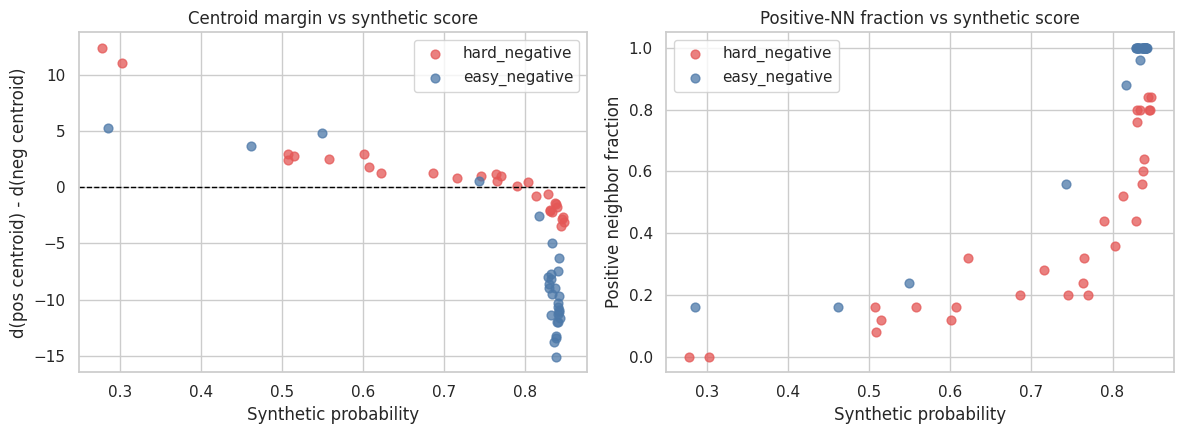

In [55]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

for group_name, color in [("hard_negative", "#E45756"), ("easy_negative", "#4C78A8")]:
    subset = multimodal_hard_negative_geometry_df[
        multimodal_hard_negative_geometry_df["group"] == group_name
    ]
    axes[0].scatter(
        subset["synthetic_prob"],
        subset["centroid_margin_pos_minus_neg"],
        alpha=0.75,
        s=40,
        color=color,
        label=group_name,
    )
    axes[1].scatter(
        subset["synthetic_prob"],
        subset["positive_neighbor_fraction"],
        alpha=0.75,
        s=40,
        color=color,
        label=group_name,
    )

axes[0].axhline(0.0, color="black", linestyle="--", linewidth=1)
axes[0].set_title("Centroid margin vs synthetic score")
axes[0].set_xlabel("Synthetic probability")
axes[0].set_ylabel("d(pos centroid) - d(neg centroid)")

axes[1].set_title("Positive-NN fraction vs synthetic score")
axes[1].set_xlabel("Synthetic probability")
axes[1].set_ylabel("Positive neighbor fraction")

axes[0].legend()
axes[1].legend()
plt.tight_layout()
plt.show()

In [58]:
# Cell title: Score-compression audit
# Work done: fix the categorical groupby failure and print shareable numeric summaries for the score-compression hypothesis.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

from sklearn.neighbors import NearestNeighbors


def _to_numpy_2d(value):
    if torch.is_tensor(value):
        value = value.detach().cpu().numpy()
    arr = np.asarray(value, dtype=np.float32)
    if arr.ndim != 2:
        raise ValueError(f"Expected a 2D array, got shape={arr.shape}")
    return arr


def _to_numpy_1d(value):
    if torch.is_tensor(value):
        value = value.detach().cpu().numpy()
    arr = np.asarray(value)
    if arr.ndim == 0:
        arr = arr.reshape(1)
    return arr.reshape(-1)


required_names = [
    "multimodal_train_latents",
    "multimodal_train_labels",
    "multimodal_test_latents",
    "multimodal_test_labels",
    "synthetic_probs",
    "multimodal_real_test_probs",
]

for name in required_names:
    if name not in globals():
        raise NameError(f"Missing required variable: {name}")

train_latents = _to_numpy_2d(multimodal_train_latents)
train_labels = _to_numpy_1d(multimodal_train_labels).astype(np.int64)
test_latents = _to_numpy_2d(multimodal_test_latents)
test_labels = _to_numpy_1d(multimodal_test_labels).astype(np.int64)
syn_probs = _to_numpy_1d(synthetic_probs).astype(np.float32)
real_probs = _to_numpy_1d(multimodal_real_test_probs).astype(np.float32)

if not (len(test_latents) == len(test_labels) == len(syn_probs) == len(real_probs)):
    raise ValueError(
        f"Length mismatch: "
        f"test_latents={len(test_latents)}, "
        f"test_labels={len(test_labels)}, "
        f"synthetic_probs={len(syn_probs)}, "
        f"real_probs={len(real_probs)}"
    )

train_mean = train_latents.mean(axis=0, keepdims=True)
train_std = train_latents.std(axis=0, keepdims=True)
train_std = np.where(train_std < 1e-6, 1.0, train_std)

train_z = (train_latents - train_mean) / train_std
test_z = (test_latents - train_mean) / train_std

k_neighbors = min(25, max(5, len(train_z) // 100))
knn = NearestNeighbors(n_neighbors=k_neighbors, metric="euclidean")
knn.fit(train_z)

neighbor_distances, neighbor_indices = knn.kneighbors(test_z)
neighbor_labels = train_labels[neighbor_indices]
positive_neighbor_fraction = np.mean(neighbor_labels == 1, axis=1).astype(np.float32)

score_df = pd.DataFrame(
    {
        "index": np.arange(len(test_labels)),
        "true_label": test_labels,
        "positive_neighbor_fraction": positive_neighbor_fraction,
        "synthetic_prob": syn_probs,
        "real_prob": real_probs,
    }
)

score_df["real_minus_synthetic"] = score_df["real_prob"] - score_df["synthetic_prob"]

evidence_edges = np.array([0.0, 0.2, 0.4, 0.6, 0.8, 1.000001], dtype=np.float32)
evidence_labels = ["0.0-0.2", "0.2-0.4", "0.4-0.6", "0.6-0.8", "0.8-1.0"]

score_df["evidence_bin"] = pd.cut(
    score_df["positive_neighbor_fraction"],
    bins=evidence_edges,
    labels=evidence_labels,
    include_lowest=True,
    right=True,
)

# Avoid the pandas categorical groupby/as_index=False insertion bug by grouping first,
# then resetting the index explicitly.
binned_response_df = (
    score_df
    .groupby(["true_label", "evidence_bin"], observed=True)
    .agg(
        count=("index", "size"),
        pos_nn_frac_mean=("positive_neighbor_fraction", "mean"),
        synthetic_mean=("synthetic_prob", "mean"),
        synthetic_std=("synthetic_prob", "std"),
        real_mean=("real_prob", "mean"),
        real_std=("real_prob", "std"),
        real_minus_synthetic_mean=("real_minus_synthetic", "mean"),
    )
    .reset_index()
)

dynamic_rows = []
for cls in [0, 1]:
    subset = score_df[score_df["true_label"] == cls].copy()

    syn_p10, syn_p50, syn_p90 = np.quantile(subset["synthetic_prob"], [0.10, 0.50, 0.90])
    real_p10, real_p50, real_p90 = np.quantile(subset["real_prob"], [0.10, 0.50, 0.90])

    corr_syn = float(np.corrcoef(subset["positive_neighbor_fraction"], subset["synthetic_prob"])[0, 1])
    corr_real = float(np.corrcoef(subset["positive_neighbor_fraction"], subset["real_prob"])[0, 1])

    cls_bins = binned_response_df[binned_response_df["true_label"] == cls].copy()
    cls_bins = cls_bins[cls_bins["count"] > 0]

    syn_span = float(cls_bins["synthetic_mean"].max() - cls_bins["synthetic_mean"].min())
    real_span = float(cls_bins["real_mean"].max() - cls_bins["real_mean"].min())

    dynamic_rows.append(
        {
            "true_label": int(cls),
            "count": int(len(subset)),
            "synthetic_p10": float(syn_p10),
            "synthetic_p50": float(syn_p50),
            "synthetic_p90": float(syn_p90),
            "synthetic_p90_minus_p10": float(syn_p90 - syn_p10),
            "real_p10": float(real_p10),
            "real_p50": float(real_p50),
            "real_p90": float(real_p90),
            "real_p90_minus_p10": float(real_p90 - real_p10),
            "corr_pos_nn_vs_synthetic": corr_syn,
            "corr_pos_nn_vs_real": corr_real,
            "synthetic_span_across_bins": syn_span,
            "real_span_across_bins": real_span,
        }
    )

score_dynamic_summary_df = pd.DataFrame(dynamic_rows)

ambiguous_df = score_df[
    (score_df["positive_neighbor_fraction"] >= 0.2)
    & (score_df["positive_neighbor_fraction"] <= 0.8)
].copy()

ambiguous_summary_df = (
    ambiguous_df
    .groupby("true_label")
    .agg(
        count=("index", "size"),
        pos_nn_frac_mean=("positive_neighbor_fraction", "mean"),
        synthetic_mean=("synthetic_prob", "mean"),
        synthetic_std=("synthetic_prob", "std"),
        real_mean=("real_prob", "mean"),
        real_std=("real_prob", "std"),
        real_minus_synthetic_mean=("real_minus_synthetic", "mean"),
    )
    .reset_index()
)

midband_df = score_df[
    (score_df["positive_neighbor_fraction"] >= 0.4)
    & (score_df["positive_neighbor_fraction"] <= 0.6)
].copy()

midband_summary_df = (
    midband_df
    .groupby("true_label")
    .agg(
        count=("index", "size"),
        pos_nn_frac_mean=("positive_neighbor_fraction", "mean"),
        synthetic_mean=("synthetic_prob", "mean"),
        synthetic_std=("synthetic_prob", "std"),
        real_mean=("real_prob", "mean"),
        real_std=("real_prob", "std"),
        real_minus_synthetic_mean=("real_minus_synthetic", "mean"),
    )
    .reset_index()
)

if len(ambiguous_summary_df) == 2:
    ambiguous_syn_sep = float(
        ambiguous_summary_df.loc[ambiguous_summary_df["true_label"] == 1, "synthetic_mean"].iloc[0]
        - ambiguous_summary_df.loc[ambiguous_summary_df["true_label"] == 0, "synthetic_mean"].iloc[0]
    )
    ambiguous_real_sep = float(
        ambiguous_summary_df.loc[ambiguous_summary_df["true_label"] == 1, "real_mean"].iloc[0]
        - ambiguous_summary_df.loc[ambiguous_summary_df["true_label"] == 0, "real_mean"].iloc[0]
    )
else:
    ambiguous_syn_sep = np.nan
    ambiguous_real_sep = np.nan

compression_report = {
    "k_neighbors": int(k_neighbors),
    "ambiguous_band_synthetic_separation": ambiguous_syn_sep,
    "ambiguous_band_real_separation": ambiguous_real_sep,
    "separation_advantage_real_minus_synthetic": float(ambiguous_real_sep - ambiguous_syn_sep)
    if np.isfinite(ambiguous_syn_sep) and np.isfinite(ambiguous_real_sep)
    else np.nan,
}

print("Score-compression audit")
print(f"k-nearest neighbors used         : {k_neighbors}")
print(
    f"Ambiguous-band separation (syn)  : "
    f"{ambiguous_syn_sep:+.4f}" if np.isfinite(ambiguous_syn_sep) else
    "Ambiguous-band separation (syn)  : nan"
)
print(
    f"Ambiguous-band separation (real) : "
    f"{ambiguous_real_sep:+.4f}" if np.isfinite(ambiguous_real_sep) else
    "Ambiguous-band separation (real) : nan"
)
print(
    f"Real advantage in ambiguous band : "
    f"{compression_report['separation_advantage_real_minus_synthetic']:+.4f}"
    if np.isfinite(compression_report["separation_advantage_real_minus_synthetic"])
    else "Real advantage in ambiguous band : nan"
)

print("\nScore dynamic summary")
print(
    score_dynamic_summary_df.to_string(
        index=False,
        float_format=lambda x: f"{x:.4f}",
    )
)

print("\nBinned score response")
print(
    binned_response_df.to_string(
        index=False,
        float_format=lambda x: f"{x:.4f}",
    )
)

print("\nAmbiguous-band summary (pos-NN fraction in [0.2, 0.8])")
print(
    ambiguous_summary_df.to_string(
        index=False,
        float_format=lambda x: f"{x:.4f}",
    )
)

print("\nMid-band summary (pos-NN fraction in [0.4, 0.6])")
print(
    midband_summary_df.to_string(
        index=False,
        float_format=lambda x: f"{x:.4f}",
    )
)

Score-compression audit
k-nearest neighbors used         : 25
Ambiguous-band separation (syn)  : nan
Ambiguous-band separation (real) : nan
Real advantage in ambiguous band : nan

Score dynamic summary
 true_label  count  synthetic_p10  synthetic_p50  synthetic_p90  synthetic_p90_minus_p10  real_p10  real_p50  real_p90  real_p90_minus_p10  corr_pos_nn_vs_synthetic  corr_pos_nn_vs_real  synthetic_span_across_bins  real_span_across_bins
          0    234         0.2409         0.2549         0.8459                   0.6050    0.0013    0.0858    0.9993              0.9980                    0.9449               0.9479                      0.5642                 0.8992
          1    390         0.8349         0.8368         0.8392                   0.0043    0.9994    0.9994    0.9994              0.0000                    0.9721               0.9897                      0.5265                 0.5645

Binned score response
 true_label evidence_bin  count  pos_nn_frac_mean  synthetic_mea

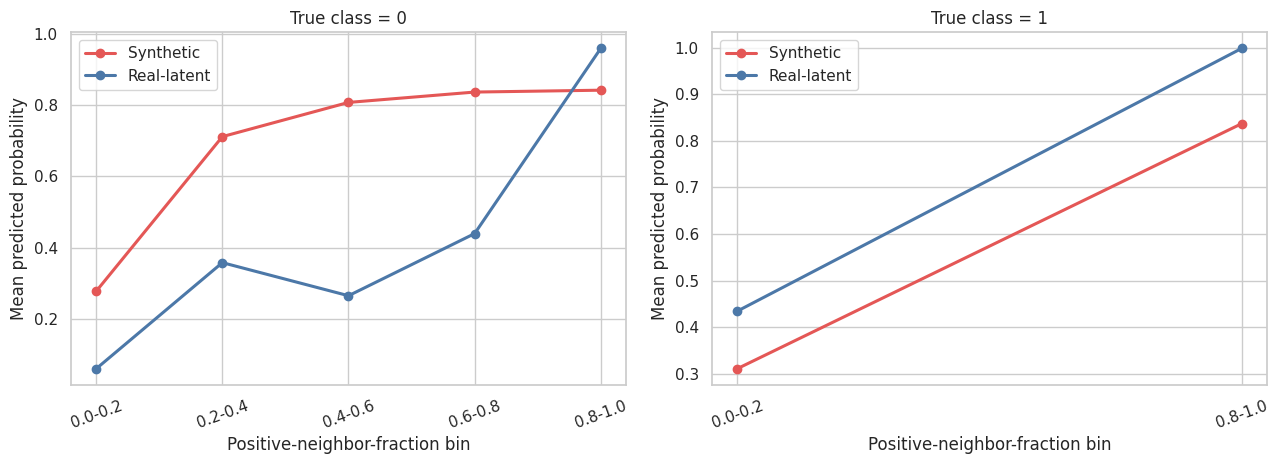

In [59]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8), sharey=False)

for cls, ax in zip([0, 1], axes):
    cls_bins = binned_response_df[
        (binned_response_df["true_label"] == cls) & (binned_response_df["count"] > 0)
    ].copy()

    x = np.arange(len(cls_bins))
    ax.plot(x, cls_bins["synthetic_mean"], marker="o", linewidth=2.2, color="#E45756", label="Synthetic")
    ax.plot(x, cls_bins["real_mean"], marker="o", linewidth=2.2, color="#4C78A8", label="Real-latent")

    ax.set_xticks(x)
    ax.set_xticklabels(cls_bins["evidence_bin"].astype(str), rotation=20)
    ax.set_xlabel("Positive-neighbor-fraction bin")
    ax.set_ylabel("Mean predicted probability")
    ax.set_title(f"True class = {cls}")
    ax.legend()

plt.tight_layout()
plt.show()

In [60]:
# Cell title: Tail-collapse audit
# Work done: quantify negative-floor inflation and positive-ceiling collapse with shareable tables plus two plots.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch


def _to_numpy_1d(value):
    if torch.is_tensor(value):
        value = value.detach().cpu().numpy()
    arr = np.asarray(value)
    if arr.ndim == 0:
        arr = arr.reshape(1)
    return arr.reshape(-1)


if "score_df" not in globals():
    required_names = [
        "multimodal_test_labels",
        "synthetic_probs",
        "multimodal_real_test_probs",
        "positive_neighbor_fraction",
    ]
    for name in required_names:
        if name not in globals():
            raise NameError(f"Missing required variable: {name}")

    score_df = pd.DataFrame(
        {
            "index": np.arange(len(_to_numpy_1d(multimodal_test_labels))),
            "true_label": _to_numpy_1d(multimodal_test_labels).astype(np.int64),
            "positive_neighbor_fraction": _to_numpy_1d(positive_neighbor_fraction).astype(np.float32),
            "synthetic_prob": _to_numpy_1d(synthetic_probs).astype(np.float32),
            "real_prob": _to_numpy_1d(multimodal_real_test_probs).astype(np.float32),
        }
    )
    score_df["real_minus_synthetic"] = score_df["real_prob"] - score_df["synthetic_prob"]

audit_df = score_df.copy()
audit_df["synthetic_minus_real"] = audit_df["synthetic_prob"] - audit_df["real_prob"]

negative_confident = audit_df[
    (audit_df["true_label"] == 0) & (audit_df["positive_neighbor_fraction"] <= 0.2)
].copy()

negative_ambiguous = audit_df[
    (audit_df["true_label"] == 0)
    & (audit_df["positive_neighbor_fraction"] >= 0.2)
    & (audit_df["positive_neighbor_fraction"] <= 0.8)
].copy()

negative_positive_region = audit_df[
    (audit_df["true_label"] == 0) & (audit_df["positive_neighbor_fraction"] >= 0.8)
].copy()

positive_confident = audit_df[
    (audit_df["true_label"] == 1) & (audit_df["positive_neighbor_fraction"] >= 0.8)
].copy()

positive_low_evidence = audit_df[
    (audit_df["true_label"] == 1) & (audit_df["positive_neighbor_fraction"] < 0.8)
].copy()


def _summary_row(name, frame):
    if len(frame) == 0:
        return {
            "subset": name,
            "count": 0,
            "pos_nn_frac_mean": np.nan,
            "synthetic_mean": np.nan,
            "synthetic_std": np.nan,
            "synthetic_p90_minus_p10": np.nan,
            "synthetic_iqr": np.nan,
            "real_mean": np.nan,
            "real_std": np.nan,
            "real_p90_minus_p10": np.nan,
            "real_iqr": np.nan,
            "synthetic_minus_real_mean": np.nan,
        }

    syn = frame["synthetic_prob"].to_numpy()
    real = frame["real_prob"].to_numpy()
    pos_nn = frame["positive_neighbor_fraction"].to_numpy()

    syn_q10, syn_q25, syn_q75, syn_q90 = np.quantile(syn, [0.10, 0.25, 0.75, 0.90])
    real_q10, real_q25, real_q75, real_q90 = np.quantile(real, [0.10, 0.25, 0.75, 0.90])

    return {
        "subset": name,
        "count": int(len(frame)),
        "pos_nn_frac_mean": float(np.mean(pos_nn)),
        "synthetic_mean": float(np.mean(syn)),
        "synthetic_std": float(np.std(syn, ddof=1)) if len(syn) > 1 else np.nan,
        "synthetic_p90_minus_p10": float(syn_q90 - syn_q10),
        "synthetic_iqr": float(syn_q75 - syn_q25),
        "real_mean": float(np.mean(real)),
        "real_std": float(np.std(real, ddof=1)) if len(real) > 1 else np.nan,
        "real_p90_minus_p10": float(real_q90 - real_q10),
        "real_iqr": float(real_q75 - real_q25),
        "synthetic_minus_real_mean": float(np.mean(syn - real)),
    }


tail_collapse_summary_df = pd.DataFrame(
    [
        _summary_row("all_negatives", audit_df[audit_df["true_label"] == 0]),
        _summary_row("confident_negatives_nn<=0.2", negative_confident),
        _summary_row("ambiguous_negatives_0.2<=nn<=0.8", negative_ambiguous),
        _summary_row("positive-region_negatives_nn>=0.8", negative_positive_region),
        _summary_row("all_positives", audit_df[audit_df["true_label"] == 1]),
        _summary_row("confident_positives_nn>=0.8", positive_confident),
        _summary_row("low-evidence_positives_nn<0.8", positive_low_evidence),
    ]
)

negative_inflation_cases = (
    audit_df[audit_df["true_label"] == 0]
    .sort_values(
        ["synthetic_minus_real", "synthetic_prob", "positive_neighbor_fraction"],
        ascending=[False, False, False],
    )
    .loc[:, [
        "index",
        "positive_neighbor_fraction",
        "synthetic_prob",
        "real_prob",
        "synthetic_minus_real",
    ]]
    .head(12)
    .reset_index(drop=True)
)

positive_ceiling_cases = (
    audit_df[audit_df["true_label"] == 1]
    .sort_values(
        ["real_minus_synthetic", "real_prob", "synthetic_prob"],
        ascending=[False, False, True],
    )
    .loc[:, [
        "index",
        "positive_neighbor_fraction",
        "synthetic_prob",
        "real_prob",
        "real_minus_synthetic",
    ]]
    .head(12)
    .reset_index(drop=True)
)

positive_unique_levels = (
    audit_df[audit_df["true_label"] == 1]["synthetic_prob"]
    .round(4)
    .value_counts()
    .sort_index()
    .reset_index()
)
positive_unique_levels.columns = ["synthetic_prob_rounded", "count"]

report = {
    "negative_ambiguous_count": int(len(negative_ambiguous)),
    "positive_low_evidence_count": int(len(positive_low_evidence)),
    "positive_confident_count": int(len(positive_confident)),
    "negative_ambiguous_syn_minus_real_mean": float(
        negative_ambiguous["synthetic_minus_real"].mean()
    ) if len(negative_ambiguous) > 0 else np.nan,
    "positive_confident_real_minus_syn_mean": float(
        positive_confident["real_minus_synthetic"].mean()
    ) if len(positive_confident) > 0 else np.nan,
}

print("Tail-collapse audit")
print(f"Ambiguous negatives count              : {report['negative_ambiguous_count']}")
print(f"Low-evidence positives count           : {report['positive_low_evidence_count']}")
print(f"Confident positives count              : {report['positive_confident_count']}")
print(
    f"Ambiguous negatives syn-real mean gap  : {report['negative_ambiguous_syn_minus_real_mean']:+.4f}"
    if np.isfinite(report["negative_ambiguous_syn_minus_real_mean"])
    else "Ambiguous negatives syn-real mean gap  : nan"
)
print(
    f"Confident positives real-syn mean gap  : {report['positive_confident_real_minus_syn_mean']:+.4f}"
    if np.isfinite(report["positive_confident_real_minus_syn_mean"])
    else "Confident positives real-syn mean gap  : nan"
)

print("\nTail-collapse summary")
print(
    tail_collapse_summary_df.to_string(
        index=False,
        float_format=lambda x: f"{x:.4f}",
    )
)

print("\nTop negative inflation cases (synthetic too high on true negatives)")
print(
    negative_inflation_cases.to_string(
        index=False,
        float_format=lambda x: f"{x:.4f}",
    )
)

print("\nTop positive ceiling-collapse cases (real much higher than synthetic on true positives)")
print(
    positive_ceiling_cases.to_string(
        index=False,
        float_format=lambda x: f"{x:.4f}",
    )
)

print("\nRounded synthetic score levels for true positives")
print(
    positive_unique_levels.head(20).to_string(
        index=False,
        float_format=lambda x: f"{x:.4f}",
    )
)

Tail-collapse audit
Ambiguous negatives count              : 23
Low-evidence positives count           : 1
Confident positives count              : 389
Ambiguous negatives syn-real mean gap  : +0.4522
Confident positives real-syn mean gap  : +0.1616

Tail-collapse summary
                           subset  count  pos_nn_frac_mean  synthetic_mean  synthetic_std  synthetic_p90_minus_p10  synthetic_iqr  real_mean  real_std  real_p90_minus_p10  real_iqr  synthetic_minus_real_mean
                    all_negatives    234            0.3022          0.4563         0.2698                   0.6050         0.5844     0.3012    0.4020              0.9980    0.5808                     0.1552
      confident_negatives_nn<=0.2    158            0.0337          0.2780         0.0917                   0.0766         0.0110     0.0605    0.1082              0.2021    0.0955                     0.2175
 ambiguous_negatives_0.2<=nn<=0.8     23            0.4870          0.7778         0.0763              

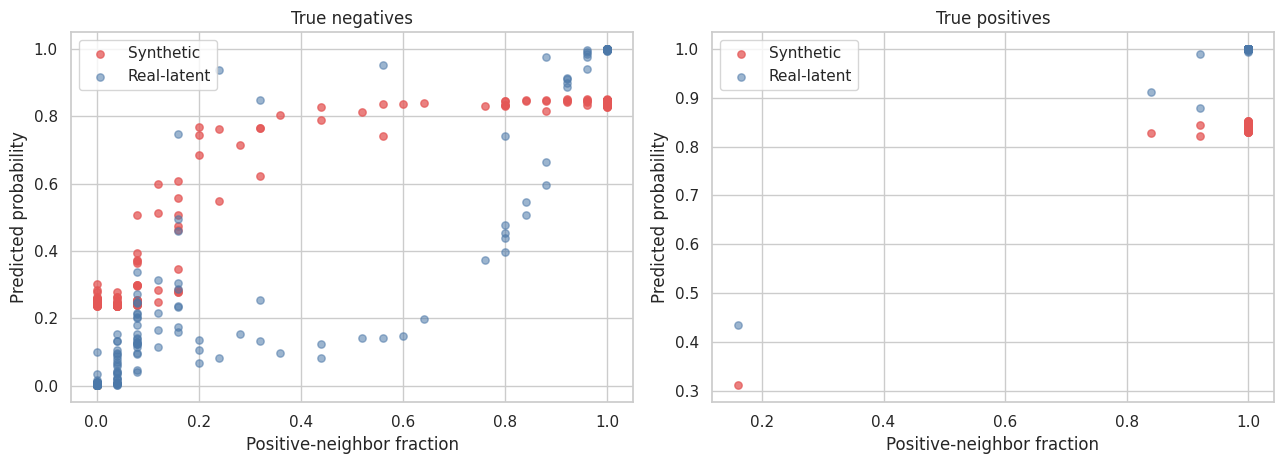

In [61]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))

neg = audit_df[audit_df["true_label"] == 0].sort_values("positive_neighbor_fraction")
pos = audit_df[audit_df["true_label"] == 1].sort_values("positive_neighbor_fraction")

axes[0].scatter(
    neg["positive_neighbor_fraction"],
    neg["synthetic_prob"],
    s=28,
    alpha=0.75,
    color="#E45756",
    label="Synthetic",
)
axes[0].scatter(
    neg["positive_neighbor_fraction"],
    neg["real_prob"],
    s=28,
    alpha=0.55,
    color="#4C78A8",
    label="Real-latent",
)
axes[0].set_title("True negatives")
axes[0].set_xlabel("Positive-neighbor fraction")
axes[0].set_ylabel("Predicted probability")
axes[0].legend()

axes[1].scatter(
    pos["positive_neighbor_fraction"],
    pos["synthetic_prob"],
    s=28,
    alpha=0.75,
    color="#E45756",
    label="Synthetic",
)
axes[1].scatter(
    pos["positive_neighbor_fraction"],
    pos["real_prob"],
    s=28,
    alpha=0.55,
    color="#4C78A8",
    label="Real-latent",
)
axes[1].set_title("True positives")
axes[1].set_xlabel("Positive-neighbor fraction")
axes[1].set_ylabel("Predicted probability")
axes[1].legend()

plt.tight_layout()
plt.show()

In [62]:
# Cell title: Logit-scale collapse audit
# Work done: test whether the synthetic branch is compressed in raw decision margin space, not just probability space.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch


def _to_numpy_1d(value):
    if torch.is_tensor(value):
        value = value.detach().cpu().numpy()
    arr = np.asarray(value)
    if arr.ndim == 0:
        arr = arr.reshape(1)
    return arr.reshape(-1)


if "score_df" not in globals():
    required_names = [
        "multimodal_test_labels",
        "synthetic_probs",
        "multimodal_real_test_probs",
        "positive_neighbor_fraction",
    ]
    for name in required_names:
        if name not in globals():
            raise NameError(f"Missing required variable: {name}")

    score_df = pd.DataFrame(
        {
            "index": np.arange(len(_to_numpy_1d(multimodal_test_labels))),
            "true_label": _to_numpy_1d(multimodal_test_labels).astype(np.int64),
            "positive_neighbor_fraction": _to_numpy_1d(positive_neighbor_fraction).astype(np.float32),
            "synthetic_prob": _to_numpy_1d(synthetic_probs).astype(np.float32),
            "real_prob": _to_numpy_1d(multimodal_real_test_probs).astype(np.float32),
        }
    )

audit_df = score_df.copy()

eps = 1e-6
audit_df["synthetic_prob_clipped"] = np.clip(audit_df["synthetic_prob"], eps, 1.0 - eps)
audit_df["real_prob_clipped"] = np.clip(audit_df["real_prob"], eps, 1.0 - eps)

audit_df["synthetic_logit"] = np.log(
    audit_df["synthetic_prob_clipped"] / (1.0 - audit_df["synthetic_prob_clipped"])
)
audit_df["real_logit"] = np.log(
    audit_df["real_prob_clipped"] / (1.0 - audit_df["real_prob_clipped"])
)

audit_df["real_minus_synthetic_logit"] = audit_df["real_logit"] - audit_df["synthetic_logit"]
audit_df["synthetic_minus_real_logit"] = audit_df["synthetic_logit"] - audit_df["real_logit"]

evidence_edges = np.array([0.0, 0.2, 0.4, 0.6, 0.8, 1.000001], dtype=np.float32)
evidence_labels = ["0.0-0.2", "0.2-0.4", "0.4-0.6", "0.6-0.8", "0.8-1.0"]

audit_df["evidence_bin"] = pd.cut(
    audit_df["positive_neighbor_fraction"],
    bins=evidence_edges,
    labels=evidence_labels,
    include_lowest=True,
    right=True,
)

def _spread_summary(name, frame):
    if len(frame) == 0:
        return {
            "subset": name,
            "count": 0,
            "pos_nn_frac_mean": np.nan,
            "synthetic_logit_mean": np.nan,
            "synthetic_logit_std": np.nan,
            "synthetic_logit_p90_minus_p10": np.nan,
            "real_logit_mean": np.nan,
            "real_logit_std": np.nan,
            "real_logit_p90_minus_p10": np.nan,
            "real_minus_synthetic_logit_mean": np.nan,
        }

    syn_logit = frame["synthetic_logit"].to_numpy()
    real_logit = frame["real_logit"].to_numpy()

    syn_q10, syn_q90 = np.quantile(syn_logit, [0.10, 0.90])
    real_q10, real_q90 = np.quantile(real_logit, [0.10, 0.90])

    return {
        "subset": name,
        "count": int(len(frame)),
        "pos_nn_frac_mean": float(frame["positive_neighbor_fraction"].mean()),
        "synthetic_logit_mean": float(syn_logit.mean()),
        "synthetic_logit_std": float(np.std(syn_logit, ddof=1)) if len(frame) > 1 else np.nan,
        "synthetic_logit_p90_minus_p10": float(syn_q90 - syn_q10),
        "real_logit_mean": float(real_logit.mean()),
        "real_logit_std": float(np.std(real_logit, ddof=1)) if len(frame) > 1 else np.nan,
        "real_logit_p90_minus_p10": float(real_q90 - real_q10),
        "real_minus_synthetic_logit_mean": float((real_logit - syn_logit).mean()),
    }

logit_spread_summary_df = pd.DataFrame(
    [
        _spread_summary("all_negatives", audit_df[audit_df["true_label"] == 0]),
        _spread_summary(
            "confident_negatives_nn<=0.2",
            audit_df[(audit_df["true_label"] == 0) & (audit_df["positive_neighbor_fraction"] <= 0.2)],
        ),
        _spread_summary(
            "ambiguous_negatives_0.2<=nn<=0.8",
            audit_df[
                (audit_df["true_label"] == 0)
                & (audit_df["positive_neighbor_fraction"] >= 0.2)
                & (audit_df["positive_neighbor_fraction"] <= 0.8)
            ],
        ),
        _spread_summary(
            "positive_region_negatives_nn>=0.8",
            audit_df[(audit_df["true_label"] == 0) & (audit_df["positive_neighbor_fraction"] >= 0.8)],
        ),
        _spread_summary("all_positives", audit_df[audit_df["true_label"] == 1]),
        _spread_summary(
            "confident_positives_nn>=0.8",
            audit_df[(audit_df["true_label"] == 1) & (audit_df["positive_neighbor_fraction"] >= 0.8)],
        ),
    ]
)

logit_bin_response_df = (
    audit_df
    .groupby(["true_label", "evidence_bin"], observed=True)
    .agg(
        count=("index", "size"),
        pos_nn_frac_mean=("positive_neighbor_fraction", "mean"),
        synthetic_logit_mean=("synthetic_logit", "mean"),
        synthetic_logit_std=("synthetic_logit", "std"),
        real_logit_mean=("real_logit", "mean"),
        real_logit_std=("real_logit", "std"),
        real_minus_synthetic_logit_mean=("real_minus_synthetic_logit", "mean"),
    )
    .reset_index()
)

negative_logit_inflation_cases = (
    audit_df[audit_df["true_label"] == 0]
    .sort_values(
        ["synthetic_minus_real_logit", "synthetic_logit", "positive_neighbor_fraction"],
        ascending=[False, False, False],
    )
    .loc[:, [
        "index",
        "positive_neighbor_fraction",
        "synthetic_prob",
        "real_prob",
        "synthetic_logit",
        "real_logit",
        "synthetic_minus_real_logit",
    ]]
    .head(12)
    .reset_index(drop=True)
)

positive_logit_ceiling_cases = (
    audit_df[audit_df["true_label"] == 1]
    .sort_values(
        ["real_minus_synthetic_logit", "real_logit", "synthetic_logit"],
        ascending=[False, False, True],
    )
    .loc[:, [
        "index",
        "positive_neighbor_fraction",
        "synthetic_prob",
        "real_prob",
        "synthetic_logit",
        "real_logit",
        "real_minus_synthetic_logit",
    ]]
    .head(12)
    .reset_index(drop=True)
)

report = {
    "negative_ambiguous_logit_gap": float(
        audit_df[
            (audit_df["true_label"] == 0)
            & (audit_df["positive_neighbor_fraction"] >= 0.2)
            & (audit_df["positive_neighbor_fraction"] <= 0.8)
        ]["synthetic_minus_real_logit"].mean()
    ),
    "positive_confident_logit_gap": float(
        audit_df[
            (audit_df["true_label"] == 1)
            & (audit_df["positive_neighbor_fraction"] >= 0.8)
        ]["real_minus_synthetic_logit"].mean()
    ),
}

print("Logit-scale collapse audit")
print(f"Ambiguous negatives syn-real logit gap : {report['negative_ambiguous_logit_gap']:+.4f}")
print(f"Confident positives real-syn logit gap : {report['positive_confident_logit_gap']:+.4f}")

print("\nLogit spread summary")
print(
    logit_spread_summary_df.to_string(
        index=False,
        float_format=lambda x: f"{x:.4f}",
    )
)

print("\nEvidence-conditioned logit response")
print(
    logit_bin_response_df.to_string(
        index=False,
        float_format=lambda x: f"{x:.4f}",
    )
)

print("\nTop negative inflation cases in logit space")
print(
    negative_logit_inflation_cases.to_string(
        index=False,
        float_format=lambda x: f"{x:.4f}",
    )
)

print("\nTop positive ceiling-collapse cases in logit space")
print(
    positive_logit_ceiling_cases.to_string(
        index=False,
        float_format=lambda x: f"{x:.4f}",
    )
)

Logit-scale collapse audit
Ambiguous negatives syn-real logit gap : +2.1626
Confident positives real-syn logit gap : +5.7734

Logit spread summary
                           subset  count  pos_nn_frac_mean  synthetic_logit_mean  synthetic_logit_std  synthetic_logit_p90_minus_p10  real_logit_mean  real_logit_std  real_logit_p90_minus_p10  real_minus_synthetic_logit_mean
                    all_negatives    234            0.3022               -0.1433               1.2554                         2.8508          -1.7501          4.8920                   13.8529                          -1.6068
      confident_negatives_nn<=0.2    158            0.0337               -0.9751               0.4036                         0.3824          -4.5773          2.1794                    5.3106                          -3.6023
 ambiguous_negatives_0.2<=nn<=0.8     23            0.4870                1.2941               0.4034                         0.8400          -0.8685          1.6187             

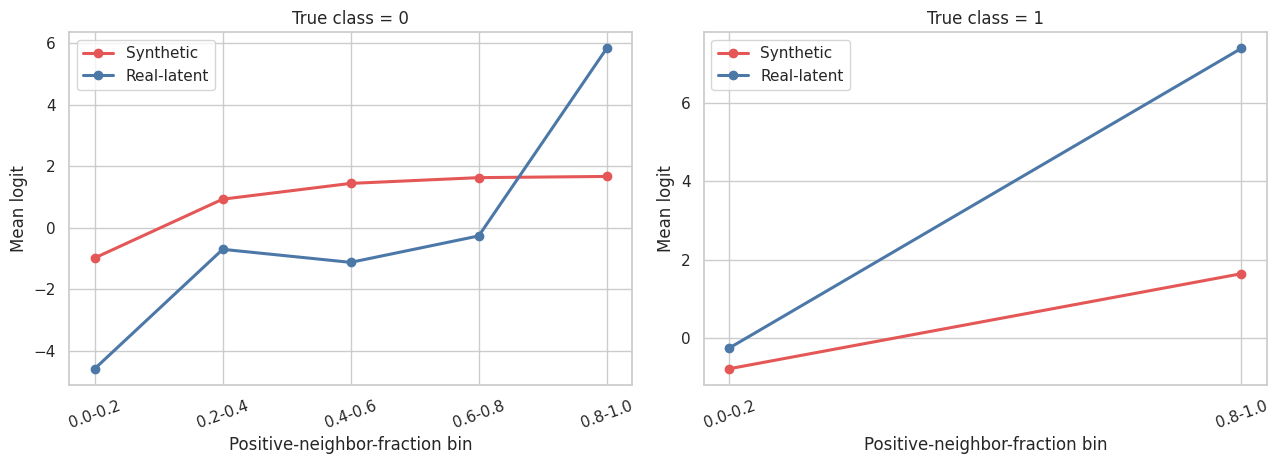

In [63]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))

for cls, ax in zip([0, 1], axes):
    subset = logit_bin_response_df[
        (logit_bin_response_df["true_label"] == cls) & (logit_bin_response_df["count"] > 0)
    ].copy()

    x = np.arange(len(subset))
    ax.plot(x, subset["synthetic_logit_mean"], marker="o", linewidth=2.2, color="#E45756", label="Synthetic")
    ax.plot(x, subset["real_logit_mean"], marker="o", linewidth=2.2, color="#4C78A8", label="Real-latent")

    ax.set_xticks(x)
    ax.set_xticklabels(subset["evidence_bin"].astype(str), rotation=20)
    ax.set_xlabel("Positive-neighbor-fraction bin")
    ax.set_ylabel("Mean logit")
    ax.set_title(f"True class = {cls}")
    ax.legend()

plt.tight_layout()
plt.show()